# Read Excel File

In [1]:
# ============================================================
# CELL 1 — SETUP, PATHS, IMPORTS, AND PUBLICATION STYLE
# ============================================================

from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Arc
from matplotlib.lines import Line2D
from IPython.display import display


# ============================================================
# 1. WORKING DIRECTORY
# ============================================================

WORK_DIR = Path(
    r"C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code"
)

if not WORK_DIR.exists():
    raise FileNotFoundError(
        f"Working directory does not exist:\n{WORK_DIR}"
    )

os.chdir(WORK_DIR)


# For a fully portable GitHub version, users can replace the
# line above with:
#
# WORK_DIR = Path.cwd()


# ============================================================
# 2. INPUT FILE
# ============================================================

DATA_FILE = WORK_DIR / "Supplementary_Table_S1_Haga_Local_Coordinates.xlsx"
SHEET_NAME = "Borehole_coordinates"

if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Input file not found:\n{DATA_FILE}"
    )


# ============================================================
# 3. OUTPUT LOCATIONS
#
# Figures and numerical outputs are saved directly in the
# same folder as the Python notebook.
# ============================================================

figure_dir = WORK_DIR
out_dir = WORK_DIR


# ============================================================
# 4. A4 FIGURE SIZES
# ============================================================

A4_PORTRAIT = (8.27, 11.69)
A4_LANDSCAPE = (11.69, 8.27)


# ============================================================
# 5. PUBLICATION STYLE
#
# Arial 10 pt is retained throughout.
# No smaller tick or legend fonts are used.
# ============================================================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],
    "font.size": 10,

    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "axes.linewidth": 0.8,

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "legend.fontsize": 10,

    "lines.linewidth": 1.0,

    "figure.dpi": 150,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",

    # Keep text editable in SVG
    "svg.fonttype": "none"
})


print("Working directory:")
print(WORK_DIR)

print("\nInput file:")
print(DATA_FILE)

Working directory:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code

Input file:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Supplementary_Table_S1_Haga_Local_Coordinates.xlsx


# Read and check borehole-coordinate data

In [2]:
# ============================================================
# CELL 2 — READ AND CHECK BOREHOLE COORDINATES
# ============================================================

df = pd.read_excel(
    DATA_FILE,
    sheet_name=SHEET_NAME
)

df.columns = [
    str(col).strip()
    for col in df.columns
]


# ============================================================
# Required columns
# ============================================================

required_cols = [
    "Hole",
    "X_start",
    "Y_start",
    "Z_start",
    "X_end",
    "Y_end",
    "Z_end"
]

missing_cols = [
    col for col in required_cols
    if col not in df.columns
]

if missing_cols:
    raise ValueError(
        f"Missing required columns: {missing_cols}"
    )


# ============================================================
# Convert required columns to numeric values
# ============================================================

coordinate_cols = [
    "X_start",
    "Y_start",
    "Z_start",
    "X_end",
    "Y_end",
    "Z_end"
]

df["Hole"] = pd.to_numeric(
    df["Hole"],
    errors="coerce"
)

for col in coordinate_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )


# ============================================================
# Remove incomplete rows and sort by borehole ID
# ============================================================

df = (
    df
    .dropna(subset=["Hole"] + coordinate_cols)
    .sort_values("Hole")
    .reset_index(drop=True)
)

df["Hole"] = df["Hole"].astype(int)


# ============================================================
# Basic checks
# ============================================================

if df["Hole"].duplicated().any():
    duplicate_holes = df.loc[
        df["Hole"].duplicated(),
        "Hole"
    ].tolist()

    raise ValueError(
        f"Duplicate borehole IDs found: {duplicate_holes}"
    )


print(f"Number of boreholes = {len(df)}")
print(f"Hole range = {df['Hole'].min()}–{df['Hole'].max()}")

display(df.head())

Number of boreholes = 34
Hole range = 1–34


,Hole,X_start,Y_start,Z_start,X_end,Y_end,Z_end,Length
0,1,-5.173,-1.99,-4.223823,-18.963,18.73,-9.693824,25.48
1,2,-4.093,-1.57,-4.243824,-16.743,19.59,-10.133824,25.35
2,3,-3.023,-1.16,-4.183823,-14.453,20.47,-10.213824,25.20
3,4,-1.953,-0.75,-4.103823,-12.163,21.36,-10.233823,25.11
4,5,-0.883,-0.33,-4.013823,-9.873,22.25,-10.043824,25.04


# Tunnel basis and SG-1 joint-plane normal

In [3]:
# ============================================================
# CELL 3 — TUNNEL BASIS AND SG-1 JOINT NORMAL
# ============================================================


# ============================================================
# 1. INPUT ORIENTATIONS
# ============================================================

# Haga tunnel alignment
AZ_t_deg = 340.0       # azimuth clockwise from North
PZ_t_deg = 0.0         # plunge positive downward

# SG-1 orientation used specifically for CAD validation
SG1_strike_deg = 165.0     # RHR strike
SG1_dip_deg = 45.0


# ============================================================
# 2. HELPER FUNCTION — UNIT VECTOR
# ============================================================

def unit(vector):
    """
    Return the unit vector of an input vector.
    """
    vector = np.asarray(vector, dtype=float)

    magnitude = np.linalg.norm(vector)

    if np.isclose(magnitude, 0.0):
        raise ValueError("Zero-length vector encountered.")

    return vector / magnitude


# ============================================================
# 3. TUNNEL BASIS
# ============================================================

def tunnel_basis(azimuth_deg, plunge_deg):
    """
    Calculate the right-handed local tunnel basis.

    Coordinate convention:
        +X = East
        +Y = North
        +Z = Up

    Azimuth:
        clockwise from North

    Plunge:
        measured from horizontal,
        positive downward
    """

    AZ_t = np.radians(azimuth_deg)
    PZ_t = np.radians(plunge_deg)

    # --------------------------------------------------------
    # Eq. (11)
    #
    # t = [
    #       cos(PZ_t) sin(AZ_t),
    #       cos(PZ_t) cos(AZ_t),
    #      -sin(PZ_t)
    #     ]
    # --------------------------------------------------------

    t = np.array([
        np.cos(PZ_t) * np.sin(AZ_t),
        np.cos(PZ_t) * np.cos(AZ_t),
        -np.sin(PZ_t)
    ])

    t = unit(t)


    # --------------------------------------------------------
    # Eq. (12)
    #
    # t1 = [
    #        cos(AZ_t),
    #       -sin(AZ_t),
    #        0
    #      ]
    #
    # t1 is the horizontal transverse unit vector.
    # --------------------------------------------------------

    t1 = np.array([
        np.cos(AZ_t),
        -np.sin(AZ_t),
        0.0
    ])

    t1 = unit(t1)


    # --------------------------------------------------------
    # Eq. (13)
    #
    # t2 = t1 × t
    #
    # t2 is the second transverse unit vector.
    # --------------------------------------------------------

    t2 = np.cross(t1, t)
    t2 = unit(t2)

    return t, t1, t2


# ============================================================
# 4. RHR JOINT-PLANE NORMAL
# ============================================================

def joint_normal_rhr(strike_deg, dip_deg):
    """
    Calculate the joint-plane normal unit vector from
    RHR strike and dip.
    """

    theta = np.radians(strike_deg)
    delta = np.radians(dip_deg)

    # --------------------------------------------------------
    # Eq. (14)
    #
    # n = [
    #       sin(delta) cos(theta),
    #      -sin(delta) sin(theta),
    #       cos(delta)
    #     ]
    # --------------------------------------------------------

    n = np.array([
        np.sin(delta) * np.cos(theta),
        -np.sin(delta) * np.sin(theta),
        np.cos(delta)
    ])

    return unit(n)


# ============================================================
# 5. CALCULATE HAGA BASIS AND SG-1 NORMAL
# ============================================================

t, t1, t2 = tunnel_basis(
    AZ_t_deg,
    PZ_t_deg
)

n_sg1 = joint_normal_rhr(
    SG1_strike_deg,
    SG1_dip_deg
)


# ============================================================
# 6. CHECK ORTHONORMALITY AND HANDEDNESS
# ============================================================

assert np.isclose(np.linalg.norm(t), 1.0)
assert np.isclose(np.linalg.norm(t1), 1.0)
assert np.isclose(np.linalg.norm(t2), 1.0)

assert np.isclose(np.dot(t, t1), 0.0, atol=1e-12)
assert np.isclose(np.dot(t, t2), 0.0, atol=1e-12)
assert np.isclose(np.dot(t1, t2), 0.0, atol=1e-12)

assert np.allclose(
    np.cross(t1, t),
    t2,
    atol=1e-12
)


# ============================================================
# 7. PRINT VALUES USED IN THE MANUSCRIPT
# ============================================================

print("Tunnel basis")
print("=" * 60)

print("t  =", np.round(t, 6))
print("t1 =", np.round(t1, 6))
print("t2 =", np.round(t2, 6))

print("\nSG-1 joint-plane normal")
print("=" * 60)

print("n_SG1 =", np.round(n_sg1, 6))

Tunnel basis
t  = [-0.34202   0.939693 -0.      ]
t1 = [0.939693 0.34202  0.      ]
t2 = [-0.  0.  1.]

SG-1 joint-plane normal
n_SG1 = [-0.683013 -0.183013  0.707107]


# Borehole geometry and SG-1 hit rate

In [4]:
# ============================================================
# CELL 4 — BOREHOLE GEOMETRY AND SG-1 HIT RATE
# ============================================================

def calculate_borehole(row):
    """
    Calculate coordinate-derived borehole geometry
    and SG-1 hit rate.
    """

    # ========================================================
    # Start and end position vectors
    # ========================================================

    p_s = np.array([
        row["X_start"],
        row["Y_start"],
        row["Z_start"]
    ], dtype=float)

    p_e = np.array([
        row["X_end"],
        row["Y_end"],
        row["Z_end"]
    ], dtype=float)


    # ========================================================
    # Eq. (21)
    #
    # Δp_i = p_e,i - p_s,i
    #
    # L_i = ||Δp_i||
    #
    # l_i = Δp_i / L_i
    # ========================================================

    delta_p = p_e - p_s

    L_i = np.linalg.norm(delta_p)

    if np.isclose(L_i, 0.0):
        raise ValueError(
            f"Zero-length borehole encountered: Hole {row['Hole']}"
        )

    l_i = delta_p / L_i


    # ========================================================
    # Components in local tunnel basis
    # ========================================================

    l_dot_t = np.dot(l_i, t)
    l_dot_t1 = np.dot(l_i, t1)
    l_dot_t2 = np.dot(l_i, t2)


    # ========================================================
    # Eq. (22)
    #
    # beta_i = arccos(l_i · t)
    #
    # beta_i is the inclination relative to the tunnel axis.
    # ========================================================

    beta_i = np.arccos(
        np.clip(
            l_dot_t,
            -1.0,
            1.0
        )
    )

    beta_deg = np.degrees(beta_i)


    # ========================================================
    # Eq. (23)
    #
    # psi_i = atan2(
    #             l_i · t2,
    #             l_i · t1
    #         )
    #
    # psi_i is expressed from 0° to 360°.
    # ========================================================

    psi_i = np.arctan2(
        l_dot_t2,
        l_dot_t1
    )

    psi_deg = np.degrees(psi_i) % 360.0


    # ========================================================
    # Eq. (15) — independent reconstruction check
    #
    # l_i =
    #     t cos(beta_i)
    #     +
    #     [t1 cos(psi_i) + t2 sin(psi_i)] sin(beta_i)
    #
    # The reconstructed vector should reproduce the
    # coordinate-derived l_i.
    # ========================================================

    l_eq15 = (
        t * np.cos(beta_i)
        +
        (
            t1 * np.cos(psi_i)
            +
            t2 * np.sin(psi_i)
        )
        * np.sin(beta_i)
    )

    l_eq15 = unit(l_eq15)

    eq15_component_difference = np.max(
        np.abs(
            l_i - l_eq15
        )
    )


    # ========================================================
    # Eq. (18) for SG-1
    #
    # h_i = |l_i · n_SG1|
    #
    # Hit rate is a dimensionless geometric measure.
    # It is converted to percent only for reporting.
    # ========================================================

    h_sg1 = abs(
        np.dot(
            l_i,
            n_sg1
        )
    )

    h_sg1_pct = 100.0 * h_sg1


    # ========================================================
    # Return calculated values
    # ========================================================

    return pd.Series({

        "Delta_X_m": delta_p[0],
        "Delta_Y_m": delta_p[1],
        "Delta_Z_m": delta_p[2],

        "Length_m": L_i,

        "l_x": l_i[0],
        "l_y": l_i[1],
        "l_z": l_i[2],

        "l_dot_t": l_dot_t,
        "l_dot_t1": l_dot_t1,
        "l_dot_t2": l_dot_t2,

        "beta_deg": beta_deg,
        "psi_deg": psi_deg,

        "Eq15_l_x": l_eq15[0],
        "Eq15_l_y": l_eq15[1],
        "Eq15_l_z": l_eq15[2],

        "Eq15_max_component_diff":
            eq15_component_difference,

        "l_dot_n_SG1":
            np.dot(l_i, n_sg1),

        "SG1_hit_rate_fraction":
            h_sg1,

        "SG1_hit_rate_pct":
            h_sg1_pct
    })


# ============================================================
# Calculate all boreholes
# ============================================================

calculated = df.apply(
    calculate_borehole,
    axis=1
)

result = pd.concat(
    [
        df.reset_index(drop=True),
        calculated.reset_index(drop=True)
    ],
    axis=1
)


# Keep this alias because it is useful in later analyses
original_calc = result.copy()


# ============================================================
# Check Eq. (15) reconstruction
# ============================================================

max_eq15_difference = result[
    "Eq15_max_component_diff"
].max()

print(
    "Maximum component difference between "
    "coordinate-derived l_i and Eq. (15):"
)

print(f"{max_eq15_difference:.3e}")


# ============================================================
# Display main calculated quantities
# ============================================================

display(
    result[[
        "Hole",
        "Length_m",
        "beta_deg",
        "psi_deg",
        "l_x",
        "l_y",
        "l_z",
        "SG1_hit_rate_pct"
    ]].round(6)
)

Maximum component difference between coordinate-derived l_i and Eq. (15):
5.690e-16


,Hole,Length_m,beta_deg,psi_deg,l_x,l_y,l_z,SG1_hit_rate_pct
0,1,25.483395,18.355022,222.971529,-0.541137,0.813078,-0.214650,6.901937
1,2,25.346799,17.221373,231.710044,-0.499077,0.834819,-0.232376,2.377827
2,3,25.196482,15.880531,240.997766,-0.453635,0.858453,-0.239319,1.649371
3,4,25.113206,14.901524,251.658788,-0.406559,0.880413,-0.244095,5.604285
4,5,25.040715,14.036633,263.143909,-0.359015,0.901731,-0.240808,9.009314
5,6,25.039149,13.790066,275.597426,-0.310314,0.920558,-0.237229,12.427133
6,7,25.103755,14.152620,287.927168,-0.260917,0.936912,-0.232635,15.775446
7,8,25.238691,15.109336,299.070265,-0.211184,0.950525,-0.227825,19.081343
8,9,25.437681,16.469406,308.549869,-0.161964,0.961566,-0.221718,22.213348
9,10,25.380118,15.956036,320.050586,-0.130811,0.975567,-0.176516,21.401125


# Analytical benchmark check 

In [5]:
# ============================================================
# CELL 5 — ANALYTICAL BENCHMARK VERIFICATION
# ============================================================

# Synthetic joint plane:
#
# n = [1, 0, 0]^T
#
# Eq. (16):
#
# h = |l · n|
#
# Three known geometric cases are checked.

n_test = np.array([
    1.0,
    0.0,
    0.0
])


benchmark_cases = [

    {
        "Geometric_case":
            "Perpendicular",

        "l":
            np.array([1.0, 0.0, 0.0]),

        "Relation_to_joint_plane":
            "Borehole perpendicular to joint plane",

        "Analytical_hit_rate":
            1.0
    },

    {
        "Geometric_case":
            "Parallel",

        "l":
            np.array([0.0, 1.0, 0.0]),

        "Relation_to_joint_plane":
            "Borehole parallel to joint plane",

        "Analytical_hit_rate":
            0.0
    },

    {
        "Geometric_case":
            "45°",

        "l":
            np.array([
                1.0 / np.sqrt(2.0),
                1.0 / np.sqrt(2.0),
                0.0
            ]),

        "Relation_to_joint_plane":
            "Borehole at 45° to joint plane normal",

        "Analytical_hit_rate":
            1.0 / np.sqrt(2.0)
    }
]


benchmark_records = []


for case in benchmark_cases:

    l_test = unit(
        case["l"]
    )

    numerical_h = abs(
        np.dot(
            l_test,
            n_test
        )
    )

    benchmark_records.append({

        "Geometric case":
            case["Geometric_case"],

        "Borehole direction l":
            str(
                np.round(
                    l_test,
                    6
                ).tolist()
            ),

        "Relation to joint plane":
            case["Relation_to_joint_plane"],

        "Analytical hit rate":
            case["Analytical_hit_rate"],

        "Numerical hit rate":
            numerical_h,

        "Absolute difference":
            abs(
                numerical_h
                -
                case["Analytical_hit_rate"]
            )
    })


table2 = pd.DataFrame(
    benchmark_records
)


# Check that implementation reproduces analytical values
assert np.allclose(
    table2["Analytical hit rate"],
    table2["Numerical hit rate"],
    atol=1e-12
)


display(
    table2.round({
        "Analytical hit rate": 3,
        "Numerical hit rate": 3,
        "Absolute difference": 12
    })
)

,Geometric case,Borehole direction l,Relation to joint plane,Analytical hit rate,Numerical hit rate,Absolute difference
0,Perpendicular,"[1.0, 0.0, 0.0]",Borehole perpendicular to joint plane,1.000,1.000,0.0
1,Parallel,"[0.0, 1.0, 0.0]",Borehole parallel to joint plane,0.000,0.000,0.0
2,45°,"[0.707107, 0.707107, 0.0]",Borehole at 45° to joint plane normal,0.707,0.707,0.0


# Borehole 16 worked example and manuscript 

In [6]:
# ============================================================
# CELL 6 — BOREHOLE 16 WORKED EXAMPLE + TABLE 3
# ============================================================


# ============================================================
# 1. BOREHOLE 16
# ============================================================

hole16 = result.loc[
    result["Hole"] == 16
].iloc[0]


p_s16 = np.array([
    hole16["X_start"],
    hole16["Y_start"],
    hole16["Z_start"]
])

p_e16 = np.array([
    hole16["X_end"],
    hole16["Y_end"],
    hole16["Z_end"]
])

delta_p16 = np.array([
    hole16["Delta_X_m"],
    hole16["Delta_Y_m"],
    hole16["Delta_Z_m"]
])

l16 = np.array([
    hole16["l_x"],
    hole16["l_y"],
    hole16["l_z"]
])


print("BOREHOLE 16 WORKED EXAMPLE")
print("=" * 65)

print(
    "p_s,16 =",
    np.round(p_s16, 3),
    "m"
)

print(
    "p_e,16 =",
    np.round(p_e16, 3),
    "m"
)

print(
    "Delta p_16 =",
    np.round(delta_p16, 3),
    "m"
)

print(
    f"L_16 = "
    f"{hole16['Length_m']:.3f} m"
)

print(
    "l_16 =",
    np.round(l16, 6)
)

print(
    f"beta_16 = "
    f"{hole16['beta_deg']:.2f}°"
)

print(
    f"psi_16 = "
    f"{hole16['psi_deg']:.2f}°"
)

print(
    "\nn_SG1 =",
    np.round(n_sg1, 6)
)

print(
    f"\nh_16 = "
    f"{hole16['SG1_hit_rate_fraction']:.6f}"
)

print(
    f"h_16 = "
    f"{hole16['SG1_hit_rate_pct']:.3f}%"
)


# ============================================================
# 2. MANUSCRIPT TABLE 3
#
# Representative boreholes:
# 4, 10, 16, 22, 28
# ============================================================

selected_holes = [
    4,
    10,
    16,
    22,
    28
]


table3_raw = (
    result[
        result["Hole"].isin(
            selected_holes
        )
    ]
    .copy()
    .sort_values("Hole")
)


def coordinate_string(row, prefix):
    return (
        f"("
        f"{row[f'X_{prefix}']:.3f}, "
        f"{row[f'Y_{prefix}']:.3f}, "
        f"{row[f'Z_{prefix}']:.3f}"
        f")"
    )


def vector_string(row):
    return (
        f"("
        f"{row['l_x']:.3f}, "
        f"{row['l_y']:.3f}, "
        f"{row['l_z']:.3f}"
        f")"
    )


table3 = pd.DataFrame({

    "Hole":
        table3_raw["Hole"].astype(int),

    "Start coordinates p_s,i (m)":
        table3_raw.apply(
            lambda row:
            coordinate_string(
                row,
                "start"
            ),
            axis=1
        ),

    "End coordinates p_e,i (m)":
        table3_raw.apply(
            lambda row:
            coordinate_string(
                row,
                "end"
            ),
            axis=1
        ),

    "L_i (m)":
        table3_raw["Length_m"].round(3),

    "beta_i (deg)":
        table3_raw["beta_deg"].round(2),

    "psi_i (deg)":
        table3_raw["psi_deg"].round(2),

    "Borehole unit vector l_i":
        table3_raw.apply(
            vector_string,
            axis=1
        ),

    "SG-1 hit rate h_i (%)":
        table3_raw[
            "SG1_hit_rate_pct"
        ].round(2)
})


display(table3)

BOREHOLE 16 WORKED EXAMPLE
p_s,16 = [4.517 1.76  3.256] m
p_e,16 = [ 1.257 26.55   6.636] m
Delta p_16 = [-3.26 24.79  3.38] m
L_16 = 25.231 m
l_16 = [-0.129207  0.982527  0.133963]
beta_16 = 14.66°
psi_16 = 31.97°

n_SG1 = [-0.683013 -0.183013  0.707107]

h_16 = 0.003161
h_16 = 0.316%


,Hole,"Start coordinates p_s,i (m)","End coordinates p_e,i (m)",L_i (m),beta_i (deg),psi_i (deg),Borehole unit vector l_i,SG-1 hit rate h_i (%)
3,4,"(-1.953, -0.750, -4.104)","(-12.163, 21.360, -10.234)",25.113,14.90,251.66,"(-0.407, 0.880, -0.244)",5.60
9,10,"(4.457, 1.740, -3.574)","(1.137, 26.500, -8.054)",25.380,15.96,320.05,"(-0.131, 0.976, -0.177)",21.40
15,16,"(4.517, 1.760, 3.256)","(1.257, 26.550, 6.636)",25.231,14.66,31.97,"(-0.129, 0.983, 0.134)",0.32
21,22,"(-0.263, -0.090, 6.346)","(-8.263, 22.870, 14.306)",25.584,18.14,87.59,"(-0.313, 0.897, 0.311)",26.93
27,28,"(-5.623, -2.160, 3.316)","(-19.533, 18.510, 7.086)",25.198,16.34,147.86,"(-0.552, 0.820, 0.150)",33.27


# Figure 7: borehole geometry

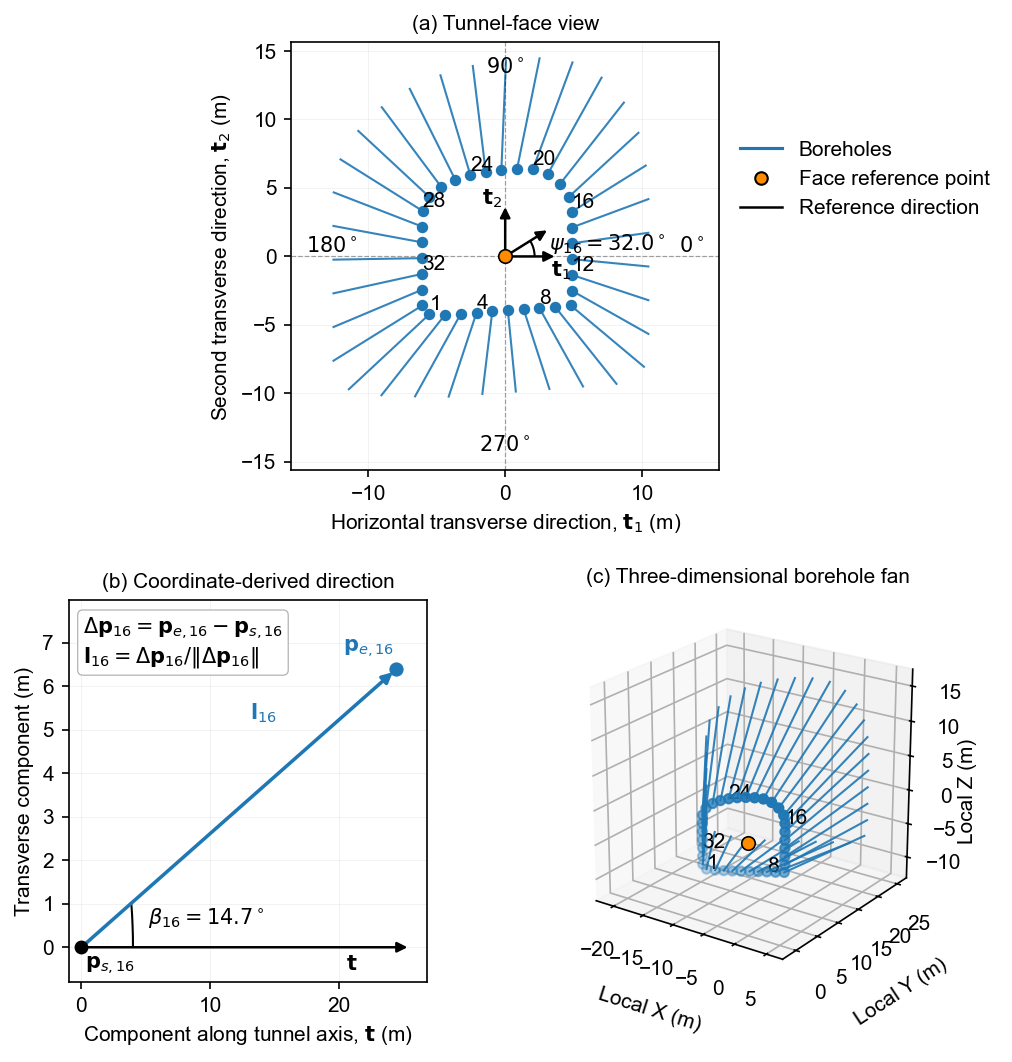

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_7_Haga_borehole_geometry.png
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_7_Haga_borehole_geometry.svg


In [7]:
# ============================================================
# CELL 7 — FIGURE 7: HAGA BOREHOLE GEOMETRY
#
# (a) Tunnel-face projection showing t1, t2 and psi_16
# (b) Coordinate-derived direction of Borehole 16
# (c) Three-dimensional borehole fan
#
# Journal-sized figure | Arial 10 | PNG 600 dpi + SVG
# ============================================================


# ============================================================
# 1. FIGURE STYLE
# ============================================================

# Smaller than full A4, but wide enough for the external legend.
# Font size remains 10 pt throughout.
FIG7_SIZE = (8.2, 7.2)

# Same color for all boreholes
BOREHOLE_COLOR = "C0"

# Reference geometry
REFERENCE_COLOR = "black"
FACE_POINT_COLOR = "darkorange"

BOREHOLE_LINEWIDTH = 1.0
BOREHOLE_ALPHA = 0.90
BOREHOLE_MARKER_SIZE = 20


# ============================================================
# 2. ARRAYS
# ============================================================

S = result[
    ["X_start", "Y_start", "Z_start"]
].to_numpy(dtype=float)

E = result[
    ["X_end", "Y_end", "Z_end"]
].to_numpy(dtype=float)

hole_ids = result[
    "Hole"
].astype(int).to_numpy()


# ============================================================
# 3. TUNNEL-FACE PROJECTION
#
# Coordinates projected onto t1 and t2.
# ============================================================

S_face = np.column_stack([
    S @ t1,
    S @ t2
])

E_face = np.column_stack([
    E @ t1,
    E @ t2
])


# ============================================================
# 4. BOREHOLE 16 VALUES
# ============================================================

beta16 = float(
    hole16["beta_deg"]
)

psi16 = float(
    hole16["psi_deg"]
)

psi16_rad = np.radians(
    psi16
)


# ------------------------------------------------------------
# Coordinate-derived Borehole 16 geometry
#
# Δp_16 = p_e,16 - p_s,16
# ------------------------------------------------------------

parallel16 = np.dot(
    delta_p16,
    t
)

transverse_vector16 = (
    delta_p16
    -
    parallel16 * t
)

transverse16 = np.linalg.norm(
    transverse_vector16
)


# ============================================================
# 5. CREATE FIGURE
# ============================================================

fig = plt.figure(
    figsize=FIG7_SIZE
)


gs = fig.add_gridspec(
    2,
    2,
    height_ratios=[
        1.12,
        1.0
    ],
    width_ratios=[
        1.0,
        1.08
    ],
    hspace=0.32,
    wspace=0.34
)


ax1 = fig.add_subplot(
    gs[0, :]
)

ax2 = fig.add_subplot(
    gs[1, 0]
)

ax3 = fig.add_subplot(
    gs[1, 1],
    projection="3d"
)


# ============================================================
# PANEL (a) — TUNNEL-FACE VIEW
# ============================================================

for start, end in zip(
    S_face,
    E_face
):
    ax1.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        color=BOREHOLE_COLOR,
        linewidth=BOREHOLE_LINEWIDTH,
        alpha=BOREHOLE_ALPHA
    )


# ------------------------------------------------------------
# Borehole collar positions
# ------------------------------------------------------------

ax1.scatter(
    S_face[:, 0],
    S_face[:, 1],
    s=BOREHOLE_MARKER_SIZE,
    color=BOREHOLE_COLOR,
    zorder=3
)


# ------------------------------------------------------------
# Face reference point
# ------------------------------------------------------------

ax1.scatter(
    0,
    0,
    s=42,
    color=FACE_POINT_COLOR,
    edgecolor="black",
    linewidth=0.8,
    zorder=6
)


# ------------------------------------------------------------
# Selected borehole labels
# ------------------------------------------------------------

label_holes = {
    1,
    4,
    8,
    12,
    16,
    20,
    24,
    28,
    32
}


for idx, hole in enumerate(
    hole_ids
):

    if hole in label_holes:

        ax1.text(
            S_face[idx, 0],
            S_face[idx, 1],
            str(hole),
            fontsize=10,
            ha="left",
            va="bottom"
        )


# ------------------------------------------------------------
# Plot limits
# ------------------------------------------------------------

all_face = np.vstack([
    S_face,
    E_face
])

face_limit = (
    np.max(
        np.abs(
            all_face
        )
    )
    * 1.08
)


# ============================================================
# LOCAL TUNNEL-FACE BASIS
# ============================================================

axis_length = (
    0.25
    *
    face_limit
)


# ------------------------------------------------------------
# t1 direction
# ------------------------------------------------------------

ax1.annotate(
    "",
    xy=(
        axis_length,
        0
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.2,
        color=REFERENCE_COLOR
    )
)


# ------------------------------------------------------------
# t2 direction
# ------------------------------------------------------------

ax1.annotate(
    "",
    xy=(
        0,
        axis_length
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.2,
        color=REFERENCE_COLOR
    )
)


ax1.text(
    axis_length * 1.05,
    -0.25,
    r"$\mathbf{t}_1$",
    fontsize=10,
    ha="center",
    va="top"
)

ax1.text(
    -0.20,
    axis_length * 1.08,
    r"$\mathbf{t}_2$",
    fontsize=10,
    ha="right",
    va="center"
)


# ============================================================
# psi_16 DIRECTION
# ============================================================

ax1.annotate(
    "",
    xy=(
        axis_length
        *
        np.cos(psi16_rad),

        axis_length
        *
        np.sin(psi16_rad)
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.2,
        color=REFERENCE_COLOR
    )
)


# ============================================================
# psi_16 ARC
# ============================================================

arc_radius = (
    axis_length
    *
    0.55
)


ax1.add_patch(
    Arc(
        (0, 0),
        2 * arc_radius,
        2 * arc_radius,
        theta1=0,
        theta2=psi16,
        linewidth=1.0,
        color=REFERENCE_COLOR
    )
)


half_psi = np.radians(
    psi16 / 2
)


ax1.text(
    arc_radius
    *
    1.55
    *
    np.cos(half_psi),

    arc_radius
    *
    1.55
    *
    np.sin(half_psi),

    rf"$\psi_{{16}}={psi16:.1f}^\circ$",

    fontsize=10,
    ha="left",
    va="center"
)


# ============================================================
# CIRCUMFERENTIAL REFERENCE LABELS
# ============================================================

ax1.text(
    0.965,
    0.50,
    r"$0^\circ$",
    transform=ax1.transAxes,
    fontsize=10,
    ha="right",
    va="bottom"
)

ax1.text(
    0.50,
    0.965,
    r"$90^\circ$",
    transform=ax1.transAxes,
    fontsize=10,
    ha="center",
    va="top"
)

ax1.text(
    0.035,
    0.50,
    r"$180^\circ$",
    transform=ax1.transAxes,
    fontsize=10,
    ha="left",
    va="bottom"
)

ax1.text(
    0.50,
    0.035,
    r"$270^\circ$",
    transform=ax1.transAxes,
    fontsize=10,
    ha="center",
    va="bottom"
)


# ------------------------------------------------------------
# Reference lines
# ------------------------------------------------------------

ax1.axhline(
    0,
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
    color=REFERENCE_COLOR
)

ax1.axvline(
    0,
    linestyle="--",
    linewidth=0.6,
    alpha=0.35,
    color=REFERENCE_COLOR
)


# ------------------------------------------------------------
# Panel (a) formatting
# ------------------------------------------------------------

ax1.set_xlim(
    -face_limit,
    face_limit
)

ax1.set_ylim(
    -face_limit,
    face_limit
)

ax1.set_aspect(
    "equal",
    adjustable="box"
)


ax1.set_xlabel(
    r"Horizontal transverse direction, $\mathbf{t}_1$ (m)"
)

ax1.set_ylabel(
    r"Second transverse direction, $\mathbf{t}_2$ (m)"
)

ax1.set_title(
    "(a) Tunnel-face view"
)


ax1.grid(
    True,
    linewidth=0.4,
    alpha=0.18
)


# ============================================================
# PANEL (a) — EXTERNAL LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=BOREHOLE_COLOR,
        linewidth=1.5,
        label="Boreholes"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=FACE_POINT_COLOR,
        markeredgecolor="black",
        markersize=6,
        label="Face reference point"
    ),

    Line2D(
        [0],
        [0],
        color=REFERENCE_COLOR,
        linewidth=1.2,
        label="Reference direction"
    )
]


ax1.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(
        1.03,
        0.68
    ),
    frameon=False,
    borderaxespad=0.0
)


# ============================================================
# PANEL (b) — COORDINATE-DERIVED BOREHOLE 16 DIRECTION
# ============================================================

# ------------------------------------------------------------
# Tunnel-axis reference direction
# ------------------------------------------------------------

ax2.annotate(
    "",
    xy=(
        parallel16 * 1.05,
        0
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.2,
        color=REFERENCE_COLOR
    )
)


# ------------------------------------------------------------
# Borehole 16 direction
# ------------------------------------------------------------

ax2.annotate(
    "",
    xy=(
        parallel16,
        transverse16
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.7,
        color=BOREHOLE_COLOR
    )
)


# ============================================================
# START POSITION p_s,16
# ============================================================

ax2.scatter(
    0,
    0,
    s=32,
    color="black",
    zorder=5
)


ax2.text(
    0.30,
    -0.18,
    r"$\mathbf{p}_{s,16}$",
    fontsize=10,
    ha="left",
    va="top"
)


# ============================================================
# END POSITION p_e,16
# ============================================================

ax2.scatter(
    parallel16,
    transverse16,
    s=34,
    color=BOREHOLE_COLOR,
    zorder=5
)


ax2.text(
    parallel16 - 0.15,
    transverse16 + 0.22,
    r"$\mathbf{p}_{e,16}$",
    fontsize=10,
    ha="right",
    va="bottom",
    color=BOREHOLE_COLOR
)


# ============================================================
# BOREHOLE DIRECTION UNIT VECTOR l_16
#
# Positioned above the borehole line.
# ============================================================

ax2.text(
    parallel16 * 0.58,
    transverse16 * 0.80,
    r"$\mathbf{l}_{16}$",
    fontsize=10,
    color=BOREHOLE_COLOR,
    ha="center",
    va="bottom"
)


# ============================================================
# TUNNEL-AXIS UNIT VECTOR t
# ============================================================

ax2.text(
    parallel16 * 0.86,
    -0.18,
    r"$\mathbf{t}$",
    fontsize=10,
    ha="center",
    va="top"
)


# ============================================================
# beta_16 ARC
# ============================================================

beta_radius = min(
    4.0,
    hole16["Length_m"] * 0.16
)


ax2.add_patch(
    Arc(
        (0, 0),
        2 * beta_radius,
        2 * beta_radius,
        theta1=0,
        theta2=beta16,
        linewidth=1.0,
        color=REFERENCE_COLOR
    )
)


beta_half = np.radians(
    beta16 / 2
)


ax2.text(
    beta_radius
    *
    1.30
    *
    np.cos(beta_half),

    beta_radius
    *
    1.30
    *
    np.sin(beta_half),

    rf"$\beta_{{16}}={beta16:.1f}^\circ$",

    fontsize=10,
    ha="left",
    va="center"
)


# ============================================================
# COORDINATE-DERIVED GEOMETRY EQUATIONS
# ============================================================

equation_text = (
    r"$\Delta\mathbf{p}_{16}"
    r"=\mathbf{p}_{e,16}-\mathbf{p}_{s,16}$"
    "\n"
    r"$\mathbf{l}_{16}"
    r"=\Delta\mathbf{p}_{16}/"
    r"\|\Delta\mathbf{p}_{16}\|$"
)


ax2.text(
    0.04,
    0.96,
    equation_text,
    transform=ax2.transAxes,
    fontsize=10,
    ha="left",
    va="top",
    bbox=dict(
        boxstyle="round,pad=0.25",
        facecolor="white",
        edgecolor="0.7",
        linewidth=0.6
    )
)


# ------------------------------------------------------------
# Panel (b) formatting
# ------------------------------------------------------------

ax2.set_xlabel(
    r"Component along tunnel axis, $\mathbf{t}$ (m)"
)

ax2.set_ylabel(
    "Transverse component (m)"
)

ax2.set_title(
    "(b) Coordinate-derived direction"
)


ax2.set_xlim(
    -1.0,
    parallel16 * 1.10
)

ax2.set_ylim(
    -0.8,
    transverse16 * 1.25
)


ax2.grid(
    True,
    linewidth=0.4,
    alpha=0.18
)


# ============================================================
# PANEL (c) — THREE-DIMENSIONAL BOREHOLE FAN
# ============================================================

for start, end in zip(
    S,
    E
):

    ax3.plot(
        [start[0], end[0]],
        [start[1], end[1]],
        [start[2], end[2]],
        color=BOREHOLE_COLOR,
        linewidth=BOREHOLE_LINEWIDTH,
        alpha=BOREHOLE_ALPHA
    )


# ------------------------------------------------------------
# Borehole collars
# ------------------------------------------------------------

ax3.scatter(
    S[:, 0],
    S[:, 1],
    S[:, 2],
    s=BOREHOLE_MARKER_SIZE,
    color=BOREHOLE_COLOR
)


# ------------------------------------------------------------
# Face reference point
# ------------------------------------------------------------

ax3.scatter(
    0,
    0,
    0,
    s=42,
    color=FACE_POINT_COLOR,
    edgecolor="black",
    linewidth=0.8,
    zorder=5
)


# ------------------------------------------------------------
# Selected borehole labels
# ------------------------------------------------------------

for idx, hole in enumerate(
    hole_ids
):

    if hole in {
        1,
        8,
        16,
        24,
        32
    }:

        ax3.text(
            S[idx, 0],
            S[idx, 1],
            S[idx, 2],
            str(hole),
            fontsize=10
        )


# ============================================================
# EQUAL APPROXIMATE 3D SCALING
# ============================================================

all_xyz = np.vstack([
    S,
    E
])


mins = all_xyz.min(
    axis=0
)

maxs = all_xyz.max(
    axis=0
)


mid = (
    mins
    +
    maxs
) / 2


max_range = np.max(
    maxs
    -
    mins
)


half_range = (
    max_range
    *
    0.53
)


ax3.set_xlim(
    mid[0] - half_range,
    mid[0] + half_range
)

ax3.set_ylim(
    mid[1] - half_range,
    mid[1] + half_range
)

ax3.set_zlim(
    mid[2] - half_range,
    mid[2] + half_range
)


ax3.set_box_aspect(
    (1, 1, 1)
)


ax3.view_init(
    elev=22,
    azim=-55
)


# ============================================================
# PANEL (c) AXIS LABELS
# ============================================================

ax3.set_xlabel(
    "Local X (m)",
    labelpad=5
)

ax3.set_ylabel(
    "Local Y (m)",
    labelpad=6
)


# ------------------------------------------------------------
# Use a 2D label for Z because matplotlib 3D labels are
# sometimes clipped when saved with bbox_inches="tight".
# ------------------------------------------------------------

ax3.text2D(
    1.05,
    0.50,
    "Local Z (m)",
    transform=ax3.transAxes,
    rotation=90,
    fontsize=10,
    ha="left",
    va="center"
)


ax3.set_title(
    "(c) Three-dimensional borehole fan",
    pad=8
)


# ============================================================
# 6. GLOBAL LAYOUT
#
# Right margin is intentionally reserved for:
# - panel (a) legend
# - panel (c) Local Z label
# ============================================================

fig.subplots_adjust(
    left=0.09,
    right=0.80,
    bottom=0.08,
    top=0.95,
    hspace=0.32,
    wspace=0.34
)


# ============================================================
# 7. SAVE FIGURE
# ============================================================

FIG7_PNG = (
    figure_dir
    /
    "Figure_7_Haga_borehole_geometry.png"
)

FIG7_SVG = (
    figure_dir
    /
    "Figure_7_Haga_borehole_geometry.svg"
)


fig.savefig(
    FIG7_PNG,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.18
)

fig.savefig(
    FIG7_SVG,
    bbox_inches="tight",
    pad_inches=0.18
)


plt.show()


print("Saved:")
print(FIG7_PNG)
print(FIG7_SVG)

# CAD comparison and validation statistics

In [8]:
# ============================================================
# CELL 8 — SG-1 VALIDATION AGAINST CAD RESULTS
# ============================================================


# ============================================================
# 1. PUBLISHED CAD HIT-RATE VALUES
#
# Funehag and Sjöli (2023)
#
# NaN = no numerical CAD value available
# ============================================================

sg1_cad_values = [

    8,        # Hole 1
    3,        # Hole 2
    np.nan,   # Hole 3
    5,        # Hole 4
    9,        # Hole 5
    12,       # Hole 6
    15,       # Hole 7
    19,       # Hole 8
    22,       # Hole 9
    21,       # Hole 10
    19,       # Hole 11
    15,       # Hole 12
    11,       # Hole 13
    8,        # Hole 14
    4,        # Hole 15
    np.nan,   # Hole 16
    5,        # Hole 17
    9,        # Hole 18
    14,       # Hole 19
    19,       # Hole 20
    23,       # Hole 21
    27,       # Hole 22
    32,       # Hole 23
    35,       # Hole 24
    37,       # Hole 25
    38,       # Hole 26
    37,       # Hole 27
    37,       # Hole 28
    34,       # Hole 29
    28,       # Hole 30
    24,       # Hole 31
    21,       # Hole 32
    17,       # Hole 33
    13        # Hole 34
]


cad_df = pd.DataFrame({

    "Hole":
        np.arange(
            1,
            35
        ),

    "SG1_hit_rate_CAD_pct":
        sg1_cad_values
})


# ============================================================
# 2. MERGE VECTOR AND CAD RESULTS
# ============================================================

comparison = pd.merge(
    result,
    cad_df,
    on="Hole",
    how="left"
)


# ============================================================
# 3. Eq. (24)
#
# Δh_i = h_i,Vector - h_i,CAD
#
# Units:
# percentage points
# ============================================================

comparison["Delta_h_pp"] = (

    comparison[
        "SG1_hit_rate_pct"
    ]

    -

    comparison[
        "SG1_hit_rate_CAD_pct"
    ]
)


comparison["Abs_Delta_h_pp"] = np.abs(
    comparison[
        "Delta_h_pp"
    ]
)


# ============================================================
# 4. PAIRED VALUES ONLY
# ============================================================

valid_mask = (

    comparison[
        "SG1_hit_rate_pct"
    ].notna()

    &

    comparison[
        "SG1_hit_rate_CAD_pct"
    ].notna()
)


valid_pairs = (
    comparison.loc[
        valid_mask
    ]
    .copy()
)


vector_values = valid_pairs[
    "SG1_hit_rate_pct"
].to_numpy(dtype=float)


cad_values = valid_pairs[
    "SG1_hit_rate_CAD_pct"
].to_numpy(dtype=float)


delta_h = (

    vector_values
    -
    cad_values
)


# ============================================================
# k = number of boreholes with paired vector-based and
# CAD-based hit-rate values
# ============================================================

k = len(
    delta_h
)


# ============================================================
# 5. VALIDATION METRICS
# ============================================================

# ------------------------------------------------------------
# Eq. (25)
#
# MAE = (1/k) Σ |Δh_i|
# ------------------------------------------------------------

mae = (

    1.0 / k
    *
    np.sum(
        np.abs(delta_h)
    )
)


# ------------------------------------------------------------
# Eq. (26)
#
# RMSE = sqrt[
#          (1/k) Σ (Δh_i)^2
#        ]
# ------------------------------------------------------------

rmse = np.sqrt(

    1.0 / k
    *
    np.sum(
        delta_h ** 2
    )
)


# ------------------------------------------------------------
# Eq. (27)
#
# Bias = (1/k) Σ Δh_i
# ------------------------------------------------------------

bias = (

    1.0 / k
    *
    np.sum(
        delta_h
    )
)


# Additional descriptive statistics
median_abs_difference = np.median(
    np.abs(delta_h)
)

max_abs_difference = np.max(
    np.abs(delta_h)
)


max_index = np.argmax(
    np.abs(delta_h)
)

max_difference_hole = int(
    valid_pairs.iloc[
        max_index
    ]["Hole"]
)

max_signed_difference = float(
    delta_h[
        max_index
    ]
)


# ============================================================
# 6. PEARSON CORRELATION
# ============================================================

pearson_r = np.corrcoef(
    vector_values,
    cad_values
)[0, 1]

r_squared = (
    pearson_r ** 2
)


# ============================================================
# 7. RESULTS
# ============================================================

print("SG-1 VECTOR-BASED METHOD vs CAD")
print("=" * 70)

print(
    f"k = {k}"
)

print(
    f"MAE = "
    f"{mae:.3f} percentage points"
)

print(
    f"RMSE = "
    f"{rmse:.3f} percentage points"
)

print(
    f"Bias = "
    f"{bias:+.3f} percentage points"
)

print(
    f"Median |Delta h| = "
    f"{median_abs_difference:.3f} percentage points"
)

print(
    f"Maximum |Delta h| = "
    f"{max_abs_difference:.3f} percentage points"
)

print(
    f"Maximum difference at Hole "
    f"{max_difference_hole}"
)

print(
    f"Signed difference there = "
    f"{max_signed_difference:+.3f} percentage points"
)

print(
    f"Pearson r = "
    f"{pearson_r:.6f}"
)

print(
    f"r^2 = "
    f"{r_squared:.6f}"
)


# ============================================================
# 8. METRICS TABLE
# ============================================================

metrics_table = pd.DataFrame({

    "Metric": [
        "Number of paired boreholes (k)",
        "Mean absolute difference (MAE)",
        "Root-mean-square difference (RMSE)",
        "Mean signed difference (bias)",
        "Median absolute difference",
        "Maximum absolute difference",
        "Borehole with maximum difference",
        "Pearson correlation (r)",
        "Squared Pearson correlation (r²)"
    ],

    "Value": [
        k,
        mae,
        rmse,
        bias,
        median_abs_difference,
        max_abs_difference,
        max_difference_hole,
        pearson_r,
        r_squared
    ],

    "Unit": [
        "-",
        "percentage points",
        "percentage points",
        "percentage points",
        "percentage points",
        "percentage points",
        "-",
        "-",
        "-"
    ]
})


display(metrics_table)

SG-1 VECTOR-BASED METHOD vs CAD
k = 32
MAE = 0.989 percentage points
RMSE = 1.526 percentage points
Bias = -0.699 percentage points
Median |Delta h| = 0.476 percentage points
Maximum |Delta h| = 3.729 percentage points
Maximum difference at Hole 28
Signed difference there = -3.729 percentage points
Pearson r = 0.995845
r^2 = 0.991708


,Metric,Value,Unit
0,Number of paired boreholes (k),32.000000,-
1,Mean absolute difference (MAE),0.988950,percentage points
2,Root-mean-square difference (RMSE),1.526254,percentage points
3,Mean signed difference (bias),-0.699498,percentage points
4,Median absolute difference,0.476267,percentage points
5,Maximum absolute difference,3.729280,percentage points
6,Borehole with maximum difference,28.000000,-
7,Pearson correlation (r),0.995845,-
8,Squared Pearson correlation (r²),0.991708,-


# Figure 8: vector-based versus CAD comparison

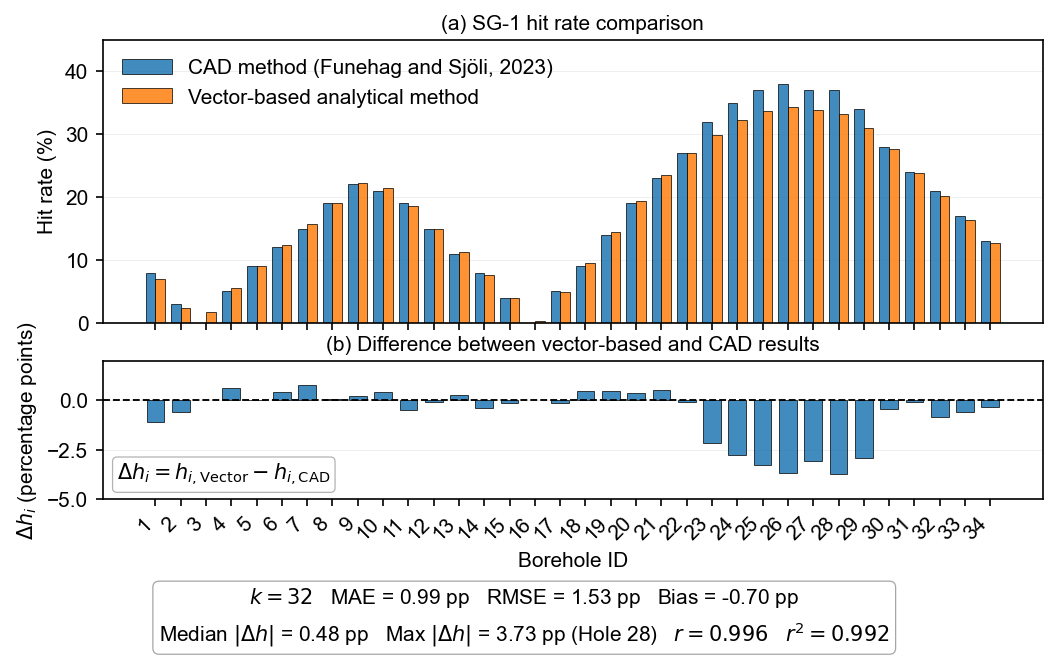

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_8_SG1_vector_CAD_validation.png
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_8_SG1_vector_CAD_validation.svg

Figure size: (7.2, 4.5) inches
Font size: 10 pt


In [9]:
# ============================================================
# CELL 9 — FIGURE 8: VECTOR-BASED vs CAD HIT RATE
#
# Journal-sized figure
# Arial 10 pt throughout
# PNG 600 dpi + SVG
#
# IMPORTANT:
# The figure is created close to its intended final manuscript
# size. This prevents 10 pt text from becoming visually small
# when the figure is inserted into the manuscript.
# ============================================================


# ============================================================
# 1. FIGURE STYLE
# ============================================================

FIG8_SIZE = (7.2, 4.5)

FONT_SIZE = 10


# Force publication font settings again in this cell so that
# settings from earlier notebook cells cannot change Fig. 8.
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans"],

    "font.size": FONT_SIZE,

    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,

    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,

    "legend.fontsize": FONT_SIZE,

    "axes.linewidth": 0.8,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "savefig.dpi": 600,

    # Keep SVG text editable
    "svg.fonttype": "none"
})


# ============================================================
# 2. FIGURE DATA
# ============================================================

holes = (
    comparison["Hole"]
    .astype(int)
    .to_numpy()
)


x = np.arange(
    len(holes)
)


vector_plot = (
    comparison[
        "SG1_hit_rate_pct"
    ]
    .to_numpy(dtype=float)
)


cad_plot = (
    comparison[
        "SG1_hit_rate_CAD_pct"
    ]
    .to_numpy(dtype=float)
)


delta_plot = (
    comparison[
        "Delta_h_pp"
    ]
    .to_numpy(dtype=float)
)


# ============================================================
# 3. CREATE JOURNAL-SIZED FIGURE
# ============================================================

fig, (
    ax1,
    ax2
) = plt.subplots(

    2,
    1,

    figsize=FIG8_SIZE,

    sharex=True,

    gridspec_kw={
        "height_ratios": [
            2.05,
            1.0
        ],

        "hspace": 0.18
    }
)


# Leave space below panel (b) for the statistics box.
fig.subplots_adjust(
    left=0.11,
    right=0.98,
    top=0.95,
    bottom=0.27
)


bar_width = 0.38


# ============================================================
# PANEL (a) — HIT RATE COMPARISON
# ============================================================

ax1.bar(
    x - bar_width / 2,
    cad_plot,

    width=bar_width,

    label="CAD method (Funehag and Sjöli, 2023)",

    alpha=0.85,

    edgecolor="black",
    linewidth=0.4
)


ax1.bar(
    x + bar_width / 2,
    vector_plot,

    width=bar_width,

    label="Vector-based analytical method",

    alpha=0.85,

    edgecolor="black",
    linewidth=0.4
)


# ------------------------------------------------------------
# Axis formatting
# ------------------------------------------------------------

ax1.set_ylabel(
    "Hit rate (%)",
    fontsize=FONT_SIZE
)


ax1.set_title(
    "(a) SG-1 hit rate comparison",
    fontsize=FONT_SIZE,
    pad=5
)


ax1.tick_params(
    axis="both",
    labelsize=FONT_SIZE
)


ax1.legend(
    loc="upper left",
    frameon=False,
    fontsize=FONT_SIZE,
    handlelength=2.4
)


ax1.grid(
    True,
    axis="y",
    linewidth=0.4,
    alpha=0.25
)


ax1.set_axisbelow(
    True
)


# Keep a little space above the tallest bar.
max_hit_rate = np.nanmax([
    np.nanmax(vector_plot),
    np.nanmax(cad_plot)
])


ax1.set_ylim(
    0,
    np.ceil(max_hit_rate / 5) * 5 + 5
)


# ============================================================
# PANEL (b) — DIFFERENCE BETWEEN METHODS
#
# Eq. (24)
#
# Δh_i = h_i,Vector - h_i,CAD
#
# Unit = percentage points
# ============================================================

ax2.bar(
    x,
    delta_plot,

    width=0.70,

    alpha=0.85,

    edgecolor="black",
    linewidth=0.4
)


ax2.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=0.9
)


# ============================================================
# Dynamic y-axis range
# ============================================================

finite_delta = delta_plot[
    np.isfinite(delta_plot)
]


lower_limit = np.floor(
    finite_delta.min()
    -
    0.5
)


upper_limit = np.ceil(
    finite_delta.max()
    +
    0.5
)


# Ensure some space around zero even if values are asymmetric
lower_limit = min(
    lower_limit,
    -1
)

upper_limit = max(
    upper_limit,
    1
)


ax2.set_ylim(
    lower_limit,
    upper_limit
)


# ------------------------------------------------------------
# Axis labels and title
# ------------------------------------------------------------

ax2.set_ylabel(
    r"$\Delta h_i$ (percentage points)",
    fontsize=FONT_SIZE
)


ax2.set_xlabel(
    "Borehole ID",
    fontsize=FONT_SIZE
)


ax2.set_title(
    "(b) Difference between vector-based and CAD results",
    fontsize=FONT_SIZE,
    pad=5
)


ax2.tick_params(
    axis="both",
    labelsize=FONT_SIZE
)


ax2.grid(
    True,
    axis="y",
    linewidth=0.4,
    alpha=0.25
)


ax2.set_axisbelow(
    True
)


# ============================================================
# Eq. (24) annotation
# ============================================================

ax2.text(
    0.015,
    0.08,

    r"$\Delta h_i"
    r"=h_{i,\mathrm{Vector}}"
    r"-h_{i,\mathrm{CAD}}$",

    transform=ax2.transAxes,

    fontsize=FONT_SIZE,

    ha="left",
    va="bottom",

    bbox=dict(
        boxstyle="round,pad=0.22",
        facecolor="white",
        edgecolor="0.70",
        linewidth=0.6
    )
)


# ============================================================
# 4. X-AXIS — ALL BOREHOLE IDS
# ============================================================

ax2.set_xticks(
    x
)


ax2.set_xticklabels(
    holes,
    rotation=45,
    ha="right",
    fontsize=FONT_SIZE
)


# ============================================================
# 5. VALIDATION STATISTICS
#
# k = number of paired vector-based and CAD-based values
# ============================================================

metrics_text = (

    rf"$k={k}$"
    "   "

    rf"MAE = {mae:.2f} pp"
    "   "

    rf"RMSE = {rmse:.2f} pp"
    "   "

    rf"Bias = {bias:+.2f} pp"

    "\n"

    rf"Median $|\Delta h|$ = "
    rf"{median_abs_difference:.2f} pp"
    "   "

    rf"Max $|\Delta h|$ = "
    rf"{max_abs_difference:.2f} pp "
    rf"(Hole {max_difference_hole})"
    "   "

    rf"$r={pearson_r:.3f}$"
    "   "

    rf"$r^2={r_squared:.3f}$"
)


fig.text(
    0.50,
    0.095,

    metrics_text,

    fontsize=FONT_SIZE,

    ha="center",
    va="center",

    linespacing=1.45,

    bbox=dict(
        boxstyle="round,pad=0.30",
        facecolor="white",
        edgecolor="0.65",
        linewidth=0.6
    )
)


# ============================================================
# 6. OPTIONAL PANEL LABEL ALIGNMENT / AXIS SPINES
# ============================================================

for ax in [
    ax1,
    ax2
]:

    for spine in ax.spines.values():
        spine.set_linewidth(
            0.8
        )


# ============================================================
# 7. SAVE FIGURE
# ============================================================

FIG8_PNG = (
    figure_dir
    /
    "Figure_8_SG1_vector_CAD_validation.png"
)


FIG8_SVG = (
    figure_dir
    /
    "Figure_8_SG1_vector_CAD_validation.svg"
)


fig.savefig(
    FIG8_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.10
)


fig.savefig(
    FIG8_SVG,

    bbox_inches="tight",

    pad_inches=0.10
)


plt.show()


print("Saved:")
print(FIG8_PNG)
print(FIG8_SVG)

print(
    "\nFigure size:",
    FIG8_SIZE,
    "inches"
)

print(
    "Font size:",
    FONT_SIZE,
    "pt"
)

# SG-2 and SG-3 hit rates

In [10]:
# ============================================================
# CELL 11 — HIT RATE FOR SG-2 AND SG-3
#
# Applies Eq. (18) to the original Haga borehole fan.
#
# Eq. (18):
#
# h_ij = | l_i · n_j |
#
# where:
#   l_i = borehole direction unit vector
#   n_j = joint plane normal unit vector
#
# Representative joint set orientations:
#
# SG-2 = 80° / 90°
# SG-3 = 305° / 55°
# ============================================================


# ============================================================
# 1. REPRESENTATIVE JOINT SET ORIENTATIONS
# ============================================================

SG2_STRIKE = 80.0
SG2_DIP = 90.0

SG3_STRIKE = 305.0
SG3_DIP = 55.0


# ============================================================
# 2. JOINT PLANE NORMAL UNIT VECTORS
#
# Eq. (14):
#
# n = [
#     sin(delta) cos(theta),
#    -sin(delta) sin(theta),
#     cos(delta)
# ]
#
# ENU coordinate convention:
#   +x = East
#   +y = North
#   +z = Up
#
# theta = RHR strike clockwise from North
# delta = dip downward from horizontal
# ============================================================

n_SG2 = joint_normal_rhr(
    SG2_STRIKE,
    SG2_DIP
)

n_SG3 = joint_normal_rhr(
    SG3_STRIKE,
    SG3_DIP
)


print("Joint plane normal unit vectors")
print("--------------------------------")

print(
    "SG-2:",
    np.round(
        n_SG2,
        6
    )
)

print(
    "SG-3:",
    np.round(
        n_SG3,
        6
    )
)


# ============================================================
# 3. CHECK EXPECTED NORMAL VECTORS
# ============================================================

expected_n_SG2 = np.array([
    0.173648,
    -0.984808,
    0.000000
])


expected_n_SG3 = np.array([
    0.469846,
    0.671010,
    0.573576
])


assert np.allclose(
    n_SG2,
    expected_n_SG2,
    atol=1e-6
), "SG-2 normal vector does not match the expected value."


assert np.allclose(
    n_SG3,
    expected_n_SG3,
    atol=1e-6
), "SG-3 normal vector does not match the expected value."


# ============================================================
# 4. BOREHOLE DIRECTION MATRIX
#
# Direction vectors were already calculated from the
# start and end coordinates in Cell 4.
# ============================================================

L_vectors = result[
    [
        "l_x",
        "l_y",
        "l_z"
    ]
].to_numpy(dtype=float)


# Confirm that every borehole direction vector has unit length
direction_norms = np.linalg.norm(
    L_vectors,
    axis=1
)


assert np.allclose(
    direction_norms,
    1.0,
    atol=1e-8
), "One or more borehole direction vectors are not unit vectors."


# ============================================================
# 5. CALCULATE HIT RATE
#
# Eq. (18):
#
# h_ij = | l_i · n_j |
#
# Multiply by 100 to express hit rate as percentage.
# ============================================================

result["SG2_hit_rate"] = np.abs(
    L_vectors @ n_SG2
)

result["SG3_hit_rate"] = np.abs(
    L_vectors @ n_SG3
)


result["SG2_hit_rate_pct"] = (
    result["SG2_hit_rate"]
    *
    100.0
)

result["SG3_hit_rate_pct"] = (
    result["SG3_hit_rate"]
    *
    100.0
)


# ============================================================
# 6. SUMMARY STATISTICS
# ============================================================

def hit_rate_summary(
    dataframe,
    column,
    joint_set_name
):

    values = dataframe[
        column
    ].to_numpy(dtype=float)

    min_index = np.nanargmin(
        values
    )

    max_index = np.nanargmax(
        values
    )

    minimum = values[
        min_index
    ]

    maximum = values[
        max_index
    ]

    minimum_hole = int(
        dataframe.iloc[
            min_index
        ]["Hole"]
    )

    maximum_hole = int(
        dataframe.iloc[
            max_index
        ]["Hole"]
    )

    mean_value = np.nanmean(
        values
    )

    median_value = np.nanmedian(
        values
    )

    return {
        "Joint set": joint_set_name,
        "Minimum hit rate (%)": minimum,
        "Minimum hole": minimum_hole,
        "Maximum hit rate (%)": maximum,
        "Maximum hole": maximum_hole,
        "Mean hit rate (%)": mean_value,
        "Median hit rate (%)": median_value
    }


SG2_summary = hit_rate_summary(
    result,
    "SG2_hit_rate_pct",
    "SG-2"
)


SG3_summary = hit_rate_summary(
    result,
    "SG3_hit_rate_pct",
    "SG-3"
)


orientation_summary = pd.DataFrame([
    SG2_summary,
    SG3_summary
])


# ============================================================
# 7. DISPLAY SUMMARY
# ============================================================

display(
    orientation_summary.round(2)
)


# ============================================================
# 8. DISPLAY BOREHOLE-BY-BOREHOLE VALUES
# ============================================================

SG23_results = result[
    [
        "Hole",
        "SG2_hit_rate_pct",
        "SG3_hit_rate_pct"
    ]
].copy()


SG23_results.columns = [
    "Hole",
    "SG-2 hit rate (%)",
    "SG-3 hit rate (%)"
]


display(
    SG23_results.round(2)
)


# ============================================================
# 9. PRINT VALUES FOR MANUSCRIPT TEXT
# ============================================================

print("\nSG-2")
print(
    f"Minimum = "
    f"{SG2_summary['Minimum hit rate (%)']:.2f}% "
    f"at Borehole {SG2_summary['Minimum hole']}"
)

print(
    f"Maximum = "
    f"{SG2_summary['Maximum hit rate (%)']:.2f}% "
    f"at Borehole {SG2_summary['Maximum hole']}"
)

print(
    f"Mean = "
    f"{SG2_summary['Mean hit rate (%)']:.2f}%"
)

print(
    f"Median = "
    f"{SG2_summary['Median hit rate (%)']:.2f}%"
)


print("\nSG-3")

print(
    f"Minimum = "
    f"{SG3_summary['Minimum hit rate (%)']:.2f}% "
    f"at Borehole {SG3_summary['Minimum hole']}"
)

print(
    f"Maximum = "
    f"{SG3_summary['Maximum hit rate (%)']:.2f}% "
    f"at Borehole {SG3_summary['Maximum hole']}"
)

print(
    f"Mean = "
    f"{SG3_summary['Mean hit rate (%)']:.2f}%"
)

print(
    f"Median = "
    f"{SG3_summary['Median hit rate (%)']:.2f}%"
)

Joint plane normal unit vectors
--------------------------------
SG-2: [ 0.173648 -0.984808  0.      ]
SG-3: [0.469846 0.67101  0.573576]


,Joint set,Minimum hit rate (%),Minimum hole,Maximum hit rate (%),Maximum hole,Mean hit rate (%),Median hit rate (%)
0,SG-2,89.45,34,99.85,13,94.44,94.11
1,SG-3,16.82,1,70.68,19,45.40,45.44


,Hole,SG-2 hit rate (%),SG-3 hit rate (%)
0,1,89.47,16.82
1,2,90.88,19.24
2,3,92.42,22.56
3,4,93.76,25.97
4,5,95.04,29.83
5,6,96.05,33.58
6,7,96.80,37.27
7,8,97.28,40.79
8,9,97.51,44.19
9,10,98.35,49.19



SG-2
Minimum = 89.45% at Borehole 34
Maximum = 99.85% at Borehole 13
Mean = 94.44%
Median = 94.11%

SG-3
Minimum = 16.82% at Borehole 1
Maximum = 70.68% at Borehole 19
Mean = 45.40%
Median = 45.44%


# Figure 9

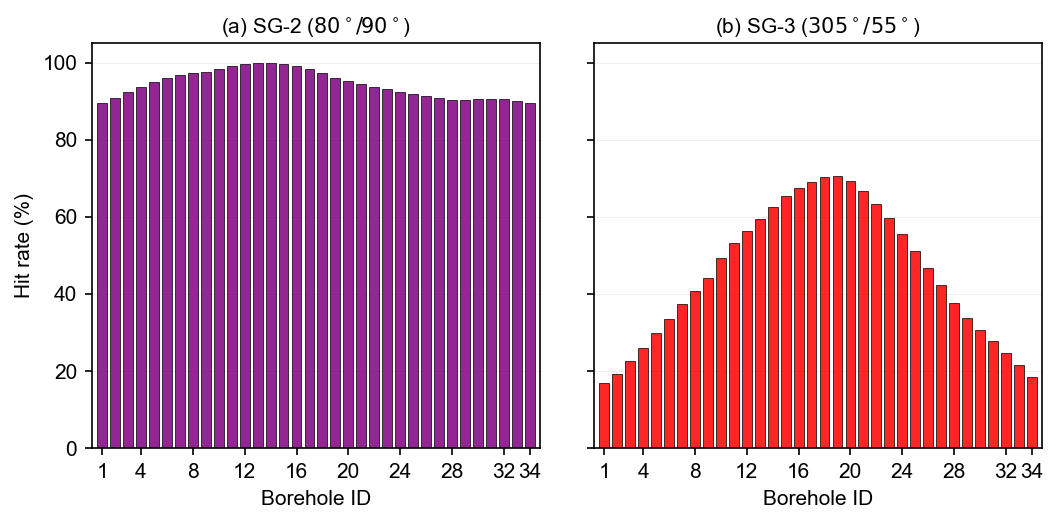

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_9_SG2_SG3_hit_rate.png
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_9_SG2_SG3_hit_rate.svg

Figure size: (7.2, 3.8) inches
Font size: 10 pt

SG-2:
Minimum = 89.45% at Borehole 34
Maximum = 99.85% at Borehole 13

SG-3:
Minimum = 16.82% at Borehole 1
Maximum = 70.68% at Borehole 19


In [11]:
# ============================================================
# CELL 12 — FIGURE 9:
# HIT RATE FOR SG-2 AND SG-3
#
# (a) SG-2
# (b) SG-3
#
# Original Haga borehole fan
# Representative joint set orientations:
#
# SG-2 = 80° / 90°
# SG-3 = 305° / 55°
#
# Color convention consistent with Fig. 6:
# SG-2 = purple
# SG-3 = red
#
# Journal-sized figure
# Arial 10 pt throughout
# PNG 600 dpi + SVG
# ============================================================


# ============================================================
# 1. FIGURE STYLE
# ============================================================

FIG9_SIZE = (7.2, 3.8)

FONT_SIZE = 10

SG2_COLOR = "purple"
SG3_COLOR = "red"


plt.rcParams.update({

    "font.family": "sans-serif",

    "font.sans-serif": [
        "Arial",
        "DejaVu Sans"
    ],

    "font.size": FONT_SIZE,

    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,

    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,

    "legend.fontsize": FONT_SIZE,

    "axes.linewidth": 0.8,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "savefig.dpi": 600,

    # Keep SVG text editable
    "svg.fonttype": "none"
})


# ============================================================
# 2. FIGURE DATA
# ============================================================

holes = (
    result["Hole"]
    .astype(int)
    .to_numpy()
)


sg2_plot = (
    result["SG2_hit_rate_pct"]
    .to_numpy(dtype=float)
)


sg3_plot = (
    result["SG3_hit_rate_pct"]
    .to_numpy(dtype=float)
)


x = np.arange(
    len(holes)
)


# ============================================================
# 3. SELECTED X-TICK LABELS
#
# All 34 boreholes are plotted.
# Only selected borehole IDs are labelled so that the
# 10 pt font remains readable.
# ============================================================

tick_holes = np.array([
    1,
    4,
    8,
    12,
    16,
    20,
    24,
    28,
    32,
    34
])


tick_positions = np.array([
    np.where(holes == h)[0][0]
    for h in tick_holes
])


# ============================================================
# 4. CREATE FIGURE
# ============================================================

fig, (
    ax1,
    ax2
) = plt.subplots(

    1,
    2,

    figsize=FIG9_SIZE,

    sharey=True
)


fig.subplots_adjust(

    left=0.10,
    right=0.98,

    top=0.91,
    bottom=0.20,

    wspace=0.12
)


# ============================================================
# PANEL (a) — SG-2
# ============================================================

ax1.bar(

    x,
    sg2_plot,

    width=0.76,

    color=SG2_COLOR,

    edgecolor="black",

    linewidth=0.4,

    alpha=0.85
)


ax1.set_title(
    r"(a) SG-2 ($80^\circ/90^\circ$)",
    fontsize=FONT_SIZE,
    pad=5
)


ax1.set_ylabel(
    "Hit rate (%)",
    fontsize=FONT_SIZE
)


ax1.set_xlabel(
    "Borehole ID",
    fontsize=FONT_SIZE
)


ax1.set_ylim(
    0,
    105
)


ax1.set_yticks(
    np.arange(
        0,
        101,
        20
    )
)


ax1.set_xlim(
    -0.8,
    len(holes) - 0.2
)


ax1.set_xticks(
    tick_positions
)


ax1.set_xticklabels(
    tick_holes,
    fontsize=FONT_SIZE
)


ax1.tick_params(
    axis="both",
    labelsize=FONT_SIZE
)


ax1.grid(

    True,

    axis="y",

    linewidth=0.4,

    alpha=0.25
)


ax1.set_axisbelow(
    True
)


# ============================================================
# PANEL (b) — SG-3
# ============================================================

ax2.bar(

    x,
    sg3_plot,

    width=0.76,

    color=SG3_COLOR,

    edgecolor="black",

    linewidth=0.4,

    alpha=0.85
)


ax2.set_title(
    r"(b) SG-3 ($305^\circ/55^\circ$)",
    fontsize=FONT_SIZE,
    pad=5
)


ax2.set_xlabel(
    "Borehole ID",
    fontsize=FONT_SIZE
)


ax2.set_ylim(
    0,
    105
)


ax2.set_xlim(
    -0.8,
    len(holes) - 0.2
)


ax2.set_xticks(
    tick_positions
)


ax2.set_xticklabels(
    tick_holes,
    fontsize=FONT_SIZE
)


ax2.tick_params(
    axis="both",
    labelsize=FONT_SIZE
)


ax2.grid(

    True,

    axis="y",

    linewidth=0.4,

    alpha=0.25
)


ax2.set_axisbelow(
    True
)


# ============================================================
# 5. AXIS SPINES
# ============================================================

for ax in [
    ax1,
    ax2
]:

    for spine in ax.spines.values():

        spine.set_linewidth(
            0.8
        )


# ============================================================
# 6. SAVE FIGURE
# ============================================================

FIG9_PNG = (
    figure_dir
    /
    "Figure_9_SG2_SG3_hit_rate.png"
)


FIG9_SVG = (
    figure_dir
    /
    "Figure_9_SG2_SG3_hit_rate.svg"
)


fig.savefig(

    FIG9_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.10
)


fig.savefig(

    FIG9_SVG,

    bbox_inches="tight",

    pad_inches=0.10
)


plt.show()


# ============================================================
# 7. PRINT OUTPUT INFORMATION
# ============================================================

print("Saved:")
print(FIG9_PNG)
print(FIG9_SVG)


print(
    "\nFigure size:",
    FIG9_SIZE,
    "inches"
)


print(
    "Font size:",
    FONT_SIZE,
    "pt"
)


print("\nSG-2:")

print(
    f"Minimum = {sg2_plot.min():.2f}% "
    f"at Borehole "
    f"{holes[np.argmin(sg2_plot)]}"
)

print(
    f"Maximum = {sg2_plot.max():.2f}% "
    f"at Borehole "
    f"{holes[np.argmax(sg2_plot)]}"
)


print("\nSG-3:")

print(
    f"Minimum = {sg3_plot.min():.2f}% "
    f"at Borehole "
    f"{holes[np.argmin(sg3_plot)]}"
)

print(
    f"Maximum = {sg3_plot.max():.2f}% "
    f"at Borehole "
    f"{holes[np.argmax(sg3_plot)]}"
)

# orientation sensitivity calculation

In [12]:
# ============================================================
# CELL 13 — JOINT ORIENTATION SENSITIVITY ANALYSIS
#
# Bounded geometric sensitivity analysis for:
#
# SG-1 = 155° ±30° / 50° ±20°
# SG-2 =  80° ±20° / 90° ±30°
# SG-3 = 305° ±30° / 55° ±15°
#
# Strike and dip are varied independently at 1° increments.
#
# IMPORTANT:
# The resulting min-max range is a geometric sensitivity
# envelope. It is NOT a confidence interval and no probability
# distribution is assigned to the orientations.
# ============================================================


# ============================================================
# 1. SENSITIVITY SETTINGS
# ============================================================

ORIENTATION_STEP = 1.0   # degrees


joint_sets_sensitivity = {

    "SG-1": {
        "strike": 155.0,
        "dip": 50.0,
        "strike_variation": 30.0,
        "dip_variation": 20.0
    },

    "SG-2": {
        "strike": 80.0,
        "dip": 90.0,
        "strike_variation": 20.0,
        "dip_variation": 30.0
    },

    "SG-3": {
        "strike": 305.0,
        "dip": 55.0,
        "strike_variation": 30.0,
        "dip_variation": 15.0
    }
}


# ============================================================
# 2. CANONICAL RHR ORIENTATION
#
# Our RHR convention uses:
#
# strike = 0° to <360°
# dip    = 0° to 90°
#
# For example:
#
# strike = 80°, dip = 110°
#
# represents the same plane as:
#
# strike = 260°, dip = 70°
#
# because the plane-normal direction may be reversed without
# changing the plane.
#
# This is especially important for SG-2:
#
# 90° ±30° dip -> nominal sensitivity range 60° to 120°.
# ============================================================

def canonical_rhr_orientation(
    strike_deg,
    dip_deg
):

    strike = float(strike_deg) % 360.0
    dip = float(dip_deg)

    # Handle negative dip if ever encountered
    if dip < 0.0:

        dip = -dip

        strike = (
            strike
            +
            180.0
        ) % 360.0


    # Convert dips greater than 90° to the equivalent
    # right-hand-rule representation.
    if dip > 90.0:

        dip = (
            180.0
            -
            dip
        )

        strike = (
            strike
            +
            180.0
        ) % 360.0


    if not (
        0.0
        <= dip
        <= 90.0
    ):

        raise ValueError(
            f"Canonical dip outside 0–90°: {dip}"
        )


    return strike, dip


# ============================================================
# 3. BOREHOLE DIRECTION VECTORS
# ============================================================

L_vectors = result[
    [
        "l_x",
        "l_y",
        "l_z"
    ]
].to_numpy(dtype=float)


# Verify unit length
assert np.allclose(
    np.linalg.norm(
        L_vectors,
        axis=1
    ),
    1.0,
    atol=1e-8
)


holes_sensitivity = (
    result["Hole"]
    .astype(int)
    .to_numpy()
)


# ============================================================
# 4. SENSITIVITY FUNCTION
# ============================================================

def calculate_orientation_sensitivity(
    joint_set_name,
    parameters,
    step_deg=1.0
):

    strike_rep = parameters[
        "strike"
    ]

    dip_rep = parameters[
        "dip"
    ]

    strike_var = parameters[
        "strike_variation"
    ]

    dip_var = parameters[
        "dip_variation"
    ]


    # --------------------------------------------------------
    # Representative orientation
    # --------------------------------------------------------

    strike_rep_canonical, dip_rep_canonical = (
        canonical_rhr_orientation(
            strike_rep,
            dip_rep
        )
    )


    n_rep = joint_normal_rhr(
        strike_rep_canonical,
        dip_rep_canonical
    )


    representative_hit_rate = (
        np.abs(
            L_vectors
            @
            n_rep
        )
        *
        100.0
    )


    # --------------------------------------------------------
    # Orientation ranges
    # --------------------------------------------------------

    strike_values = np.arange(
        strike_rep - strike_var,
        strike_rep + strike_var + step_deg / 2.0,
        step_deg
    )


    dip_values = np.arange(
        dip_rep - dip_var,
        dip_rep + dip_var + step_deg / 2.0,
        step_deg
    )


    # --------------------------------------------------------
    # Evaluate every strike-dip combination
    # --------------------------------------------------------

    all_hit_rates = []


    for strike_value in strike_values:

        for dip_value in dip_values:

            strike_canonical, dip_canonical = (
                canonical_rhr_orientation(
                    strike_value,
                    dip_value
                )
            )


            n_current = joint_normal_rhr(
                strike_canonical,
                dip_canonical
            )


            hit_rate_current = (
                np.abs(
                    L_vectors
                    @
                    n_current
                )
                *
                100.0
            )


            all_hit_rates.append(
                hit_rate_current
            )


    all_hit_rates = np.asarray(
        all_hit_rates,
        dtype=float
    )


    # --------------------------------------------------------
    # Min-max sensitivity envelope for every borehole
    # --------------------------------------------------------

    minimum_hit_rate = np.min(
        all_hit_rates,
        axis=0
    )


    maximum_hit_rate = np.max(
        all_hit_rates,
        axis=0
    )


    envelope_width = (
        maximum_hit_rate
        -
        minimum_hit_rate
    )


    # --------------------------------------------------------
    # Return all values
    # --------------------------------------------------------

    return {

        "joint_set":
            joint_set_name,

        "representative":
            representative_hit_rate,

        "minimum":
            minimum_hit_rate,

        "maximum":
            maximum_hit_rate,

        "width":
            envelope_width,

        "strike_values":
            strike_values,

        "dip_values":
            dip_values,

        "n_combinations":
            len(strike_values)
            *
            len(dip_values)
    }


# ============================================================
# 5. CALCULATE SG-1, SG-2 AND SG-3
# ============================================================

sensitivity_results = {}


for joint_set_name, parameters in (
    joint_sets_sensitivity.items()
):

    sensitivity_results[
        joint_set_name
    ] = calculate_orientation_sensitivity(

        joint_set_name,

        parameters,

        step_deg=ORIENTATION_STEP
    )


# ============================================================
# 6. ADD RESULTS TO DATAFRAME
# ============================================================

for joint_set_name in [
    "SG-1",
    "SG-2",
    "SG-3"
]:

    key = joint_set_name.replace(
        "-",
        ""
    )


    result[
        f"{key}_representative_pct"
    ] = sensitivity_results[
        joint_set_name
    ]["representative"]


    result[
        f"{key}_sensitivity_min_pct"
    ] = sensitivity_results[
        joint_set_name
    ]["minimum"]


    result[
        f"{key}_sensitivity_max_pct"
    ] = sensitivity_results[
        joint_set_name
    ]["maximum"]


    result[
        f"{key}_sensitivity_width_pp"
    ] = sensitivity_results[
        joint_set_name
    ]["width"]


# ============================================================
# 7. SUMMARY TABLE
# ============================================================

sensitivity_summary_rows = []


for joint_set_name in [
    "SG-1",
    "SG-2",
    "SG-3"
]:

    data = sensitivity_results[
        joint_set_name
    ]


    width_max_index = np.argmax(
        data["width"]
    )


    sensitivity_summary_rows.append({

        "Joint set":
            joint_set_name,

        "Representative minimum (%)":
            np.min(
                data["representative"]
            ),

        "Representative maximum (%)":
            np.max(
                data["representative"]
            ),

        "Envelope minimum (%)":
            np.min(
                data["minimum"]
            ),

        "Envelope maximum (%)":
            np.max(
                data["maximum"]
            ),

        "Maximum envelope width (pp)":
            np.max(
                data["width"]
            ),

        "Hole with maximum envelope width":
            int(
                holes_sensitivity[
                    width_max_index
                ]
            ),

        "Orientation combinations":
            data["n_combinations"]
    })


sensitivity_summary = pd.DataFrame(
    sensitivity_summary_rows
)


display(
    sensitivity_summary.round(2)
)


# ============================================================
# 8. PRINT REPRODUCIBILITY INFORMATION
# ============================================================

print(
    "Orientation sensitivity analysis"
)

print(
    "=" * 60
)


for joint_set_name in [
    "SG-1",
    "SG-2",
    "SG-3"
]:

    parameters = joint_sets_sensitivity[
        joint_set_name
    ]

    data = sensitivity_results[
        joint_set_name
    ]


    print(
        f"\n{joint_set_name}"
    )

    print(
        f"Representative orientation = "
        f"{parameters['strike']:.0f}°/"
        f"{parameters['dip']:.0f}°"
    )

    print(
        f"Strike range = "
        f"{parameters['strike'] - parameters['strike_variation']:.0f}° "
        f"to "
        f"{parameters['strike'] + parameters['strike_variation']:.0f}°"
    )

    print(
        f"Dip range = "
        f"{parameters['dip'] - parameters['dip_variation']:.0f}° "
        f"to "
        f"{parameters['dip'] + parameters['dip_variation']:.0f}°"
    )

    print(
        f"Number of strike-dip combinations = "
        f"{data['n_combinations']}"
    )

    print(
        f"Representative hit rate range = "
        f"{np.min(data['representative']):.2f}% "
        f"to "
        f"{np.max(data['representative']):.2f}%"
    )

    print(
        f"Overall sensitivity envelope = "
        f"{np.min(data['minimum']):.2f}% "
        f"to "
        f"{np.max(data['maximum']):.2f}%"
    )

,Joint set,Representative minimum (%),Representative maximum (%),Envelope minimum (%),Envelope maximum (%),Maximum envelope width (pp),Hole with maximum envelope width,Orientation combinations
0,SG-1,0.37,34.14,0.00,74.08,74.07,10,2501
1,SG-2,89.45,99.85,50.47,100.00,49.33,1,2501
2,SG-3,16.82,70.68,0.00,96.55,82.56,26,1891


Orientation sensitivity analysis

SG-1
Representative orientation = 155°/50°
Strike range = 125° to 185°
Dip range = 30° to 70°
Number of strike-dip combinations = 2501
Representative hit rate range = 0.37% to 34.14%
Overall sensitivity envelope = 0.00% to 74.08%

SG-2
Representative orientation = 80°/90°
Strike range = 60° to 100°
Dip range = 60° to 120°
Number of strike-dip combinations = 2501
Representative hit rate range = 89.45% to 99.85%
Overall sensitivity envelope = 50.47% to 100.00%

SG-3
Representative orientation = 305°/55°
Strike range = 275° to 335°
Dip range = 40° to 70°
Number of strike-dip combinations = 1891
Representative hit rate range = 16.82% to 70.68%
Overall sensitivity envelope = 0.00% to 96.55%


# Fig. 10,

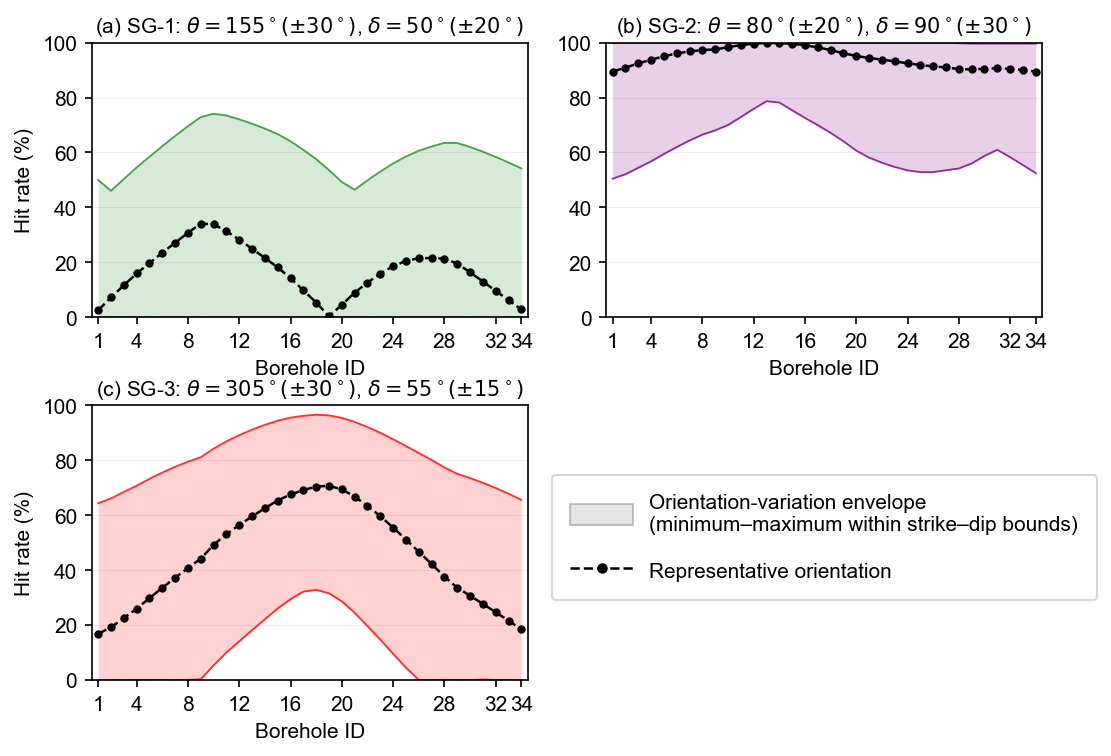

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_10_joint_orientation_sensitivity.png
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_10_joint_orientation_sensitivity.svg

Figure size: (7.2, 5) inches
Font size: 10 pt


In [13]:
# ============================================================
# CELL 14 — FIGURE 10:
# SENSITIVITY OF HIT RATE TO JOINT ORIENTATION VARIATION
#
# Layout:
#
#       (a) SG-1        (b) SG-2
#
#       (c) SG-3        Common legend
#
# Dashed black line:
# representative joint set orientation
#
# Shaded region:
# minimum–maximum hit rate obtained within the
# reported strike–dip bounds
#
# Journal-sized figure
# Arial 10 pt throughout
# PNG 600 dpi + SVG
# ============================================================


# ============================================================
# 1. FIGURE STYLE
# ============================================================

FIG10_SIZE = (
    7.2,
    5
)

FONT_SIZE = 10


# Colors consistent with Fig. 6
SG1_COLOR = "forestgreen"
SG2_COLOR = "purple"
SG3_COLOR = "red"


plt.rcParams.update({

    "font.family":
        "sans-serif",

    "font.sans-serif": [
        "Arial",
        "DejaVu Sans"
    ],

    "font.size":
        FONT_SIZE,

    "axes.labelsize":
        FONT_SIZE,

    "axes.titlesize":
        FONT_SIZE,

    "xtick.labelsize":
        FONT_SIZE,

    "ytick.labelsize":
        FONT_SIZE,

    "legend.fontsize":
        FONT_SIZE,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "savefig.dpi":
        600,

    # Keep text editable in SVG
    "svg.fonttype":
        "none"
})


# ============================================================
# 2. DATA
# ============================================================

holes = (
    result["Hole"]
    .astype(int)
    .to_numpy()
)


# Selected borehole IDs for readable 10 pt labels
tick_holes = np.array([
    1,
    4,
    8,
    12,
    16,
    20,
    24,
    28,
    32,
    34
])


# ============================================================
# 3. CREATE 2 × 2 FIGURE
# ============================================================

fig = plt.figure(
    figsize=FIG10_SIZE
)


gs = fig.add_gridspec(

    2,
    2,

    height_ratios=[
        1.0,
        1.0
    ],

    width_ratios=[
        1.0,
        1.0
    ],

    hspace=0.32,

    wspace=0.18
)


# Scientific panels
ax1 = fig.add_subplot(
    gs[0, 0]
)

ax2 = fig.add_subplot(
    gs[0, 1]
)

ax3 = fig.add_subplot(
    gs[1, 0]
)


# Empty panel reserved for legend
ax4 = fig.add_subplot(
    gs[1, 1]
)


fig.subplots_adjust(

    left=0.10,

    right=0.98,

    top=0.95,

    bottom=0.10
)


# ============================================================
# 4. HELPER FUNCTION
# ============================================================

def plot_sensitivity_panel(
    ax,
    joint_set_name,
    color,
    panel_label,
    show_ylabel=True
):

    # --------------------------------------------------------
    # Retrieve sensitivity results
    # --------------------------------------------------------

    data = sensitivity_results[
        joint_set_name
    ]

    parameters = joint_sets_sensitivity[
        joint_set_name
    ]


    representative = data[
        "representative"
    ]

    minimum = data[
        "minimum"
    ]

    maximum = data[
        "maximum"
    ]


    # ========================================================
    # ORIENTATION-VARIATION ENVELOPE
    # ========================================================

    ax.fill_between(

        holes,

        minimum,

        maximum,

        color=color,

        alpha=0.18,

        linewidth=0
    )


    # --------------------------------------------------------
    # Lower envelope boundary
    # --------------------------------------------------------

    ax.plot(

        holes,

        minimum,

        color=color,

        linewidth=0.9,

        alpha=0.80
    )


    # --------------------------------------------------------
    # Upper envelope boundary
    # --------------------------------------------------------

    ax.plot(

        holes,

        maximum,

        color=color,

        linewidth=0.9,

        alpha=0.80
    )


    # ========================================================
    # REPRESENTATIVE ORIENTATION
    # ========================================================

    ax.plot(

        holes,

        representative,

        color="black",

        linestyle="--",

        linewidth=1.2,

        marker="o",

        markersize=3.0,

        markerfacecolor="black",

        markeredgecolor="black"
    )


    # ========================================================
    # PANEL TITLE
    # ========================================================

    strike = parameters[
        "strike"
    ]

    dip = parameters[
        "dip"
    ]

    strike_var = parameters[
        "strike_variation"
    ]

    dip_var = parameters[
        "dip_variation"
    ]


    title_text = (

        rf"{panel_label} {joint_set_name}: "

        rf"$\theta={strike:.0f}^\circ"
        rf"(\pm{strike_var:.0f}^\circ)$, "

        rf"$\delta={dip:.0f}^\circ"
        rf"(\pm{dip_var:.0f}^\circ)$"
    )


    ax.set_title(

        title_text,

        fontsize=FONT_SIZE,

        pad=5
    )


    # ========================================================
    # AXES
    # ========================================================

    ax.set_xlim(
        0.5,
        34.5
    )


    ax.set_ylim(
        0,
        100
    )


    ax.set_yticks(
        np.arange(
            0,
            101,
            20
        )
    )


    if show_ylabel:

        ax.set_ylabel(
            "Hit rate (%)",
            fontsize=FONT_SIZE
        )


    ax.set_xlabel(
        "Borehole ID",
        fontsize=FONT_SIZE
    )


    ax.set_xticks(
        tick_holes
    )


    ax.set_xticklabels(

        tick_holes,

        fontsize=FONT_SIZE
    )


    ax.tick_params(

        axis="both",

        labelsize=FONT_SIZE
    )


    # ========================================================
    # GRID
    # ========================================================

    ax.grid(

        True,

        axis="y",

        linewidth=0.4,

        alpha=0.25
    )


    ax.set_axisbelow(
        True
    )


    # ========================================================
    # SPINES
    # ========================================================

    for spine in ax.spines.values():

        spine.set_linewidth(
            0.8
        )


# ============================================================
# 5. PANEL (a) — SG-1
# ============================================================

plot_sensitivity_panel(

    ax=ax1,

    joint_set_name="SG-1",

    color=SG1_COLOR,

    panel_label="(a)",

    show_ylabel=True
)


# ============================================================
# 6. PANEL (b) — SG-2
# ============================================================

plot_sensitivity_panel(

    ax=ax2,

    joint_set_name="SG-2",

    color=SG2_COLOR,

    panel_label="(b)",

    show_ylabel=False
)


# ============================================================
# 7. PANEL (c) — SG-3
# ============================================================

plot_sensitivity_panel(

    ax=ax3,

    joint_set_name="SG-3",

    color=SG3_COLOR,

    panel_label="(c)",

    show_ylabel=True
)


# ============================================================
# 8. FOURTH PANEL — COMMON LEGEND
# ============================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# Hide fourth-panel axes
ax4.axis(
    "off"
)


# ------------------------------------------------------------
# Legend objects
# ------------------------------------------------------------

legend_handles = [

    Patch(

        facecolor="0.75",

        edgecolor="0.45",

        alpha=0.40,

        label=(
            "Orientation-variation envelope\n"
            "(minimum–maximum within strike–dip bounds)"
        )
    ),

    Line2D(

        [0],
        [0],

        color="black",

        linestyle="--",

        marker="o",

        markerfacecolor="black",

        markeredgecolor="black",

        markersize=4,

        linewidth=1.2,

        label="Representative orientation"
    )
]


# ------------------------------------------------------------
# Place legend in centre of empty fourth panel
# ------------------------------------------------------------

ax4.legend(

    handles=legend_handles,

    loc="center",

    bbox_to_anchor=(
        0.50,
        0.52
    ),

    frameon=True,

    fontsize=FONT_SIZE,

    handlelength=3.0,

    handleheight=1.2,

    borderpad=0.9,

    labelspacing=1.2
)


# ============================================================
# 9. SAVE FIGURE — PNG + SVG
# ============================================================

FIG10_PNG = (
    figure_dir
    /
    "Figure_10_joint_orientation_sensitivity.png"
)


FIG10_SVG = (
    figure_dir
    /
    "Figure_10_joint_orientation_sensitivity.svg"
)


fig.savefig(

    FIG10_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.10
)


fig.savefig(

    FIG10_SVG,

    bbox_inches="tight",

    pad_inches=0.10
)


plt.show()


# ============================================================
# 10. PRINT OUTPUT INFORMATION
# ============================================================

print("Saved:")

print(
    FIG10_PNG
)

print(
    FIG10_SVG
)


print(
    "\nFigure size:",
    FIG10_SIZE,
    "inches"
)


print(
    "Font size:",
    FONT_SIZE,
    "pt"
)

# geometry calculation functions and audit setup

In [14]:
# ============================================================
# CELL 15 — REORIENTATION GEOMETRY SETUP
#
# Defines:
#   - selected reoriented boreholes
#   - Haga tunnel basis vectors t, t1, t2
#   - coordinate-based borehole geometry function
#   - shortest signed circumferential-angle change
#
# Used by:
#   Cell 16 — reorientation geometry table
#   Cell 17 — Borehole 5 reorientation figure
#   later reorientation figures
# ============================================================

import numpy as np
import pandas as pd


# ============================================================
# 1. SELECTED BOREHOLES FOR REORIENTATION
# ============================================================

REORIENTED_HOLES = [
    3, 4, 5, 6, 7,
    14, 15, 16, 17,
    19, 20, 21, 22, 23,
    31, 32, 33, 34
]


print(
    "Number of selected reoriented boreholes:",
    len(REORIENTED_HOLES)
)

print(
    "Selected boreholes:",
    REORIENTED_HOLES
)


# ============================================================
# 2. HAGA TUNNEL ORIENTATION
#
# Global coordinate system:
#   +x = East
#   +y = North
#   +z = Up
#
# Azimuth:
#   clockwise from North
#
# Tunnel plunge:
#   positive downward
# ============================================================

AZ_t_deg = 340.0
PZ_t_deg = 0.0


AZ_t = np.radians(
    AZ_t_deg
)

PZ_t = np.radians(
    PZ_t_deg
)


# ============================================================
# 3. LOCAL TUNNEL BASIS
# ============================================================

# ------------------------------------------------------------
# Eq. (11)
# Tunnel-axis unit vector
# ------------------------------------------------------------

t = np.array(
    [
        np.cos(PZ_t) * np.sin(AZ_t),
        np.cos(PZ_t) * np.cos(AZ_t),
        -np.sin(PZ_t)
    ],
    dtype=float
)


# ------------------------------------------------------------
# Eq. (12)
# Horizontal transverse unit vector
# ------------------------------------------------------------

t1 = np.array(
    [
        np.cos(AZ_t),
        -np.sin(AZ_t),
        0.0
    ],
    dtype=float
)


# ------------------------------------------------------------
# Eq. (13)
#
# IMPORTANT:
#
#     t2 = t1 × t
#
# Ordered right-handed basis:
#
#     {t1, t, t2}
# ------------------------------------------------------------

t2 = np.cross(
    t1,
    t
)


# ------------------------------------------------------------
# Normalize for numerical safety
# ------------------------------------------------------------

t = (
    t
    /
    np.linalg.norm(t)
)

t1 = (
    t1
    /
    np.linalg.norm(t1)
)

t2 = (
    t2
    /
    np.linalg.norm(t2)
)


# ============================================================
# 4. CHECK LOCAL TUNNEL BASIS
# ============================================================

print(
    "\nLOCAL TUNNEL BASIS"
)

print(
    "=" * 60
)

print(
    "AZ_t =",
    AZ_t_deg,
    "deg"
)

print(
    "PZ_t =",
    PZ_t_deg,
    "deg"
)


print(
    "\nt  =",
    np.round(
        t,
        6
    )
)

print(
    "t1 =",
    np.round(
        t1,
        6
    )
)

print(
    "t2 =",
    np.round(
        t2,
        6
    )
)


print(
    "\nORTHOGONALITY CHECK"
)

print(
    "t · t1  =",
    np.dot(
        t,
        t1
    )
)

print(
    "t · t2  =",
    np.dot(
        t,
        t2
    )
)

print(
    "t1 · t2 =",
    np.dot(
        t1,
        t2
    )
)


print(
    "\nHANDEDNESS CHECK"
)

print(
    "t1 × t =",
    np.round(
        np.cross(
            t1,
            t
        ),
        6
    )
)

print(
    "t2     =",
    np.round(
        t2,
        6
    )
)


# ============================================================
# 5. BOREHOLE GEOMETRY FROM START AND END COORDINATES
#
# Manuscript:
#
# Δp_i = p_e,i - p_s,i
#
# L_i = ||Δp_i||
#
# l_i = Δp_i / L_i
#
# beta_i = acos(l_i · t)
#
# psi_i = atan2(
#     l_i · t2,
#     l_i · t1
# )
#
# psi expressed from 0° to 360°
# ============================================================

def calculate_borehole_geometry(
    p_start,
    p_end
):
    """
    Calculate borehole geometry directly from three-dimensional
    start and end coordinates.

    Parameters
    ----------
    p_start : array-like
        Borehole start coordinates [x, y, z].

    p_end : array-like
        Borehole end coordinates [x, y, z].

    Returns
    -------
    dict
        delta_p
        length
        direction
        beta_deg
        psi_deg
    """

    # --------------------------------------------------------
    # Convert input to numpy arrays
    # --------------------------------------------------------

    p_start = np.asarray(
        p_start,
        dtype=float
    )

    p_end = np.asarray(
        p_end,
        dtype=float
    )


    # --------------------------------------------------------
    # Basic validation
    # --------------------------------------------------------

    if p_start.shape != (3,):

        raise ValueError(
            "p_start must contain exactly "
            "three coordinates [x, y, z]."
        )


    if p_end.shape != (3,):

        raise ValueError(
            "p_end must contain exactly "
            "three coordinates [x, y, z]."
        )


    if not np.all(
        np.isfinite(
            p_start
        )
    ):

        raise ValueError(
            "p_start contains non-finite values."
        )


    if not np.all(
        np.isfinite(
            p_end
        )
    ):

        raise ValueError(
            "p_end contains non-finite values."
        )


    # --------------------------------------------------------
    # Eq. (21)
    #
    # Δp_i = p_e,i - p_s,i
    # --------------------------------------------------------

    delta_p = (
        p_end
        -
        p_start
    )


    # --------------------------------------------------------
    # Borehole length
    #
    # L_i = ||Δp_i||
    # --------------------------------------------------------

    length = np.linalg.norm(
        delta_p
    )


    if length <= 0.0:

        raise ValueError(
            "Borehole start and end coordinates "
            "give zero borehole length."
        )


    # --------------------------------------------------------
    # Borehole direction unit vector
    #
    # l_i = Δp_i / L_i
    # --------------------------------------------------------

    direction = (
        delta_p
        /
        length
    )


    # --------------------------------------------------------
    # Eq. (22)
    #
    # beta_i = acos(l_i · t)
    # --------------------------------------------------------

    cos_beta = np.dot(
        direction,
        t
    )


    # Numerical protection against floating-point values such
    # as 1.00000000001
    cos_beta = np.clip(
        cos_beta,
        -1.0,
        1.0
    )


    beta_rad = np.arccos(
        cos_beta
    )


    beta_deg = np.degrees(
        beta_rad
    )


    # --------------------------------------------------------
    # Eq. (23)
    #
    # psi_i = atan2(
    #     l_i · t2,
    #     l_i · t1
    # )
    #
    # psi measured from t1 toward t2
    # and expressed between 0° and 360°.
    # --------------------------------------------------------

    component_t1 = np.dot(
        direction,
        t1
    )


    component_t2 = np.dot(
        direction,
        t2
    )


    psi_rad = np.arctan2(
        component_t2,
        component_t1
    )


    psi_deg = (
        np.degrees(
            psi_rad
        )
        %
        360.0
    )


    # --------------------------------------------------------
    # Return
    # --------------------------------------------------------

    return {

        "delta_p":
            delta_p,

        "length":
            float(
                length
            ),

        "direction":
            direction,

        "beta_deg":
            float(
                beta_deg
            ),

        "psi_deg":
            float(
                psi_deg
            )
    }


# ============================================================
# 6. SHORTEST SIGNED CIRCUMFERENTIAL CHANGE
#
# Eq. (29)
#
# Δpsi =
# ((psi_reoriented - psi_original + 180°) mod 360°)
# - 180°
#
# Example:
#
# 7.82° -> 350.09°
#
# correct Δpsi = -17.73°
# NOT +342.27°
# ============================================================

def shortest_signed_angle_change(
    original_angle_deg,
    new_angle_deg
):

    delta_angle = (
        (
            new_angle_deg
            -
            original_angle_deg
            +
            180.0
        )
        %
        360.0
    ) - 180.0

    return float(
        delta_angle
    )


# ============================================================
# 7. BASIC FUNCTION CHECKS
# ============================================================

print(
    "\nFUNCTION CHECKS"
)

print(
    "=" * 60
)


# ------------------------------------------------------------
# Check shortest signed-angle function
# ------------------------------------------------------------

test_delta_psi = (
    shortest_signed_angle_change(
        7.82,
        350.09
    )
)


print(
    "7.82° -> 350.09° gives Δpsi =",
    round(
        test_delta_psi,
        2
    ),
    "°"
)


assert np.isclose(
    test_delta_psi,
    -17.73,
    atol=0.01
)


# ------------------------------------------------------------
# Check Haga tunnel basis
# ------------------------------------------------------------

assert np.isclose(
    np.linalg.norm(t),
    1.0
)

assert np.isclose(
    np.linalg.norm(t1),
    1.0
)

assert np.isclose(
    np.linalg.norm(t2),
    1.0
)


assert np.isclose(
    np.dot(t, t1),
    0.0,
    atol=1e-12
)

assert np.isclose(
    np.dot(t, t2),
    0.0,
    atol=1e-12
)

assert np.isclose(
    np.dot(t1, t2),
    0.0,
    atol=1e-12
)


assert np.allclose(
    np.cross(
        t1,
        t
    ),
    t2
)


# ============================================================
# 8. BOREHOLE 16 MANUSCRIPT CHECK
#
# This is only a verification of the helper function.
# It does NOT replace the source coordinates in 'result'.
# ============================================================

p_s_16_check = np.array(
    [
        4.517,
        1.760,
        3.256
    ],
    dtype=float
)


p_e_16_check = np.array(
    [
        1.257,
        26.550,
        6.636
    ],
    dtype=float
)


hole16_check = (
    calculate_borehole_geometry(
        p_s_16_check,
        p_e_16_check
    )
)


print(
    "\nBOREHOLE 16 CHECK"
)

print(
    "=" * 60
)


print(
    "Delta p =",
    np.round(
        hole16_check[
            "delta_p"
        ],
        6
    )
)


print(
    "L =",
    round(
        hole16_check[
            "length"
        ],
        3
    ),
    "m"
)


print(
    "l =",
    np.round(
        hole16_check[
            "direction"
        ],
        6
    )
)


print(
    "beta =",
    round(
        hole16_check[
            "beta_deg"
        ],
        2
    ),
    "deg"
)


print(
    "psi =",
    round(
        hole16_check[
            "psi_deg"
        ],
        2
    ),
    "deg"
)


# ============================================================
# 9. FINAL STATUS
# ============================================================

print(
    "\nCELL 15 SETUP COMPLETE"
)

print(
    "Functions available:"
)

print(
    "  calculate_borehole_geometry()"
)

print(
    "  shortest_signed_angle_change()"
)

print(
    "Variables available:"
)

print(
    "  REORIENTED_HOLES"
)

print(
    "  t"
)

print(
    "  t1"
)

print(
    "  t2"
)

Number of selected reoriented boreholes: 18
Selected boreholes: [3, 4, 5, 6, 7, 14, 15, 16, 17, 19, 20, 21, 22, 23, 31, 32, 33, 34]

LOCAL TUNNEL BASIS
AZ_t = 340.0 deg
PZ_t = 0.0 deg

t  = [-0.34202   0.939693 -0.      ]
t1 = [0.939693 0.34202  0.      ]
t2 = [-0.  0.  1.]

ORTHOGONALITY CHECK
t · t1  = 0.0
t · t2  = 0.0
t1 · t2 = 0.0

HANDEDNESS CHECK
t1 × t = [-0.  0.  1.]
t2     = [-0.  0.  1.]

FUNCTION CHECKS
7.82° -> 350.09° gives Δpsi = -17.73 °

BOREHOLE 16 CHECK
Delta p = [-3.26 24.79  3.38]
L = 25.231 m
l = [-0.129207  0.982527  0.133963]
beta = 14.66 deg
psi = 31.97 deg

CELL 15 SETUP COMPLETE
Functions available:
  calculate_borehole_geometry()
  shortest_signed_angle_change()
Variables available:
  REORIENTED_HOLES
  t
  t1
  t2


In [15]:
# ============================================================
# CELL 16 — TABLE 4:
# ORIGINAL AND REORIENTED BOREHOLE GEOMETRY
#
# Source:
# Sheet "Reorinted_cordinates" in the current Excel workbook
#
# Calculated directly from coordinates:
#   L
#   beta
#   psi
#   Delta beta
#   Delta psi
#
# Output:
# Table_4_reorientation_geometry.csv
# ============================================================

import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# 1. SOURCE SHEET + SELECTED BOREHOLES
# ============================================================

REORIENTED_SHEET = "Reorinted_cordinates"

# 18 boreholes selected for the reorientation analysis
REORIENTED_HOLES = [
    3, 4, 5, 6, 7,
    14, 15, 16, 17,
    19, 20, 21, 22, 23,
    31, 32, 33, 34
]


reoriented_raw = pd.read_excel(
    DATA_FILE,
    sheet_name=REORIENTED_SHEET
)


# Remove completely empty rows and columns
reoriented_raw = (
    reoriented_raw
    .dropna(
        axis=0,
        how="all"
    )
    .dropna(
        axis=1,
        how="all"
    )
    .copy()
)


print("Source sheet:")
print(REORIENTED_SHEET)

print("\nOriginal column names:")
print(
    list(
        reoriented_raw.columns
    )
)


# ============================================================
# 2. STANDARDIZE COLUMN NAMES
#
# This allows small variations such as:
# X start
# X_start
# X-start
# Start X
# ============================================================

def normalize_column_name(name):

    name = str(name).strip().lower()

    for character in [
        " ",
        "-",
        ".",
        "(",
        ")",
        "[",
        "]",
        "/"
    ]:
        name = name.replace(
            character,
            "_"
        )

    while "__" in name:
        name = name.replace(
            "__",
            "_"
        )

    return name.strip("_")


normalized_columns = {
    col: normalize_column_name(col)
    for col in reoriented_raw.columns
}


# ============================================================
# 3. FIND REQUIRED COLUMNS
# ============================================================

def find_column(
    dataframe,
    normalized_dict,
    aliases=None,
    required_tokens=None
):

    aliases = aliases or []
    required_tokens = required_tokens or []

    # --------------------------------------------------------
    # First try exact aliases
    # --------------------------------------------------------

    for original_col, normalized_col in normalized_dict.items():

        if normalized_col in aliases:
            return original_col

    # --------------------------------------------------------
    # Then use token matching
    # --------------------------------------------------------

    for original_col, normalized_col in normalized_dict.items():

        if all(
            token in normalized_col
            for token in required_tokens
        ):
            return original_col

    raise KeyError(
        "Could not identify a required column.\n"
        f"Aliases tried: {aliases}\n"
        f"Required tokens: {required_tokens}\n"
        f"Available columns: {list(dataframe.columns)}"
    )


# ------------------------------------------------------------
# Hole ID
# ------------------------------------------------------------

hole_col = find_column(
    reoriented_raw,
    normalized_columns,

    aliases=[
        "hole",
        "hole_no",
        "hole_number",
        "borehole",
        "borehole_id"
    ],

    required_tokens=[
        "hole"
    ]
)


# ------------------------------------------------------------
# Start coordinates
# ------------------------------------------------------------

x_start_col = find_column(
    reoriented_raw,
    normalized_columns,

    aliases=[
        "x_start",
        "start_x"
    ],

    required_tokens=[
        "x",
        "start"
    ]
)


y_start_col = find_column(
    reoriented_raw,
    normalized_columns,

    aliases=[
        "y_start",
        "start_y"
    ],

    required_tokens=[
        "y",
        "start"
    ]
)


z_start_col = find_column(
    reoriented_raw,
    normalized_columns,

    aliases=[
        "z_start",
        "start_z"
    ],

    required_tokens=[
        "z",
        "start"
    ]
)


# ------------------------------------------------------------
# End coordinates
# ------------------------------------------------------------

x_end_col = find_column(
    reoriented_raw,
    normalized_columns,

    aliases=[
        "x_end",
        "end_x"
    ],

    required_tokens=[
        "x",
        "end"
    ]
)


y_end_col = find_column(
    reoriented_raw,
    normalized_columns,

    aliases=[
        "y_end",
        "end_y"
    ],

    required_tokens=[
        "y",
        "end"
    ]
)


z_end_col = find_column(
    reoriented_raw,
    normalized_columns,

    aliases=[
        "z_end",
        "end_z"
    ],

    required_tokens=[
        "z",
        "end"
    ]
)


print("\nDetected columns:")
print("Hole    :", hole_col)
print("X start :", x_start_col)
print("Y start :", y_start_col)
print("Z start :", z_start_col)
print("X end   :", x_end_col)
print("Y end   :", y_end_col)
print("Z end   :", z_end_col)


# ============================================================
# 4. CREATE CLEAN REORIENTED COORDINATE DATAFRAME
# ============================================================

reoriented = reoriented_raw[
    [
        hole_col,
        x_start_col,
        y_start_col,
        z_start_col,
        x_end_col,
        y_end_col,
        z_end_col
    ]
].copy()


reoriented.columns = [
    "Hole_raw",
    "X_start",
    "Y_start",
    "Z_start",
    "X_end",
    "Y_end",
    "Z_end"
]


# ============================================================
# 5. EXTRACT NUMERIC HOLE NUMBER
#
# Works for:
# 3
# 3T
# Hole 3
# Borehole 3T
# ============================================================

reoriented["Hole"] = (
    reoriented["Hole_raw"]
    .astype(str)
    .str.extract(
        r"(\d+)",
        expand=False
    )
)


reoriented["Hole"] = pd.to_numeric(
    reoriented["Hole"],
    errors="coerce"
)


# Convert coordinates to numeric
coordinate_columns = [
    "X_start",
    "Y_start",
    "Z_start",
    "X_end",
    "Y_end",
    "Z_end"
]


for col in coordinate_columns:

    reoriented[col] = pd.to_numeric(
        reoriented[col],
        errors="coerce"
    )


# Remove rows without valid geometry
reoriented = reoriented.dropna(
    subset=[
        "Hole"
    ] + coordinate_columns
).copy()


reoriented["Hole"] = (
    reoriented["Hole"]
    .astype(int)
)


# ============================================================
# 6. KEEP ONLY THE 18 SELECTED BOREHOLES
# ============================================================

reoriented = reoriented[
    reoriented["Hole"].isin(
        REORIENTED_HOLES
    )
].copy()


reoriented = (
    reoriented
    .sort_values(
        "Hole"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 7. VALIDATE SOURCE DATA
# ============================================================

if reoriented["Hole"].duplicated().any():

    duplicated_holes = (
        reoriented.loc[
            reoriented["Hole"].duplicated(
                keep=False
            ),
            "Hole"
        ]
        .tolist()
    )

    raise ValueError(
        "Duplicate reoriented boreholes found: "
        f"{duplicated_holes}"
    )


missing_holes = sorted(
    set(
        REORIENTED_HOLES
    )
    -
    set(
        reoriented["Hole"]
    )
)


if missing_holes:

    raise ValueError(
        "Missing reoriented boreholes in "
        f"'{REORIENTED_SHEET}': "
        f"{missing_holes}"
    )


assert len(reoriented) == len(REORIENTED_HOLES)


print(
    "\nNumber of reoriented boreholes read:",
    len(reoriented)
)

print(
    "Reoriented holes:",
    reoriented["Hole"].tolist()
)


# ============================================================
# 8. RECALCULATE TABLE 4
# ============================================================

table4_rows = []

audit_rows = []


for hole in REORIENTED_HOLES:

    # --------------------------------------------------------
    # ORIGINAL BOREHOLE
    # --------------------------------------------------------

    original_matches = result.loc[
        result["Hole"].astype(int) == hole
    ]

    if len(original_matches) == 0:

        raise ValueError(
            f"Original Borehole {hole} is missing "
            "from the 'result' dataframe."
        )

    if len(original_matches) > 1:

        raise ValueError(
            f"Multiple original rows found for Borehole {hole}."
        )

    original_row = original_matches.iloc[0]


    p_s_original = np.array(
        [
            original_row["X_start"],
            original_row["Y_start"],
            original_row["Z_start"]
        ],
        dtype=float
    )


    p_e_original = np.array(
        [
            original_row["X_end"],
            original_row["Y_end"],
            original_row["Z_end"]
        ],
        dtype=float
    )


    # --------------------------------------------------------
    # REORIENTED BOREHOLE
    # --------------------------------------------------------

    reoriented_matches = reoriented.loc[
        reoriented["Hole"] == hole
    ]

    if len(reoriented_matches) == 0:

        raise ValueError(
            f"Reoriented Borehole {hole} is missing."
        )

    if len(reoriented_matches) > 1:

        raise ValueError(
            f"Multiple reoriented rows found for Borehole {hole}."
        )

    reoriented_row = reoriented_matches.iloc[0]


    p_s_reoriented = np.array(
        [
            reoriented_row["X_start"],
            reoriented_row["Y_start"],
            reoriented_row["Z_start"]
        ],
        dtype=float
    )


    p_e_reoriented = np.array(
        [
            reoriented_row["X_end"],
            reoriented_row["Y_end"],
            reoriented_row["Z_end"]
        ],
        dtype=float
    )


    # ========================================================
    # GEOMETRY CALCULATION
    # ========================================================

    original_geometry = (
        calculate_borehole_geometry(
            p_s_original,
            p_e_original
        )
    )


    reoriented_geometry = (
        calculate_borehole_geometry(
            p_s_reoriented,
            p_e_reoriented
        )
    )


    # --------------------------------------------------------
    # Eq. (28)
    #
    # Delta beta =
    # beta_reoriented - beta_original
    # --------------------------------------------------------

    delta_beta = (
        reoriented_geometry[
            "beta_deg"
        ]
        -
        original_geometry[
            "beta_deg"
        ]
    )


    # --------------------------------------------------------
    # Eq. (29)
    #
    # Shortest signed circumferential change
    # --------------------------------------------------------

    delta_psi = (
        shortest_signed_angle_change(
            original_geometry[
                "psi_deg"
            ],
            reoriented_geometry[
                "psi_deg"
            ]
        )
    )


    # ========================================================
    # CHECK COLLAR POSITION
    # ========================================================

    collar_shift = np.linalg.norm(
        p_s_reoriented
        -
        p_s_original
    )


    # ========================================================
    # CHECK BOREHOLE LENGTH CHANGE
    # ========================================================

    length_difference = (
        reoriented_geometry[
            "length"
        ]
        -
        original_geometry[
            "length"
        ]
    )


    # ========================================================
    # FORMAT COORDINATES FOR TABLE 4
    # ========================================================

    original_coordinate_text = (
        f"({p_s_original[0]:.3f}, "
        f"{p_s_original[1]:.3f}, "
        f"{p_s_original[2]:.3f}); "
        f"({p_e_original[0]:.3f}, "
        f"{p_e_original[1]:.3f}, "
        f"{p_e_original[2]:.3f})"
    )


    reoriented_coordinate_text = (
        f"({p_s_reoriented[0]:.3f}, "
        f"{p_s_reoriented[1]:.3f}, "
        f"{p_s_reoriented[2]:.3f}); "
        f"({p_e_reoriented[0]:.3f}, "
        f"{p_e_reoriented[1]:.3f}, "
        f"{p_e_reoriented[2]:.3f})"
    )


    # ========================================================
    # TABLE 4 ROW
    # ========================================================

    table4_rows.append({

        "Original borehole":
            hole,

        "Reoriented borehole":
            f"{hole}T",

        "Original coordinates (Start; End)":
            original_coordinate_text,

        "Reoriented coordinates (Start; End)":
            reoriented_coordinate_text,

        "β_original (°)":
            original_geometry[
                "beta_deg"
            ],

        "β_reoriented (°)":
            reoriented_geometry[
                "beta_deg"
            ],

        "Δβ (°)":
            delta_beta,

        "ψ_original (°)":
            original_geometry[
                "psi_deg"
            ],

        "ψ_reoriented (°)":
            reoriented_geometry[
                "psi_deg"
            ],

        "Δψ (°)":
            delta_psi
    })


    # ========================================================
    # INTERNAL AUDIT ROW
    # ========================================================

    audit_rows.append({

        "Hole":
            hole,

        "Original length (m)":
            original_geometry[
                "length"
            ],

        "Reoriented length (m)":
            reoriented_geometry[
                "length"
            ],

        "Length difference (m)":
            length_difference,

        "Collar shift (m)":
            collar_shift
    })


# ============================================================
# 9. CREATE TABLE 4 DATAFRAME
# ============================================================

table4 = pd.DataFrame(
    table4_rows
)


table4_audit = pd.DataFrame(
    audit_rows
)


# ============================================================
# 10. ROUND DISPLAY / CSV VALUES
# ============================================================

angle_columns = [
    "β_original (°)",
    "β_reoriented (°)",
    "Δβ (°)",
    "ψ_original (°)",
    "ψ_reoriented (°)",
    "Δψ (°)"
]


table4[
    angle_columns
] = table4[
    angle_columns
].round(
    2
)


# ============================================================
# 11. DISPLAY TABLE 4
# ============================================================

print(
    "\nTABLE 4 — RECALCULATED FROM COORDINATES"
)

print(
    "=" * 80
)


display(
    table4
)


# ============================================================
# 12. AUDIT CHECKS
# ============================================================

print(
    "\nGEOMETRY AUDIT"
)

print(
    "=" * 80
)


print(
    "Rows in Table 4:",
    len(table4)
)


max_collar_shift = (
    table4_audit[
        "Collar shift (m)"
    ]
    .max()
)


max_length_difference = (
    table4_audit[
        "Length difference (m)"
    ]
    .abs()
    .max()
)


max_psi_idx = (
    table4[
        "Δψ (°)"
    ]
    .abs()
    .idxmax()
)


print(
    f"Maximum collar shift = "
    f"{max_collar_shift:.6f} m"
)


print(
    f"Maximum absolute borehole-length change = "
    f"{max_length_difference:.3f} m"
)


print(
    f"Maximum |Δψ| = "
    f"{abs(table4.loc[max_psi_idx, 'Δψ (°)']):.2f}° "
    f"at Borehole "
    f"{table4.loc[max_psi_idx, 'Original borehole']}"
)


# ------------------------------------------------------------
# Additional audit table
# ------------------------------------------------------------

print(
    "\nDetailed geometry audit:"
)

display(
    table4_audit.round(
        {
            "Original length (m)": 3,
            "Reoriented length (m)": 3,
            "Length difference (m)": 3,
            "Collar shift (m)": 6
        }
    )
)


# ============================================================
# 13. BOREHOLE 5 CHECK
# ============================================================

print(
    "\nBorehole 5 recalculated values:"
)


display(
    table4.loc[
        table4[
            "Original borehole"
        ] == 5
    ]
)


# ============================================================
# 14. IMPORTANT SPECIFIC CHECKS
# ============================================================

# Borehole 14 should use the shortest angular difference,
# i.e. about -17.73 degrees rather than +342 degrees.

if 14 in table4["Original borehole"].values:

    hole14 = table4.loc[
        table4["Original borehole"] == 14
    ].iloc[0]

    print(
        "\nBorehole 14 Δψ check:",
        hole14["Δψ (°)"],
        "degrees"
    )


# ============================================================
# 15. SAVE TABLE 4 AS CSV
#
# utf-8-sig preserves Greek symbols correctly when the
# CSV is opened directly in Excel.
# ============================================================

TABLE4_CSV = (
    WORK_DIR
    /
    "Table_4_reorientation_geometry.csv"
)


table4.to_csv(
    TABLE4_CSV,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSaved:"
)
print(
    TABLE4_CSV
)

Source sheet:
Reorinted_cordinates

Original column names:
['Original_hole', 'Hole', 'X_start', 'Y_start', 'Z_start', 'X_end', 'Y_end', 'Z_end']

Detected columns:
Hole    : Hole
X start : X_start
Y start : Y_start
Z start : Z_start
X end   : X_end
Y end   : Y_end
Z end   : Z_end

Number of reoriented boreholes read: 18
Reoriented holes: [3, 4, 5, 6, 7, 14, 15, 16, 17, 19, 20, 21, 22, 23, 31, 32, 33, 34]

TABLE 4 — RECALCULATED FROM COORDINATES


,Original borehole,Reoriented borehole,Original coordinates (Start; End),Reoriented coordinates (Start; End),β_original (°),β_reoriented (°),Δβ (°),ψ_original (°),ψ_reoriented (°),Δψ (°)
0,3,3T,"(-3.023, -1.160, -4.184); (-14.453, 20.470, -1...","(-3.020, -1.160, -4.180); (-11.260, 21.640, -1...",15.88,15.84,-0.04,241.00,270.46,29.46
1,4,4T,"(-1.953, -0.750, -4.104); (-12.163, 21.360, -1...","(-1.950, -0.750, -4.100); (-8.990, 22.560, -10...",14.90,14.48,-0.42,251.66,282.48,30.82
2,5,5T,"(-0.883, -0.330, -4.014); (-9.873, 22.250, -10...","(-0.880, -0.330, -4.010); (-6.640, 23.280, -10...",14.04,15.26,1.23,263.14,293.82,30.68
3,6,6T,"(0.177, 0.080, -3.924); (-7.593, 23.130, -9.864)","(0.180, 0.080, -3.920); (-5.550, 23.720, -9.860)",13.79,15.11,1.32,275.60,294.45,18.85
4,7,7T,"(1.247, 0.490, -3.834); (-5.303, 24.010, -9.674)","(1.250, 0.490, -3.830); (-4.480, 24.220, -9.670)",14.15,14.88,0.73,287.93,295.07,7.14
5,14,14T,"(4.517, 1.760, 0.956); (1.437, 26.620, 1.726)","(4.520, 1.760, 0.960); (1.440, 26.610, -0.020)",13.05,13.12,0.07,7.82,350.08,-17.74
6,15,15T,"(4.517, 1.760, 2.106); (1.437, 26.620, 4.186)","(4.520, 1.760, 2.110); (1.860, 26.750, 1.560)",13.77,13.98,0.21,20.35,354.80,-25.55
7,16,16T,"(4.517, 1.760, 3.256); (1.257, 26.550, 6.636)","(4.520, 1.760, 3.260); (0.260, 26.190, 7.920)",14.66,14.64,-0.02,31.97,46.95,14.98
8,17,17T,"(4.357, 1.700, 4.376); (0.757, 26.360, 9.026)","(4.360, 1.700, 4.380); (-0.540, 25.890, 10.170)",15.71,15.69,-0.03,42.63,57.64,15.01
9,19,19T,"(2.877, 1.130, 5.986); (-1.753, 25.390, 13.056)","(2.880, 1.130, 5.990); (-5.240, 26.000, 13.910)",18.37,16.95,-1.42,60.83,83.69,22.86



GEOMETRY AUDIT
Rows in Table 4: 18
Maximum collar shift = 0.004860 m
Maximum absolute borehole-length change = 1.645 m
Maximum |Δψ| = 30.82° at Borehole 4

Detailed geometry audit:


,Hole,Original length (m),Reoriented length (m),Length difference (m),Collar shift (m)
0,3,25.196,25.201,0.004,0.00486
1,4,25.113,25.110,-0.004,0.00486
2,5,25.041,25.039,-0.001,0.00486
3,6,25.039,25.039,0.000,0.00486
4,7,25.104,25.101,-0.003,0.00486
5,14,25.062,25.059,-0.003,0.00486
6,15,25.136,25.137,0.001,0.00486
7,16,25.231,25.233,0.002,0.00486
8,17,25.351,25.351,-0.000,0.00486
9,19,25.690,27.335,1.645,0.00486



Borehole 5 recalculated values:


,Original borehole,Reoriented borehole,Original coordinates (Start; End),Reoriented coordinates (Start; End),β_original (°),β_reoriented (°),Δβ (°),ψ_original (°),ψ_reoriented (°),Δψ (°)
2,5,5T,"(-0.883, -0.330, -4.014); (-9.873, 22.250, -10...","(-0.880, -0.330, -4.010); (-6.640, 23.280, -10...",14.04,15.26,1.23,263.14,293.82,30.68



Borehole 14 Δψ check: -17.74 degrees

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Table_4_reorientation_geometry.csv


# Fig. 11: Borehole 5 reorientation example

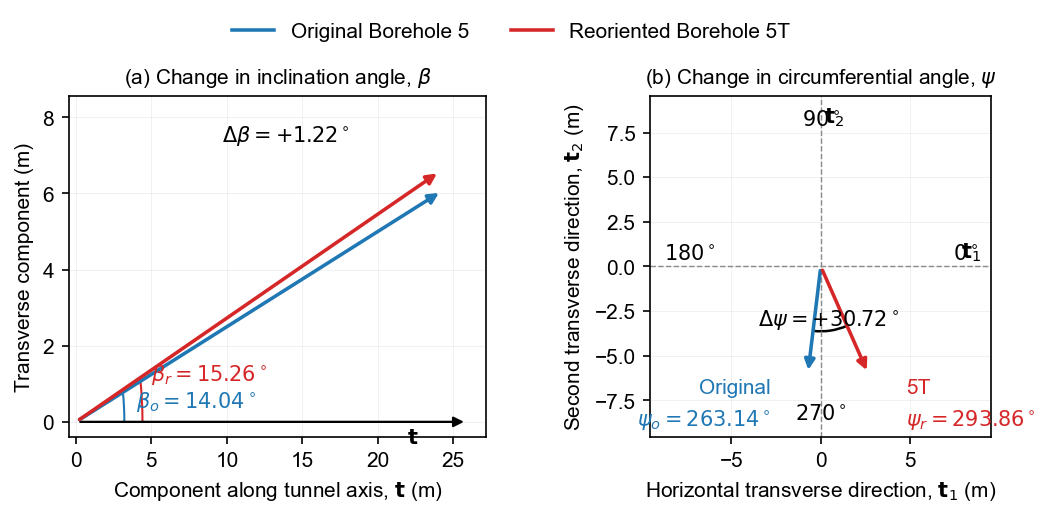

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_11_Borehole_5_reorientation.png
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_11_Borehole_5_reorientation.svg

Borehole 5 geometry
beta_original   = 14.0366°
beta_reoriented = 15.2584°
Delta beta      = +1.2218°
psi_original    = 263.1439°
psi_reoriented  = 293.8591°
Delta psi       = +30.7152°


In [16]:
# ============================================================
# CELL 17 — FIGURE 11:
# BOREHOLE 5 REORIENTATION EXAMPLE
#
# (a) Change in inclination angle beta
# (b) Change in circumferential angle psi
#
# IMPORTANT:
# - Exact ORIGINAL collar coordinates are retained.
# - Reoriented END coordinates are read from
#   "Reorinted_cordinates".
# - Geometry is recalculated directly from coordinates.
#
# Journal-sized figure
# Arial 10 pt throughout
# PNG 600 dpi + SVG
# ============================================================

from matplotlib.patches import Arc
from matplotlib.lines import Line2D


# ============================================================
# 1. FIGURE STYLE
# ============================================================

FIG11_SIZE = (7.2, 3.5)

FONT_SIZE = 10

ORIGINAL_COLOR = "tab:blue"
REORIENTED_COLOR = "tab:red"
REFERENCE_COLOR = "black"


plt.rcParams.update({

    "font.family": "sans-serif",

    "font.sans-serif": [
        "Arial",
        "DejaVu Sans"
    ],

    "font.size": FONT_SIZE,

    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,

    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,

    "legend.fontsize": FONT_SIZE,

    "axes.linewidth": 0.8,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "savefig.dpi": 600,

    "svg.fonttype": "none"
})


# ============================================================
# 2. REBUILD REORIENTATION GEOMETRY
#
# Exact original collar coordinates are taken from 'result'.
# Only reoriented END coordinates are taken from
# "Reorinted_cordinates".
# ============================================================

reorientation_rows = []


for hole in REORIENTED_HOLES:

    # --------------------------------------------------------
    # Original borehole
    # --------------------------------------------------------

    original_row = result.loc[
        result["Hole"].astype(int) == hole
    ].iloc[0]


    p_s = np.array(
        [
            original_row["X_start"],
            original_row["Y_start"],
            original_row["Z_start"]
        ],
        dtype=float
    )


    p_e_original = np.array(
        [
            original_row["X_end"],
            original_row["Y_end"],
            original_row["Z_end"]
        ],
        dtype=float
    )


    # --------------------------------------------------------
    # Reoriented end coordinate
    # --------------------------------------------------------

    reoriented_row = reoriented.loc[
        reoriented["Hole"] == hole
    ].iloc[0]


    p_e_reoriented = np.array(
        [
            reoriented_row["X_end"],
            reoriented_row["Y_end"],
            reoriented_row["Z_end"]
        ],
        dtype=float
    )


    # --------------------------------------------------------
    # Geometry calculation
    # --------------------------------------------------------

    geometry_original = calculate_borehole_geometry(
        p_s,
        p_e_original
    )


    geometry_reoriented = calculate_borehole_geometry(
        p_s,
        p_e_reoriented
    )


    delta_beta = (
        geometry_reoriented["beta_deg"]
        -
        geometry_original["beta_deg"]
    )


    delta_psi = shortest_signed_angle_change(
        geometry_original["psi_deg"],
        geometry_reoriented["psi_deg"]
    )


    # --------------------------------------------------------
    # Store values
    # --------------------------------------------------------

    reorientation_rows.append({

        "Hole": hole,

        "X_start": p_s[0],
        "Y_start": p_s[1],
        "Z_start": p_s[2],

        "X_end_original": p_e_original[0],
        "Y_end_original": p_e_original[1],
        "Z_end_original": p_e_original[2],

        "X_end_reoriented": p_e_reoriented[0],
        "Y_end_reoriented": p_e_reoriented[1],
        "Z_end_reoriented": p_e_reoriented[2],

        "L_original":
            geometry_original["length"],

        "L_reoriented":
            geometry_reoriented["length"],

        "beta_original":
            geometry_original["beta_deg"],

        "beta_reoriented":
            geometry_reoriented["beta_deg"],

        "delta_beta":
            delta_beta,

        "psi_original":
            geometry_original["psi_deg"],

        "psi_reoriented":
            geometry_reoriented["psi_deg"],

        "delta_psi":
            delta_psi,

        "l_original_x":
            geometry_original["direction"][0],

        "l_original_y":
            geometry_original["direction"][1],

        "l_original_z":
            geometry_original["direction"][2],

        "l_reoriented_x":
            geometry_reoriented["direction"][0],

        "l_reoriented_y":
            geometry_reoriented["direction"][1],

        "l_reoriented_z":
            geometry_reoriented["direction"][2]
    })


reorientation_geometry_df = pd.DataFrame(
    reorientation_rows
)


# ============================================================
# 3. BOREHOLE 5 VALUES
# ============================================================

hole5 = reorientation_geometry_df.loc[
    reorientation_geometry_df["Hole"] == 5
].iloc[0]


p_s_5 = np.array([
    hole5["X_start"],
    hole5["Y_start"],
    hole5["Z_start"]
])


p_e_5_original = np.array([
    hole5["X_end_original"],
    hole5["Y_end_original"],
    hole5["Z_end_original"]
])


p_e_5_reoriented = np.array([
    hole5["X_end_reoriented"],
    hole5["Y_end_reoriented"],
    hole5["Z_end_reoriented"]
])


delta_p_original = (
    p_e_5_original
    -
    p_s_5
)


delta_p_reoriented = (
    p_e_5_reoriented
    -
    p_s_5
)


beta_original = float(
    hole5["beta_original"]
)

beta_reoriented = float(
    hole5["beta_reoriented"]
)

delta_beta = float(
    hole5["delta_beta"]
)


psi_original = float(
    hole5["psi_original"]
)

psi_reoriented = float(
    hole5["psi_reoriented"]
)

delta_psi = float(
    hole5["delta_psi"]
)


# ============================================================
# 4. COMPONENTS FOR PANEL (a)
# ============================================================

parallel_original = np.dot(
    delta_p_original,
    t
)


parallel_reoriented = np.dot(
    delta_p_reoriented,
    t
)


transverse_vec_original = (
    delta_p_original
    -
    parallel_original * t
)


transverse_vec_reoriented = (
    delta_p_reoriented
    -
    parallel_reoriented * t
)


transverse_original = np.linalg.norm(
    transverse_vec_original
)


transverse_reoriented = np.linalg.norm(
    transverse_vec_reoriented
)


# ============================================================
# 5. COMPONENTS FOR PANEL (b)
#
# Projection onto tunnel-face basis t1–t2.
# ============================================================

face_original = np.array([
    np.dot(
        delta_p_original,
        t1
    ),
    np.dot(
        delta_p_original,
        t2
    )
])


face_reoriented = np.array([
    np.dot(
        delta_p_reoriented,
        t1
    ),
    np.dot(
        delta_p_reoriented,
        t2
    )
])


# ============================================================
# 6. CREATE FIGURE
# ============================================================

fig, (
    ax1,
    ax2
) = plt.subplots(
    1,
    2,
    figsize=FIG11_SIZE
)


fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.82,
    bottom=0.17,
    wspace=0.30
)


# ============================================================
# PANEL (a) — CHANGE IN beta
# ============================================================

max_parallel = max(
    parallel_original,
    parallel_reoriented
)


# ------------------------------------------------------------
# Tunnel-axis direction
# ------------------------------------------------------------

ax1.annotate(
    "",
    xy=(
        max_parallel * 1.07,
        0
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.1,
        color=REFERENCE_COLOR
    )
)


# ------------------------------------------------------------
# Original borehole direction
# ------------------------------------------------------------

ax1.annotate(
    "",
    xy=(
        parallel_original,
        transverse_original
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.7,
        color=ORIGINAL_COLOR
    )
)


# ------------------------------------------------------------
# Reoriented borehole direction
# ------------------------------------------------------------

ax1.annotate(
    "",
    xy=(
        parallel_reoriented,
        transverse_reoriented
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.7,
        color=REORIENTED_COLOR
    )
)


# ============================================================
# beta ARCS
# ============================================================

beta_radius_original = 3.2

beta_radius_reoriented = 4.4


ax1.add_patch(
    Arc(
        (0, 0),
        2 * beta_radius_original,
        2 * beta_radius_original,
        theta1=0,
        theta2=beta_original,
        linewidth=1.0,
        color=ORIGINAL_COLOR
    )
)


ax1.add_patch(
    Arc(
        (0, 0),
        2 * beta_radius_reoriented,
        2 * beta_radius_reoriented,
        theta1=0,
        theta2=beta_reoriented,
        linewidth=1.0,
        color=REORIENTED_COLOR
    )
)


# ------------------------------------------------------------
# beta labels
# ------------------------------------------------------------

ax1.text(
    4.0,
    0.55,
    rf"$\beta_o={beta_original:.2f}^\circ$",
    fontsize=FONT_SIZE,
    color=ORIGINAL_COLOR,
    ha="left",
    va="center"
)


ax1.text(
    5.0,
    1.25,
    rf"$\beta_r={beta_reoriented:.2f}^\circ$",
    fontsize=FONT_SIZE,
    color=REORIENTED_COLOR,
    ha="left",
    va="center"
)


# ------------------------------------------------------------
# Delta beta
# ------------------------------------------------------------

ax1.text(
    0.52,
    0.92,
    rf"$\Delta\beta={delta_beta:+.2f}^\circ$",
    transform=ax1.transAxes,
    fontsize=FONT_SIZE,
    ha="center",
    va="top"
)


# ------------------------------------------------------------
# Tunnel-axis label
# ------------------------------------------------------------

ax1.text(
    max_parallel * 0.92,
    -0.18,
    r"$\mathbf{t}$",
    fontsize=FONT_SIZE,
    ha="center",
    va="top"
)


# ------------------------------------------------------------
# Panel formatting
# ------------------------------------------------------------

ax1.set_xlabel(
    r"Component along tunnel axis, $\mathbf{t}$ (m)"
)


ax1.set_ylabel(
    "Transverse component (m)"
)


ax1.set_title(
    r"(a) Change in inclination angle, $\beta$"
)


ax1.set_xlim(
    -0.5,
    max_parallel * 1.12
)


ax1.set_ylim(
    -0.4,
    max(
        transverse_original,
        transverse_reoriented
    ) * 1.30
)


ax1.grid(
    True,
    linewidth=0.4,
    alpha=0.20
)


# ============================================================
# PANEL (b) — CHANGE IN psi
# ============================================================

face_limit = (
    max(
        np.linalg.norm(
            face_original
        ),
        np.linalg.norm(
            face_reoriented
        )
    )
    *
    1.45
)


# ------------------------------------------------------------
# Reference axes
# ------------------------------------------------------------

ax2.axhline(
    0,
    color="0.55",
    linestyle="--",
    linewidth=0.7
)


ax2.axvline(
    0,
    color="0.55",
    linestyle="--",
    linewidth=0.7
)


# ------------------------------------------------------------
# Original direction
# ------------------------------------------------------------

ax2.annotate(
    "",
    xy=(
        face_original[0],
        face_original[1]
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.7,
        color=ORIGINAL_COLOR
    )
)


# ------------------------------------------------------------
# Reoriented direction
# ------------------------------------------------------------

ax2.annotate(
    "",
    xy=(
        face_reoriented[0],
        face_reoriented[1]
    ),
    xytext=(
        0,
        0
    ),
    arrowprops=dict(
        arrowstyle="-|>",
        linewidth=1.7,
        color=REORIENTED_COLOR
    )
)


# ============================================================
# Delta psi ARC
# ============================================================

psi_arc_radius = (
    face_limit
    *
    0.38
)


if delta_psi >= 0:

    theta1 = psi_original
    theta2 = (
        psi_original
        +
        delta_psi
    )

else:

    theta1 = psi_reoriented
    theta2 = (
        psi_reoriented
        -
        delta_psi
    )


ax2.add_patch(
    Arc(
        (0, 0),
        2 * psi_arc_radius,
        2 * psi_arc_radius,
        theta1=theta1,
        theta2=theta2,
        linewidth=1.2,
        color="black"
    )
)


# ============================================================
# PANEL (b) LABELS
#
# Labels are deliberately offset from arrow tips to avoid
# overlap in the lower part of the panel.
# ============================================================

# Original direction label
ax2.annotate(
    "Original",
    xy=(
        face_original[0],
        face_original[1]
    ),
    xytext=(
        -18,
        -2
    ),
    textcoords="offset points",
    fontsize=FONT_SIZE,
    color=ORIGINAL_COLOR,
    ha="right",
    va="top"
)


# Original psi
ax2.annotate(
    rf"$\psi_o={psi_original:.2f}^\circ$",
    xy=(
        face_original[0],
        face_original[1]
    ),
    xytext=(
        -18,
        -16
    ),
    textcoords="offset points",
    fontsize=FONT_SIZE,
    color=ORIGINAL_COLOR,
    ha="right",
    va="top"
)


# Reoriented direction label
ax2.annotate(
    "5T",
    xy=(
        face_reoriented[0],
        face_reoriented[1]
    ),
    xytext=(
        18,
        -2
    ),
    textcoords="offset points",
    fontsize=FONT_SIZE,
    color=REORIENTED_COLOR,
    ha="left",
    va="top"
)


# Reoriented psi
ax2.annotate(
    rf"$\psi_r={psi_reoriented:.2f}^\circ$",
    xy=(
        face_reoriented[0],
        face_reoriented[1]
    ),
    xytext=(
        18,
        -16
    ),
    textcoords="offset points",
    fontsize=FONT_SIZE,
    color=REORIENTED_COLOR,
    ha="left",
    va="top"
)


# ------------------------------------------------------------
# Delta psi label — positioned inside the angular sector
# ------------------------------------------------------------

psi_mid = np.radians(
    psi_original
    +
    delta_psi / 2.0
)


delta_psi_x = (
    psi_arc_radius
    *
    0.82
    *
    np.cos(
        psi_mid
    )
)


delta_psi_y = (
    psi_arc_radius
    *
    0.82
    *
    np.sin(
        psi_mid
    )
)


ax2.text(
    delta_psi_x,
    delta_psi_y,
    rf"$\Delta\psi={delta_psi:+.2f}^\circ$",
    fontsize=FONT_SIZE,
    ha="center",
    va="center"
)


# ============================================================
# CIRCUMFERENTIAL REFERENCE LABELS
#
# Same convention as Fig. 7:
# 0°   = +t1
# 90°  = +t2
# 180° = -t1
# 270° = -t2
# ============================================================

ax2.text(
    0.96,
    0.51,
    r"$0^\circ$",
    transform=ax2.transAxes,
    fontsize=FONT_SIZE,
    ha="right",
    va="bottom"
)


ax2.text(
    0.50,
    0.96,
    r"$90^\circ$",
    transform=ax2.transAxes,
    fontsize=FONT_SIZE,
    ha="center",
    va="top"
)


ax2.text(
    0.04,
    0.51,
    r"$180^\circ$",
    transform=ax2.transAxes,
    fontsize=FONT_SIZE,
    ha="left",
    va="bottom"
)


ax2.text(
    0.50,
    0.04,
    r"$270^\circ$",
    transform=ax2.transAxes,
    fontsize=FONT_SIZE,
    ha="center",
    va="bottom"
)


# ------------------------------------------------------------
# t1 and t2 labels
# ------------------------------------------------------------

ax2.text(
    face_limit * 0.94,
    0.20,
    r"$\mathbf{t}_1$",
    fontsize=FONT_SIZE,
    ha="right",
    va="bottom"
)


ax2.text(
    0.20,
    face_limit * 0.94,
    r"$\mathbf{t}_2$",
    fontsize=FONT_SIZE,
    ha="left",
    va="top"
)


# ------------------------------------------------------------
# Panel formatting
# ------------------------------------------------------------

ax2.set_xlim(
    -face_limit,
    face_limit
)


ax2.set_ylim(
    -face_limit,
    face_limit
)


ax2.set_aspect(
    "equal",
    adjustable="box"
)


ax2.set_xlabel(
    r"Horizontal transverse direction, $\mathbf{t}_1$ (m)"
)


ax2.set_ylabel(
    r"Second transverse direction, $\mathbf{t}_2$ (m)"
)


ax2.set_title(
    r"(b) Change in circumferential angle, $\psi$"
)


ax2.grid(
    True,
    linewidth=0.4,
    alpha=0.20
)


# ============================================================
# 7. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=ORIGINAL_COLOR,
        linewidth=1.7,
        label="Original Borehole 5"
    ),

    Line2D(
        [0],
        [0],
        color=REORIENTED_COLOR,
        linewidth=1.7,
        label="Reoriented Borehole 5T"
    )
]


fig.legend(
    handles=legend_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.50,
        0.995
    ),
    ncol=2,
    frameon=False,
    fontsize=FONT_SIZE
)


# ============================================================
# 8. SAVE FIGURE — PNG + SVG
# ============================================================

FIG11_PNG = (
    figure_dir
    /
    "Figure_11_Borehole_5_reorientation.png"
)


FIG11_SVG = (
    figure_dir
    /
    "Figure_11_Borehole_5_reorientation.svg"
)


fig.savefig(
    FIG11_PNG,
    dpi=600,
    bbox_inches="tight",
    pad_inches=0.10
)


fig.savefig(
    FIG11_SVG,
    bbox_inches="tight",
    pad_inches=0.10
)


plt.show()


# ============================================================
# 9. PRINT FINAL VALUES
# ============================================================

print("Saved:")
print(FIG11_PNG)
print(FIG11_SVG)


print("\nBorehole 5 geometry")
print("=" * 60)


print(
    f"beta_original   = "
    f"{beta_original:.4f}°"
)


print(
    f"beta_reoriented = "
    f"{beta_reoriented:.4f}°"
)


print(
    f"Delta beta      = "
    f"{delta_beta:+.4f}°"
)


print(
    f"psi_original    = "
    f"{psi_original:.4f}°"
)


print(
    f"psi_reoriented  = "
    f"{psi_reoriented:.4f}°"
)


print(
    f"Delta psi       = "
    f"{delta_psi:+.4f}°"
)

# Fig. 12: complete original and reoriented geometry

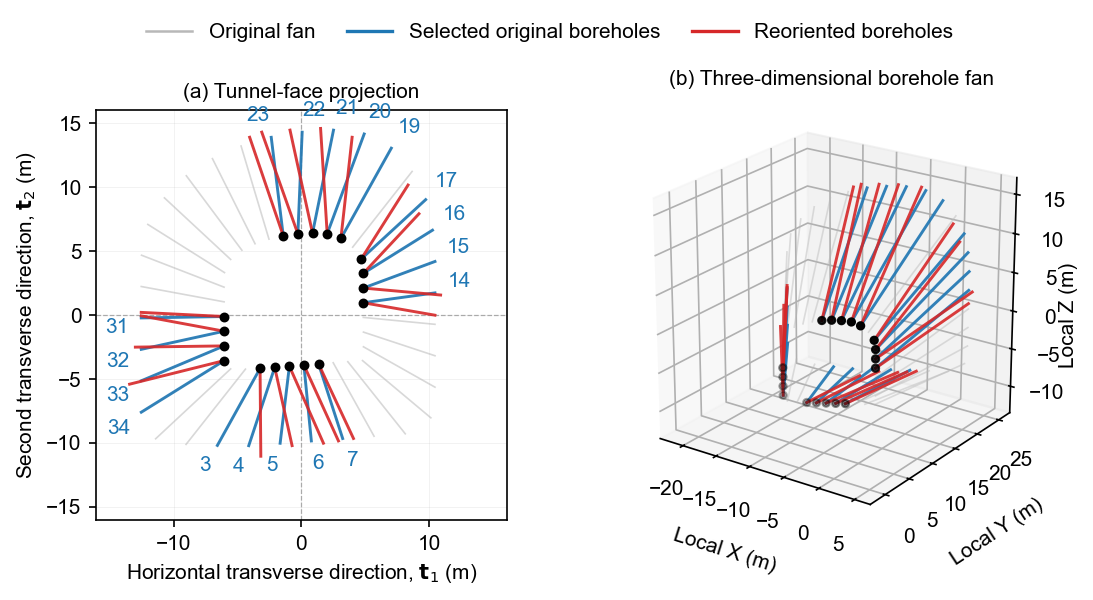

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_12_original_reoriented_borehole_geometry.png
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_12_original_reoriented_borehole_geometry.svg

Selected original boreholes:
[3, 4, 5, 6, 7, 14, 15, 16, 17, 19, 20, 21, 22, 23, 31, 32, 33, 34]

Number of selected reoriented boreholes: 18
Original collars retained exactly: True


In [17]:
# ============================================================
# CELL 18 — FIGURE 12:
# ORIGINAL AND REORIENTED BOREHOLE GEOMETRY
#
# (a) Tunnel-face projection
# (b) Three-dimensional borehole fan
#
# Complete original fan = light grey context
# Selected original boreholes = blue
# Reoriented boreholes = red
#
# Selected ORIGINAL borehole numbers are labelled in panel (a).
#
# Exact original collars are retained.
#
# Journal-sized figure
# Arial 10 pt throughout
# PNG 600 dpi + SVG
# ============================================================

from matplotlib.lines import Line2D


# ============================================================
# 1. FIGURE STYLE
# ============================================================

FIG12_SIZE = (
    7.2,
    4.1
)

FONT_SIZE = 10


CONTEXT_COLOR = "0.72"
ORIGINAL_COLOR = "tab:blue"
REORIENTED_COLOR = "tab:red"

CONTEXT_WIDTH = 0.8
SELECTED_WIDTH = 1.4


plt.rcParams.update({

    "font.family": "sans-serif",

    "font.sans-serif": [
        "Arial",
        "DejaVu Sans"
    ],

    "font.size": FONT_SIZE,

    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,

    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,

    "legend.fontsize": FONT_SIZE,

    "axes.linewidth": 0.8,

    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,

    "savefig.dpi": 600,

    # Keep SVG text editable
    "svg.fonttype": "none"
})


# ============================================================
# 2. COMPLETE ORIGINAL FAN
# ============================================================

S_all = result[
    [
        "X_start",
        "Y_start",
        "Z_start"
    ]
].to_numpy(dtype=float)


E_all = result[
    [
        "X_end",
        "Y_end",
        "Z_end"
    ]
].to_numpy(dtype=float)


# ============================================================
# 3. SELECTED ORIGINAL + REORIENTED GEOMETRY
# ============================================================

S_selected = reorientation_geometry_df[
    [
        "X_start",
        "Y_start",
        "Z_start"
    ]
].to_numpy(dtype=float)


E_selected_original = reorientation_geometry_df[
    [
        "X_end_original",
        "Y_end_original",
        "Z_end_original"
    ]
].to_numpy(dtype=float)


E_selected_reoriented = reorientation_geometry_df[
    [
        "X_end_reoriented",
        "Y_end_reoriented",
        "Z_end_reoriented"
    ]
].to_numpy(dtype=float)


selected_holes = (
    reorientation_geometry_df["Hole"]
    .astype(int)
    .to_numpy()
)


# ============================================================
# 4. TUNNEL-FACE PROJECTION
# ============================================================

S_all_face = np.column_stack([
    S_all @ t1,
    S_all @ t2
])


E_all_face = np.column_stack([
    E_all @ t1,
    E_all @ t2
])


S_selected_face = np.column_stack([
    S_selected @ t1,
    S_selected @ t2
])


E_original_face = np.column_stack([
    E_selected_original @ t1,
    E_selected_original @ t2
])


E_reoriented_face = np.column_stack([
    E_selected_reoriented @ t1,
    E_selected_reoriented @ t2
])


# ============================================================
# 5. CREATE FIGURE
# ============================================================

fig = plt.figure(
    figsize=FIG12_SIZE
)


gs = fig.add_gridspec(

    1,
    2,

    width_ratios=[
        1.0,
        1.05
    ],

    wspace=0.26
)


ax1 = fig.add_subplot(
    gs[0, 0]
)


ax2 = fig.add_subplot(
    gs[0, 1],
    projection="3d"
)


fig.subplots_adjust(

    left=0.08,

    right=0.96,

    top=0.84,

    bottom=0.14
)


# ============================================================
# PANEL (a) — TUNNEL-FACE PROJECTION
# ============================================================

# ------------------------------------------------------------
# Complete original fan in grey
# ------------------------------------------------------------

for start, end in zip(
    S_all_face,
    E_all_face
):

    ax1.plot(

        [start[0], end[0]],

        [start[1], end[1]],

        color=CONTEXT_COLOR,

        linewidth=CONTEXT_WIDTH,

        alpha=0.55,

        zorder=1
    )


# ------------------------------------------------------------
# Selected original boreholes
# ------------------------------------------------------------

for start, end in zip(
    S_selected_face,
    E_original_face
):

    ax1.plot(

        [start[0], end[0]],

        [start[1], end[1]],

        color=ORIGINAL_COLOR,

        linewidth=SELECTED_WIDTH,

        alpha=0.90,

        zorder=3
    )


# ------------------------------------------------------------
# Reoriented boreholes
# ------------------------------------------------------------

for start, end in zip(
    S_selected_face,
    E_reoriented_face
):

    ax1.plot(

        [start[0], end[0]],

        [start[1], end[1]],

        color=REORIENTED_COLOR,

        linewidth=SELECTED_WIDTH,

        alpha=0.90,

        zorder=4
    )


# ------------------------------------------------------------
# Collar positions
# ------------------------------------------------------------

ax1.scatter(

    S_selected_face[:, 0],

    S_selected_face[:, 1],

    s=14,

    color="black",

    zorder=5
)


# ============================================================
# LABEL SELECTED ORIGINAL BOREHOLES
#
# Original borehole numbers are placed beside the BLUE
# original endpoints.
#
# Reoriented T labels are intentionally omitted to avoid
# excessive crowding.
# ============================================================

for hole, end in zip(
    selected_holes,
    E_original_face
):

    x_end = end[0]
    y_end = end[1]


    # --------------------------------------------------------
    # Offset labels outward from the fan
    # --------------------------------------------------------

    radial_length = np.hypot(
        x_end,
        y_end
    )


    if radial_length > 0:

        offset_x = (
            6.0
            *
            x_end
            /
            radial_length
        )

        offset_y = (
            6.0
            *
            y_end
            /
            radial_length
        )

    else:

        offset_x = 5.0
        offset_y = 5.0


    # --------------------------------------------------------
    # Alignment according to location
    # --------------------------------------------------------

    if x_end >= 0:

        ha = "left"

    else:

        ha = "right"


    if y_end >= 0:

        va = "bottom"

    else:

        va = "top"


    # --------------------------------------------------------
    # Borehole number
    # --------------------------------------------------------

    ax1.annotate(

        str(hole),

        xy=(
            x_end,
            y_end
        ),

        xytext=(
            offset_x,
            offset_y
        ),

        textcoords="offset points",

        fontsize=FONT_SIZE,

        color=ORIGINAL_COLOR,

        ha=ha,

        va=va,

        zorder=7
    )


# ------------------------------------------------------------
# Reference axes
# ------------------------------------------------------------

ax1.axhline(

    0,

    linestyle="--",

    linewidth=0.6,

    color="0.55",

    alpha=0.7
)


ax1.axvline(

    0,

    linestyle="--",

    linewidth=0.6,

    color="0.55",

    alpha=0.7
)


# ============================================================
# PANEL (a) LIMITS
# ============================================================

all_face_points = np.vstack([

    S_all_face,

    E_all_face,

    E_reoriented_face
])


face_limit = (

    np.max(

        np.abs(
            all_face_points
        )
    )

    *
    1.10
)


ax1.set_xlim(
    -face_limit,
    face_limit
)


ax1.set_ylim(
    -face_limit,
    face_limit
)


ax1.set_aspect(
    "equal",
    adjustable="box"
)


ax1.set_xlabel(
    r"Horizontal transverse direction, $\mathbf{t}_1$ (m)"
)


ax1.set_ylabel(
    r"Second transverse direction, $\mathbf{t}_2$ (m)"
)


ax1.set_title(
    "(a) Tunnel-face projection"
)


ax1.grid(

    True,

    linewidth=0.4,

    alpha=0.18
)


# ============================================================
# PANEL (b) — THREE-DIMENSIONAL BOREHOLE FAN
# ============================================================

# ------------------------------------------------------------
# Complete original fan
# ------------------------------------------------------------

for start, end in zip(
    S_all,
    E_all
):

    ax2.plot(

        [start[0], end[0]],

        [start[1], end[1]],

        [start[2], end[2]],

        color=CONTEXT_COLOR,

        linewidth=CONTEXT_WIDTH,

        alpha=0.45
    )


# ------------------------------------------------------------
# Selected original boreholes
# ------------------------------------------------------------

for start, end in zip(
    S_selected,
    E_selected_original
):

    ax2.plot(

        [start[0], end[0]],

        [start[1], end[1]],

        [start[2], end[2]],

        color=ORIGINAL_COLOR,

        linewidth=SELECTED_WIDTH,

        alpha=0.90
    )


# ------------------------------------------------------------
# Reoriented boreholes
# ------------------------------------------------------------

for start, end in zip(
    S_selected,
    E_selected_reoriented
):

    ax2.plot(

        [start[0], end[0]],

        [start[1], end[1]],

        [start[2], end[2]],

        color=REORIENTED_COLOR,

        linewidth=SELECTED_WIDTH,

        alpha=0.90
    )


# ------------------------------------------------------------
# Collar positions
# ------------------------------------------------------------

ax2.scatter(

    S_selected[:, 0],

    S_selected[:, 1],

    S_selected[:, 2],

    s=12,

    color="black",

    zorder=5
)


# ============================================================
# 6. 3D AXIS SCALING
# ============================================================

all_xyz = np.vstack([

    S_all,

    E_all,

    E_selected_reoriented
])


mins = all_xyz.min(
    axis=0
)


maxs = all_xyz.max(
    axis=0
)


mid = (
    mins
    +
    maxs
) / 2.0


max_range = np.max(
    maxs
    -
    mins
)


half_range = (
    max_range
    *
    0.53
)


ax2.set_xlim(

    mid[0] - half_range,

    mid[0] + half_range
)


ax2.set_ylim(

    mid[1] - half_range,

    mid[1] + half_range
)


ax2.set_zlim(

    mid[2] - half_range,

    mid[2] + half_range
)


ax2.set_box_aspect(
    (1, 1, 1)
)


ax2.view_init(

    elev=22,

    azim=-55
)


# ============================================================
# 7. 3D AXIS LABELS
# ============================================================

ax2.set_xlabel(

    "Local X (m)",

    labelpad=5
)


ax2.set_ylabel(

    "Local Y (m)",

    labelpad=6
)


# ------------------------------------------------------------
# Reliable Z label for saved 3D figure
# ------------------------------------------------------------

ax2.text2D(

    1.03,
    0.50,

    "Local Z (m)",

    transform=ax2.transAxes,

    rotation=90,

    fontsize=FONT_SIZE,

    ha="left",

    va="center"
)


ax2.set_title(

    "(b) Three-dimensional borehole fan",

    pad=7
)


# ============================================================
# 8. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(

        [0],
        [0],

        color=CONTEXT_COLOR,

        linewidth=1.2,

        label="Original fan"
    ),

    Line2D(

        [0],
        [0],

        color=ORIGINAL_COLOR,

        linewidth=1.6,

        label="Selected original boreholes"
    ),

    Line2D(

        [0],
        [0],

        color=REORIENTED_COLOR,

        linewidth=1.6,

        label="Reoriented boreholes"
    )
]


fig.legend(

    handles=legend_handles,

    loc="upper center",

    bbox_to_anchor=(
        0.50,
        0.995
    ),

    ncol=3,

    frameon=False,

    fontsize=FONT_SIZE,

    columnspacing=1.5,

    handlelength=2.2
)


# ============================================================
# 9. SAVE FIGURE — PNG + SVG
# ============================================================

FIG12_PNG = (

    figure_dir

    /

    "Figure_12_original_reoriented_borehole_geometry.png"
)


FIG12_SVG = (

    figure_dir

    /

    "Figure_12_original_reoriented_borehole_geometry.svg"
)


fig.savefig(

    FIG12_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.12
)


fig.savefig(

    FIG12_SVG,

    bbox_inches="tight",

    pad_inches=0.12
)


plt.show()


# ============================================================
# 10. OUTPUT INFORMATION
# ============================================================

print("Saved:")

print(
    FIG12_PNG
)

print(
    FIG12_SVG
)


print(
    "\nSelected original boreholes:"
)

print(
    selected_holes.tolist()
)


print(
    "\nNumber of selected reoriented boreholes:",
    len(
        reorientation_geometry_df
    )
)


print(
    "Original collars retained exactly:",
    True
)

# Calculate hit-rate changes after reorientation

In [18]:
# ============================================================
# CELL 19 — HIT RATE OF ORIGINAL AND REORIENTED BOREHOLES
#
# Representative joint set orientations:
#
# SG-1 = 155° / 50°
# SG-2 =  80° / 90°
# SG-3 = 305° / 55°
#
# Hit rate:
#
# h_ij = | l_i · n_j |
#
# Change after reorientation:
#
# Delta h_ij =
# h_ij,reoriented - h_ij,original
#
# Unit for Delta h = percentage points
# ============================================================


# ============================================================
# 1. REPRESENTATIVE JOINT SET ORIENTATIONS
# ============================================================

REORIENTATION_JOINT_SETS = {

    "SG-1": {
        "strike": 165.0,
        "dip": 45.0
    },

    "SG-2": {
        "strike": 80.0,
        "dip": 90.0
    },

    "SG-3": {
        "strike": 305.0,
        "dip": 55.0
    }
}


# ============================================================
# 2. CALCULATE JOINT PLANE NORMALS
# ============================================================

reorientation_normals = {}


for joint_set, parameters in (
    REORIENTATION_JOINT_SETS.items()
):

    reorientation_normals[
        joint_set
    ] = joint_normal_rhr(

        parameters["strike"],

        parameters["dip"]
    )


    print(
        joint_set,
        np.round(
            reorientation_normals[
                joint_set
            ],
            6
        )
    )


# ============================================================
# 3. ORIGINAL AND REORIENTED BOREHOLE DIRECTION VECTORS
# ============================================================

l_original = reorientation_geometry_df[
    [
        "l_original_x",
        "l_original_y",
        "l_original_z"
    ]
].to_numpy(dtype=float)


l_reoriented = reorientation_geometry_df[
    [
        "l_reoriented_x",
        "l_reoriented_y",
        "l_reoriented_z"
    ]
].to_numpy(dtype=float)


# Check unit-vector lengths
assert np.allclose(
    np.linalg.norm(
        l_original,
        axis=1
    ),
    1.0,
    atol=1e-8
)


assert np.allclose(
    np.linalg.norm(
        l_reoriented,
        axis=1
    ),
    1.0,
    atol=1e-8
)


# ============================================================
# 4. CREATE RESULT TABLE
# ============================================================

reorientation_hit_rate = pd.DataFrame({

    "Hole":
        reorientation_geometry_df[
            "Hole"
        ].astype(int),

    "Reoriented hole":
        reorientation_geometry_df[
            "Hole"
        ].astype(int).astype(str)
        +
        "T"
})


# ============================================================
# 5. CALCULATE HIT RATE FOR EACH JOINT SET
# ============================================================

for joint_set in [
    "SG-1",
    "SG-2",
    "SG-3"
]:

    n_joint = reorientation_normals[
        joint_set
    ]


    # --------------------------------------------------------
    # Original hit rate
    # --------------------------------------------------------

    hit_original = (

        np.abs(
            l_original
            @
            n_joint
        )

        *
        100.0
    )


    # --------------------------------------------------------
    # Reoriented hit rate
    # --------------------------------------------------------

    hit_reoriented = (

        np.abs(
            l_reoriented
            @
            n_joint
        )

        *
        100.0
    )


    # --------------------------------------------------------
    # Change in percentage points
    # --------------------------------------------------------

    delta_hit = (

        hit_reoriented
        -
        hit_original
    )


    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    reorientation_hit_rate[
        f"{joint_set} original (%)"
    ] = hit_original


    reorientation_hit_rate[
        f"{joint_set} reoriented (%)"
    ] = hit_reoriented


    reorientation_hit_rate[
        f"{joint_set} change (pp)"
    ] = delta_hit


# ============================================================
# 6. SUMMARY STATISTICS
# ============================================================

summary_rows = []


for joint_set in [
    "SG-1",
    "SG-2",
    "SG-3"
]:

    delta = reorientation_hit_rate[
        f"{joint_set} change (pp)"
    ].to_numpy(dtype=float)


    max_idx = np.argmax(
        delta
    )


    min_idx = np.argmin(
        delta
    )


    summary_rows.append({

        "Joint set":
            joint_set,

        "Mean change (pp)":
            np.mean(
                delta
            ),

        "Median change (pp)":
            np.median(
                delta
            ),

        "Minimum change (pp)":
            np.min(
                delta
            ),

        "Hole with minimum change":
            int(
                reorientation_hit_rate.iloc[
                    min_idx
                ]["Hole"]
            ),

        "Maximum change (pp)":
            np.max(
                delta
            ),

        "Hole with maximum change":
            int(
                reorientation_hit_rate.iloc[
                    max_idx
                ]["Hole"]
            ),

        "Number increased":
            int(
                np.sum(
                    delta > 0
                )
            ),

        "Number decreased":
            int(
                np.sum(
                    delta < 0
                )
            )
    })


reorientation_hit_rate_summary = (
    pd.DataFrame(
        summary_rows
    )
)


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

print(
    "\nREORIENTATION HIT-RATE RESULTS"
)

print(
    "=" * 70
)


display(
    reorientation_hit_rate.round(
        2
    )
)


print(
    "\nSUMMARY"
)

print(
    "=" * 70
)


display(
    reorientation_hit_rate_summary.round(
        2
    )
)


# ============================================================
# 8. PRINT MANUSCRIPT VALUES
# ============================================================

for _, row in (
    reorientation_hit_rate_summary.iterrows()
):

    print(
        f"\n{row['Joint set']}"
    )

    print(
        f"Mean change = "
        f"{row['Mean change (pp)']:+.2f} pp"
    )

    print(
        f"Median change = "
        f"{row['Median change (pp)']:+.2f} pp"
    )

    print(
        f"Range = "
        f"{row['Minimum change (pp)']:+.2f} "
        f"to "
        f"{row['Maximum change (pp)']:+.2f} pp"
    )

    print(
        f"Increased = "
        f"{int(row['Number increased'])} boreholes"
    )

    print(
        f"Decreased = "
        f"{int(row['Number decreased'])} boreholes"
    )


# ============================================================
# 9. SAVE CALCULATED VALUES
# ============================================================

REORIENTATION_HIT_RATE_CSV = (
    WORK_DIR
    /
    "Table_reorientation_hit_rate_results.csv"
)


REORIENTATION_SUMMARY_CSV = (
    WORK_DIR
    /
    "Table_reorientation_hit_rate_summary.csv"
)


reorientation_hit_rate.to_csv(

    REORIENTATION_HIT_RATE_CSV,

    index=False,

    encoding="utf-8-sig"
)


reorientation_hit_rate_summary.to_csv(

    REORIENTATION_SUMMARY_CSV,

    index=False,

    encoding="utf-8-sig"
)


print(
    "\nSaved:"
)

print(
    REORIENTATION_HIT_RATE_CSV
)

print(
    REORIENTATION_SUMMARY_CSV
)

SG-1 [-0.683013 -0.183013  0.707107]
SG-2 [ 0.173648 -0.984808  0.      ]
SG-3 [0.469846 0.67101  0.573576]

REORIENTATION HIT-RATE RESULTS


,Hole,Reoriented hole,SG-1 original (%),SG-1 reoriented (%),SG-1 change (pp),SG-2 original (%),SG-2 reoriented (%),SG-2 change (pp),SG-3 original (%),SG-3 reoriented (%),SG-3 change (pp)
0,3,3T,1.65,13.53,11.88,92.42,94.78,2.36,22.56,29.70,7.14
1,4,4T,5.60,15.10,9.50,93.76,96.30,2.53,25.97,35.13,9.16
2,5,5T,9.01,18.57,9.56,95.04,96.86,1.82,29.83,38.67,8.84
3,6,6T,12.43,18.42,5.99,96.05,96.96,0.91,33.58,39.01,5.43
4,7,7T,15.78,18.16,2.38,96.80,97.07,0.27,37.27,39.38,2.12
5,14,14T,7.59,12.52,4.93,99.82,99.79,-0.03,62.55,58.54,-4.01
6,15,15T,3.88,12.51,8.63,99.53,99.74,0.22,65.35,60.50,-4.86
7,16,16T,0.32,6.87,6.56,99.00,98.28,-0.73,67.54,67.64,0.10
8,17,17T,4.87,11.89,7.02,98.26,97.32,-0.94,69.12,68.06,-1.06
9,19,19T,14.49,24.13,9.64,96.13,94.76,-1.37,70.68,63.73,-6.96



SUMMARY


,Joint set,Mean change (pp),Median change (pp),Minimum change (pp),Hole with minimum change,Maximum change (pp),Hole with maximum change,Number increased,Number decreased
0,SG-1,7.51,8.61,1.22,31,11.88,3,18,0
1,SG-2,-0.26,-0.12,-2.73,22,2.53,4,7,11
2,SG-3,0.01,0.55,-8.90,21,9.16,4,10,8



SG-1
Mean change = +7.51 pp
Median change = +8.61 pp
Range = +1.22 to +11.88 pp
Increased = 18 boreholes
Decreased = 0 boreholes

SG-2
Mean change = -0.26 pp
Median change = -0.12 pp
Range = -2.73 to +2.53 pp
Increased = 7 boreholes
Decreased = 11 boreholes

SG-3
Mean change = +0.01 pp
Median change = +0.55 pp
Range = -8.90 to +9.16 pp
Increased = 10 boreholes
Decreased = 8 boreholes

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Table_reorientation_hit_rate_results.csv
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Table_reorientation_hit_rate_summary.csv


# FIg 13

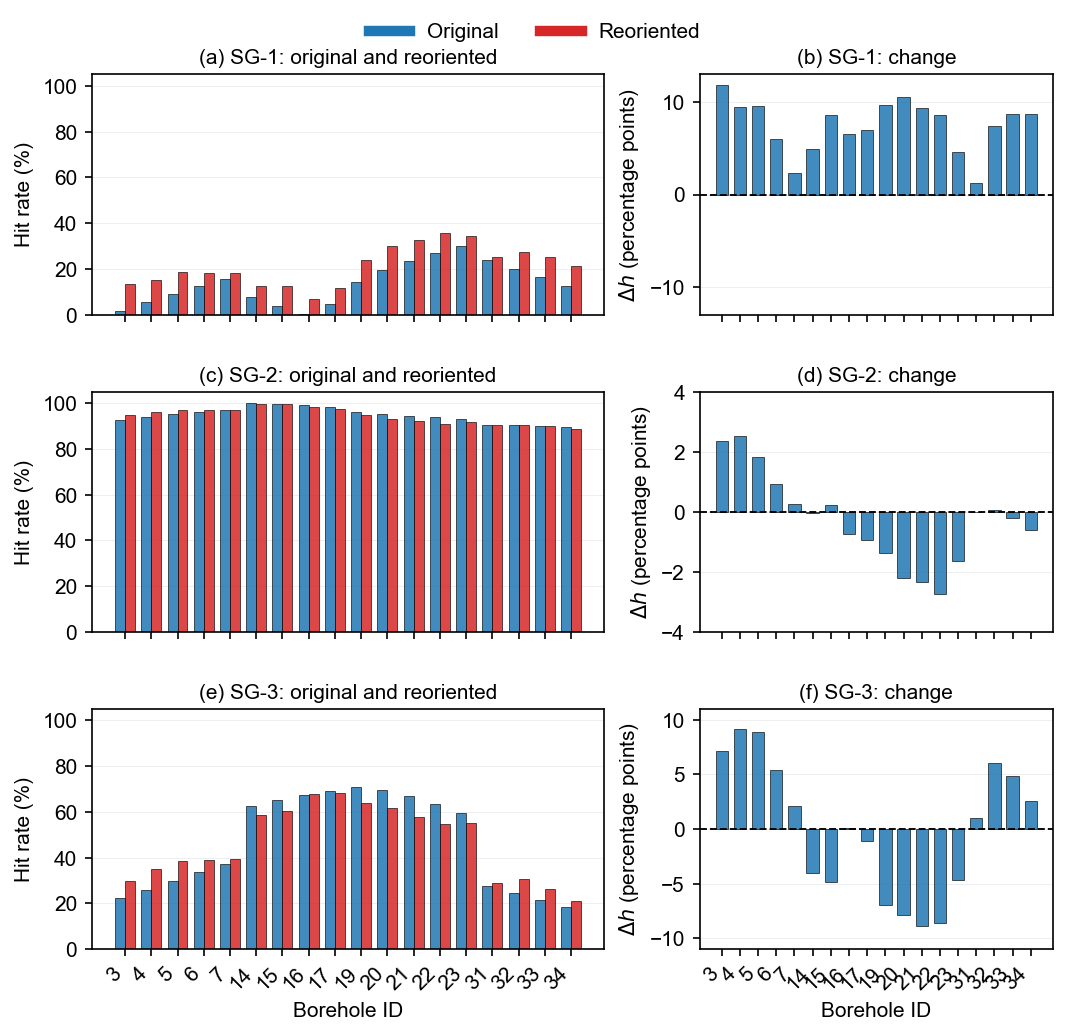

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_13_reorientation_hit_rate_effect.png
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_13_reorientation_hit_rate_effect.svg


In [19]:
# ============================================================
# CELL 20 — FIGURE 13:
# EFFECT OF BOREHOLE REORIENTATION ON HIT RATE
#
# Row 1:
# (a) SG-1 original vs reoriented
# (b) SG-1 change
#
# Row 2:
# (c) SG-2 original vs reoriented
# (d) SG-2 change
#
# Row 3:
# (e) SG-3 original vs reoriented
# (f) SG-3 change
#
# Journal-sized figure
# Arial 10 pt throughout
# PNG 600 dpi + SVG
# ============================================================


# ============================================================
# 1. FIGURE STYLE
# ============================================================

FIG13_SIZE = (
    7.2,
    7.2
)

FONT_SIZE = 10


ORIGINAL_COLOR = "tab:blue"
REORIENTED_COLOR = "tab:red"


plt.rcParams.update({

    "font.family":
        "sans-serif",

    "font.sans-serif": [
        "Arial",
        "DejaVu Sans"
    ],

    "font.size":
        FONT_SIZE,

    "axes.labelsize":
        FONT_SIZE,

    "axes.titlesize":
        FONT_SIZE,

    "xtick.labelsize":
        FONT_SIZE,

    "ytick.labelsize":
        FONT_SIZE,

    "legend.fontsize":
        FONT_SIZE,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "savefig.dpi":
        600,

    "svg.fonttype":
        "none"
})


# ============================================================
# 2. DATA
# ============================================================

selected_holes = (
    reorientation_hit_rate[
        "Hole"
    ]
    .astype(int)
    .to_numpy()
)


x = np.arange(
    len(
        selected_holes
    )
)


bar_width = 0.38


# ============================================================
# 3. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(

    3,
    2,

    figsize=FIG13_SIZE,

    gridspec_kw={
        "width_ratios": [
            1.45,
            1.0
        ],

        "hspace": 0.32,

        "wspace": 0.22
    }
)


fig.subplots_adjust(

    left=0.09,

    right=0.98,

    top=0.93,

    bottom=0.12
)


# ============================================================
# 4. JOINT-SET SETTINGS
# ============================================================

joint_set_rows = [

    (
        "SG-1",
        "(a)",
        "(b)"
    ),

    (
        "SG-2",
        "(c)",
        "(d)"
    ),

    (
        "SG-3",
        "(e)",
        "(f)"
    )
]


# ============================================================
# 5. PLOT EACH JOINT SET
# ============================================================

for row_index, (
    joint_set,
    left_label,
    right_label
) in enumerate(
    joint_set_rows
):

    ax_compare = axes[
        row_index,
        0
    ]

    ax_change = axes[
        row_index,
        1
    ]


    original_values = (
        reorientation_hit_rate[
            f"{joint_set} original (%)"
        ]
        .to_numpy(
            dtype=float
        )
    )


    reoriented_values = (
        reorientation_hit_rate[
            f"{joint_set} reoriented (%)"
        ]
        .to_numpy(
            dtype=float
        )
    )


    change_values = (
        reorientation_hit_rate[
            f"{joint_set} change (pp)"
        ]
        .to_numpy(
            dtype=float
        )
    )


    # ========================================================
    # LEFT PANEL — ORIGINAL VS REORIENTED
    # ========================================================

    ax_compare.bar(

        x - bar_width / 2,

        original_values,

        width=bar_width,

        color=ORIGINAL_COLOR,

        edgecolor="black",

        linewidth=0.35,

        alpha=0.85,

        label="Original"
    )


    ax_compare.bar(

        x + bar_width / 2,

        reoriented_values,

        width=bar_width,

        color=REORIENTED_COLOR,

        edgecolor="black",

        linewidth=0.35,

        alpha=0.85,

        label="Reoriented"
    )


    ax_compare.set_ylim(
        0,
        105
    )


    ax_compare.set_yticks(
        np.arange(
            0,
            101,
            20
        )
    )


    ax_compare.set_ylabel(
        "Hit rate (%)",
        fontsize=FONT_SIZE
    )


    ax_compare.set_title(

        f"{left_label} {joint_set}: "
        "original and reoriented",

        fontsize=FONT_SIZE,

        pad=5
    )


    ax_compare.grid(

        True,

        axis="y",

        linewidth=0.4,

        alpha=0.25
    )


    ax_compare.set_axisbelow(
        True
    )


    # ========================================================
    # RIGHT PANEL — CHANGE
    # ========================================================

    ax_change.bar(

        x,

        change_values,

        width=0.68,

        edgecolor="black",

        linewidth=0.35,

        alpha=0.85
    )


    ax_change.axhline(

        0,

        color="black",

        linestyle="--",

        linewidth=0.9
    )


    # --------------------------------------------------------
    # Symmetric y-limit for change panel
    # --------------------------------------------------------

    change_limit = np.ceil(

        np.max(
            np.abs(
                change_values
            )
        )

        +
        1.0
    )


    change_limit = max(
        change_limit,
        2.0
    )


    ax_change.set_ylim(

        -change_limit,

        change_limit
    )


    ax_change.set_ylabel(

        r"$\Delta h$ "
        "(percentage points)",

        fontsize=FONT_SIZE
    )


    ax_change.set_title(

        f"{right_label} {joint_set}: "
        "change",

        fontsize=FONT_SIZE,

        pad=5
    )


    ax_change.grid(

        True,

        axis="y",

        linewidth=0.4,

        alpha=0.25
    )


    ax_change.set_axisbelow(
        True
    )


    # ========================================================
    # X AXES
    # ========================================================

    ax_compare.set_xticks(
        x
    )


    ax_change.set_xticks(
        x
    )


    if row_index == 2:

        ax_compare.set_xticklabels(

            selected_holes,

            rotation=45,

            ha="right",

            fontsize=FONT_SIZE
        )


        ax_change.set_xticklabels(

            selected_holes,

            rotation=45,

            ha="right",

            fontsize=FONT_SIZE
        )


        ax_compare.set_xlabel(
            "Borehole ID"
        )


        ax_change.set_xlabel(
            "Borehole ID"
        )

    else:

        ax_compare.set_xticklabels(
            []
        )

        ax_change.set_xticklabels(
            []
        )


    # ========================================================
    # AXIS STYLE
    # ========================================================

    for ax in [
        ax_compare,
        ax_change
    ]:

        ax.tick_params(
            axis="both",
            labelsize=FONT_SIZE
        )


        for spine in (
            ax.spines.values()
        ):

            spine.set_linewidth(
                0.8
            )


# ============================================================
# 6. COMMON LEGEND
# ============================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        color=ORIGINAL_COLOR,
        linewidth=5,
        label="Original"
    ),

    Line2D(
        [0],
        [0],
        color=REORIENTED_COLOR,
        linewidth=5,
        label="Reoriented"
    )
]


fig.legend(

    handles=legend_handles,

    loc="upper center",

    bbox_to_anchor=(
        0.50,
        0.995
    ),

    ncol=2,

    frameon=False,

    fontsize=FONT_SIZE
)


# ============================================================
# 7. SAVE FIGURE
# ============================================================

FIG13_PNG = (
    figure_dir
    /
    "Figure_13_reorientation_hit_rate_effect.png"
)


FIG13_SVG = (
    figure_dir
    /
    "Figure_13_reorientation_hit_rate_effect.svg"
)


fig.savefig(

    FIG13_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.10
)


fig.savefig(

    FIG13_SVG,

    bbox_inches="tight",

    pad_inches=0.10
)


plt.show()


# ============================================================
# 8. OUTPUT
# ============================================================

print("Saved:")

print(
    FIG13_PNG
)

print(
    FIG13_SVG
)

# calculate expected intersections

In [20]:
# ============================================================
# CELL 21 — JOINT-SPACING SENSITIVITY OF EXPECTED
# BOREHOLE–JOINT INTERSECTIONS
#
# Eq. (20):
#
# N_ij = L_i * h_ij / s_j
#
# where:
#   N_ij = idealized expected number of intersections
#   L_i  = borehole length
#   h_ij = hit rate between borehole i and joint set j
#   s_j  = representative true joint spacing measured normal
#          to the joint planes
#
# Original fan:
#   all 34 original boreholes
#
# Reoriented fan:
#   selected boreholes use reoriented geometry
#   unselected boreholes remain unchanged
#
# Joint orientations used:
#   SG-1 = 165° / 45°  (target orientation for reorientation)
#   SG-2 =  80° / 90°
#   SG-3 = 305° / 55°
# ============================================================


# ============================================================
# 1. JOINT SPACINGS
# ============================================================

JOINT_SPACINGS = [
    0.5,
    1.0,
    1.5,
    3.0,
    5.0
]


# ============================================================
# 2. JOINT SET ORIENTATIONS
# ============================================================

SPACING_JOINT_SETS = {

    "SG-1": {
        "strike": 165.0,
        "dip": 45.0
    },

    "SG-2": {
        "strike": 80.0,
        "dip": 90.0
    },

    "SG-3": {
        "strike": 305.0,
        "dip": 55.0
    }
}


# ============================================================
# 3. JOINT PLANE NORMALS
# ============================================================

spacing_normals = {}


for joint_set, parameters in SPACING_JOINT_SETS.items():

    spacing_normals[joint_set] = joint_normal_rhr(

        parameters["strike"],

        parameters["dip"]
    )


    print(
        joint_set,
        np.round(
            spacing_normals[joint_set],
            6
        )
    )


# ============================================================
# 4. ORIGINAL FULL-FAN GEOMETRY
# ============================================================

spacing_original_rows = []


for _, row in result.iterrows():

    hole = int(
        row["Hole"]
    )


    p_s = np.array(
        [
            row["X_start"],
            row["Y_start"],
            row["Z_start"]
        ],
        dtype=float
    )


    p_e = np.array(
        [
            row["X_end"],
            row["Y_end"],
            row["Z_end"]
        ],
        dtype=float
    )


    geometry = calculate_borehole_geometry(
        p_s,
        p_e
    )


    spacing_original_rows.append({

        "Hole":
            hole,

        "Length_m":
            geometry["length"],

        "l_x":
            geometry["direction"][0],

        "l_y":
            geometry["direction"][1],

        "l_z":
            geometry["direction"][2]
    })


spacing_original_geometry = pd.DataFrame(
    spacing_original_rows
).sort_values(
    "Hole"
).reset_index(
    drop=True
)


# ============================================================
# 5. BUILD COMPLETE REORIENTED FAN
#
# Start with the original 34-hole fan.
# Replace only the 18 selected boreholes.
# ============================================================

spacing_reoriented_geometry = (
    spacing_original_geometry
    .copy()
)


for _, modified in (
    reorientation_geometry_df.iterrows()
):

    hole = int(
        modified["Hole"]
    )


    mask = (
        spacing_reoriented_geometry["Hole"]
        ==
        hole
    )


    spacing_reoriented_geometry.loc[
        mask,
        "Length_m"
    ] = modified[
        "L_reoriented"
    ]


    spacing_reoriented_geometry.loc[
        mask,
        "l_x"
    ] = modified[
        "l_reoriented_x"
    ]


    spacing_reoriented_geometry.loc[
        mask,
        "l_y"
    ] = modified[
        "l_reoriented_y"
    ]


    spacing_reoriented_geometry.loc[
        mask,
        "l_z"
    ] = modified[
        "l_reoriented_z"
    ]


# ============================================================
# 6. VERIFY COMPLETE FAN
# ============================================================

assert len(
    spacing_original_geometry
) == 34


assert len(
    spacing_reoriented_geometry
) == 34


assert np.array_equal(

    spacing_original_geometry[
        "Hole"
    ].to_numpy(),

    spacing_reoriented_geometry[
        "Hole"
    ].to_numpy()
)


print(
    "\nOriginal fan boreholes:",
    len(
        spacing_original_geometry
    )
)


print(
    "Reoriented fan boreholes:",
    len(
        spacing_reoriented_geometry
    )
)


# ============================================================
# 7. CALCULATION FUNCTION
# ============================================================

def calculate_expected_intersections(
    geometry_dataframe,
    configuration_name
):

    records = []


    direction_vectors = geometry_dataframe[
        [
            "l_x",
            "l_y",
            "l_z"
        ]
    ].to_numpy(
        dtype=float
    )


    lengths = geometry_dataframe[
        "Length_m"
    ].to_numpy(
        dtype=float
    )


    holes_local = geometry_dataframe[
        "Hole"
    ].astype(
        int
    ).to_numpy()


    # --------------------------------------------------------
    # Joint-set loop
    # --------------------------------------------------------

    for joint_set in [
        "SG-1",
        "SG-2",
        "SG-3"
    ]:

        n_joint = spacing_normals[
            joint_set
        ]


        # ----------------------------------------------------
        # Hit rate:
        #
        # h_ij = |l_i · n_j|
        # ----------------------------------------------------

        hit_rate = np.abs(

            direction_vectors

            @

            n_joint
        )


        # ----------------------------------------------------
        # Spacing loop
        #
        # Eq. (20):
        #
        # N_ij = L_i h_ij / s_j
        # ----------------------------------------------------

        for spacing in JOINT_SPACINGS:

            expected_intersections = (

                lengths

                *

                hit_rate

                /

                spacing
            )


            for (
                hole,
                length,
                h,
                n_expected
            ) in zip(

                holes_local,
                lengths,
                hit_rate,
                expected_intersections
            ):

                records.append({

                    "Configuration":
                        configuration_name,

                    "Joint set":
                        joint_set,

                    "Hole":
                        int(
                            hole
                        ),

                    "Borehole length (m)":
                        length,

                    "Hit rate":
                        h,

                    "Hit rate (%)":
                        h
                        *
                        100.0,

                    "Joint spacing (m)":
                        spacing,

                    "Expected intersections":
                        n_expected
                })


    return pd.DataFrame(
        records
    )


# ============================================================
# 8. CALCULATE ORIGINAL AND REORIENTED FAN
# ============================================================

expected_original = (
    calculate_expected_intersections(

        spacing_original_geometry,

        "Original"
    )
)


expected_reoriented = (
    calculate_expected_intersections(

        spacing_reoriented_geometry,

        "Reoriented"
    )
)


expected_intersections = pd.concat(

    [
        expected_original,
        expected_reoriented
    ],

    ignore_index=True
)


# ============================================================
# 9. SORT OUTPUT
# ============================================================

expected_intersections = (
    expected_intersections
    .sort_values(
        [
            "Joint set",
            "Configuration",
            "Joint spacing (m)",
            "Hole"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 10. CHECK Eq. (20)
#
# Expected intersections should scale inversely with spacing.
#
# N(s=0.5) / N(s=1.0) = 2
# ============================================================

check = expected_intersections[
    (
        expected_intersections[
            "Joint set"
        ] == "SG-1"
    )
    &
    (
        expected_intersections[
            "Configuration"
        ] == "Original"
    )
    &
    (
        expected_intersections[
            "Hole"
        ] == 3
    )
]


n_05 = check.loc[
    check[
        "Joint spacing (m)"
    ] == 0.5,
    "Expected intersections"
].iloc[0]


n_10 = check.loc[
    check[
        "Joint spacing (m)"
    ] == 1.0,
    "Expected intersections"
].iloc[0]


assert np.isclose(
    n_05 / n_10,
    2.0,
    atol=1e-10
)


# ============================================================
# 11. SUMMARY
# ============================================================

spacing_summary = (

    expected_intersections

    .groupby(
        [
            "Configuration",
            "Joint set",
            "Joint spacing (m)"
        ],
        as_index=False
    )

    .agg(

        Minimum_expected_intersections=(
            "Expected intersections",
            "min"
        ),

        Maximum_expected_intersections=(
            "Expected intersections",
            "max"
        ),

        Mean_expected_intersections=(
            "Expected intersections",
            "mean"
        )
    )
)


display(
    spacing_summary.round(
        2
    )
)


# ============================================================
# 12. SAVE CALCULATED DATA
# ============================================================

EXPECTED_INTERSECTIONS_CSV = (
    WORK_DIR
    /
    "Expected_intersections_joint_spacing_sensitivity.csv"
)


SPACING_SUMMARY_CSV = (
    WORK_DIR
    /
    "Expected_intersections_summary.csv"
)


expected_intersections.to_csv(

    EXPECTED_INTERSECTIONS_CSV,

    index=False,

    encoding="utf-8-sig"
)


spacing_summary.to_csv(

    SPACING_SUMMARY_CSV,

    index=False,

    encoding="utf-8-sig"
)


print("\nSaved:")

print(
    EXPECTED_INTERSECTIONS_CSV
)

print(
    SPACING_SUMMARY_CSV
)

SG-1 [-0.683013 -0.183013  0.707107]
SG-2 [ 0.173648 -0.984808  0.      ]
SG-3 [0.469846 0.67101  0.573576]

Original fan boreholes: 34
Reoriented fan boreholes: 34


,Configuration,Joint set,Joint spacing (m),Minimum_expected_intersections,Maximum_expected_intersections,Mean_expected_intersections
0,Original,SG-1,0.5,0.16,17.36,8.94
1,Original,SG-1,1.0,0.08,8.68,4.47
2,Original,SG-1,1.5,0.05,5.79,2.98
3,Original,SG-1,3.0,0.03,2.89,1.49
4,Original,SG-1,5.0,0.02,1.74,0.89
5,Original,SG-2,0.5,45.34,50.04,47.75
6,Original,SG-2,1.0,22.67,25.02,23.88
7,Original,SG-2,1.5,15.11,16.68,15.92
8,Original,SG-2,3.0,7.56,8.34,7.96
9,Original,SG-2,5.0,4.53,5.00,4.78



Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Expected_intersections_joint_spacing_sensitivity.csv
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Expected_intersections_summary.csv


# Fig 14

Reoriented boreholes:
[ 3  4  5  6  7 14 15 16 17 19 20 21 22 23 31 32 33 34]


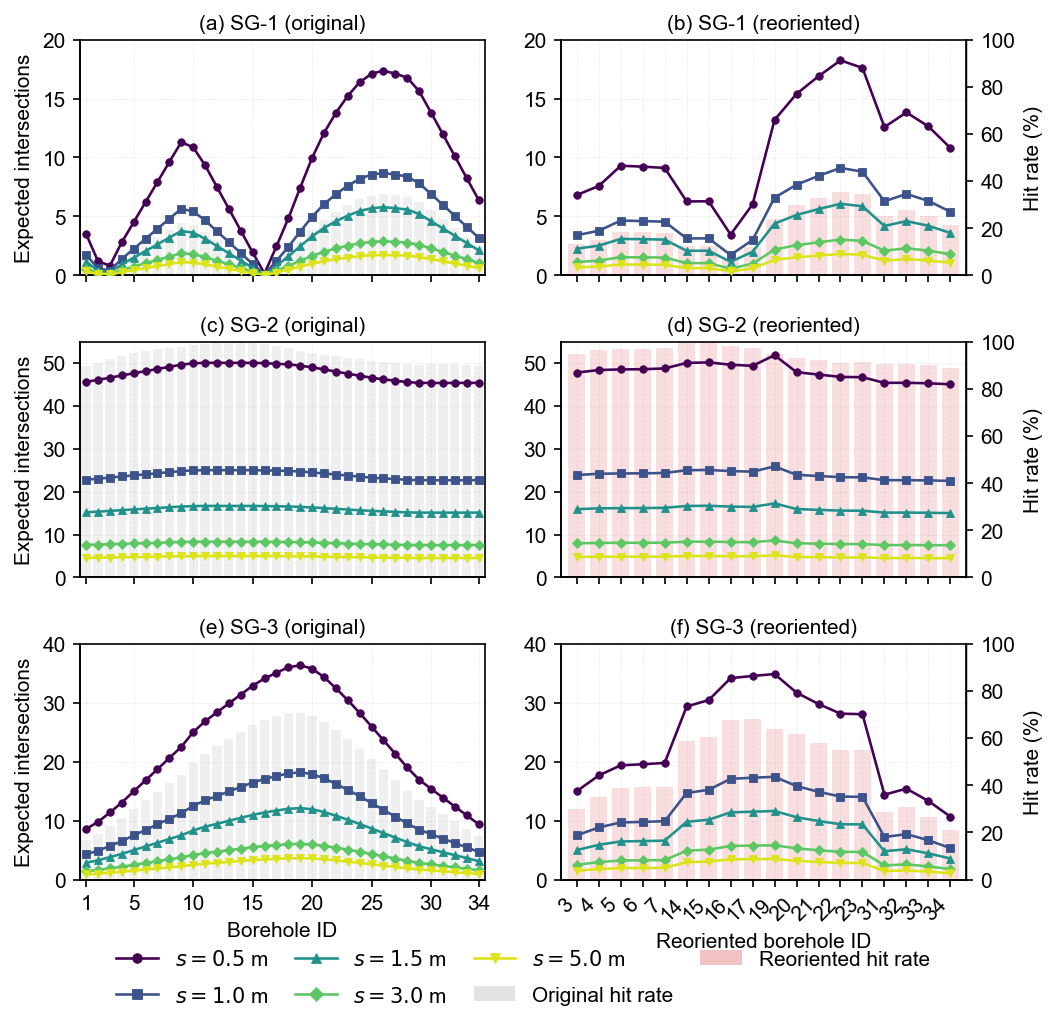

Saved:
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_14_joint_spacing_expected_intersections.png
C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Figure_14_joint_spacing_expected_intersections.svg

Original panels: 34 boreholes
Reoriented panels: 18 modified boreholes

Reoriented borehole IDs:
[3, 4, 5, 6, 7, 14, 15, 16, 17, 19, 20, 21, 22, 23, 31, 32, 33, 34]


In [21]:
# ============================================================
# CELL 22 — FIGURE 14:
# JOINT-SPACING SENSITIVITY OF EXPECTED INTERSECTIONS
#
# LEFT COLUMN:
# Original fan — all 34 boreholes
#
# RIGHT COLUMN:
# Reoriented geometry — only the 18 boreholes that were
# actually reoriented
#
# Row 1:
# (a) SG-1 original
# (b) SG-1 reoriented boreholes
#
# Row 2:
# (c) SG-2 original
# (d) SG-2 reoriented boreholes
#
# Row 3:
# (e) SG-3 original
# (f) SG-3 reoriented boreholes
#
# FOREGROUND:
# Expected number of intersections for:
# s = 0.5, 1.0, 1.5, 3.0, 5.0 m
#
# BACKGROUND:
# Original hit rate   = light grey
# Reoriented hit rate = light red
#
# Arial 10 pt throughout
# PNG 600 dpi + SVG
# ============================================================


from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# 1. FIGURE STYLE
# ============================================================

FIG14_SIZE = (
    7.2,
    7.0
)

FONT_SIZE = 10


plt.rcParams.update({

    "font.family":
        "sans-serif",

    "font.sans-serif": [
        "Arial",
        "DejaVu Sans"
    ],

    "font.size":
        FONT_SIZE,

    "axes.labelsize":
        FONT_SIZE,

    "axes.titlesize":
        FONT_SIZE,

    "xtick.labelsize":
        FONT_SIZE,

    "ytick.labelsize":
        FONT_SIZE,

    "legend.fontsize":
        FONT_SIZE,

    "axes.linewidth":
        0.8,

    "xtick.major.width":
        0.8,

    "ytick.major.width":
        0.8,

    "savefig.dpi":
        600,

    "svg.fonttype":
        "none"
})


# ============================================================
# 2. JOINT SPACINGS
# ============================================================

JOINT_SPACINGS = [
    0.5,
    1.0,
    1.5,
    3.0,
    5.0
]


# ============================================================
# 3. CURVE STYLES
# ============================================================

spacing_styles = {

    0.5: {
        "marker": "o",
        "color": "#440154"
    },

    1.0: {
        "marker": "s",
        "color": "#3B528B"
    },

    1.5: {
        "marker": "^",
        "color": "#21918C"
    },

    3.0: {
        "marker": "D",
        "color": "#5DC863"
    },

    5.0: {
        "marker": "v",
        "color": "#DCE319"
    }
}


LINE_WIDTH = 1.25
MARKER_SIZE = 3.6


# ============================================================
# 4. HIT-RATE BAR STYLE
# ============================================================

ORIGINAL_HIT_COLOR = "0.60"

REORIENTED_HIT_COLOR = "tab:red"

HIT_BAR_ALPHA = 0.15

HIT_BAR_WIDTH = 0.78


# ============================================================
# 5. SELECTED REORIENTED BOREHOLES
# ============================================================

selected_reoriented_holes = (

    reorientation_geometry_df[
        "Hole"
    ]

    .astype(int)

    .sort_values()

    .to_numpy()
)


print(
    "Reoriented boreholes:"
)

print(
    selected_reoriented_holes
)


# ============================================================
# 6. JOINT-SET-SPECIFIC EXPECTED-INTERSECTION AXES
#
# The original and reoriented panels of each joint set retain
# the same y-axis scale for direct comparison.
# ============================================================

y_axis_settings = {

    "SG-1": {
        "ylim": (
            0,
            20
        ),

        "yticks": np.arange(
            0,
            21,
            5
        )
    },

    "SG-2": {
        "ylim": (
            0,
            55
        ),

        "yticks": np.arange(
            0,
            51,
            10
        )
    },

    "SG-3": {
        "ylim": (
            0,
            40
        ),

        "yticks": np.arange(
            0,
            41,
            10
        )
    }
}


# ============================================================
# 7. CREATE FIGURE
# ============================================================

fig, axes = plt.subplots(

    3,
    2,

    figsize=FIG14_SIZE,

    sharey=False
)


fig.subplots_adjust(

    left=0.09,

    right=0.91,

    top=0.95,

    bottom=0.15,

    hspace=0.28,

    wspace=0.19
)


# ============================================================
# 8. PANEL DEFINITIONS
# ============================================================

panel_definitions = [

    (
        0,
        0,
        "SG-1",
        "Original",
        "(a) SG-1 (original)"
    ),

    (
        0,
        1,
        "SG-1",
        "Reoriented",
        "(b) SG-1 (reoriented)"
    ),

    (
        1,
        0,
        "SG-2",
        "Original",
        "(c) SG-2 (original)"
    ),

    (
        1,
        1,
        "SG-2",
        "Reoriented",
        "(d) SG-2 (reoriented)"
    ),

    (
        2,
        0,
        "SG-3",
        "Original",
        "(e) SG-3 (original)"
    ),

    (
        2,
        1,
        "SG-3",
        "Reoriented",
        "(f) SG-3 (reoriented)"
    )
]


# ============================================================
# 9. PLOT PANELS
# ============================================================

for (
    row_index,
    col_index,
    joint_set,
    configuration,
    title
) in panel_definitions:

    ax = axes[
        row_index,
        col_index
    ]


    # --------------------------------------------------------
    # Base panel data
    # --------------------------------------------------------

    panel_data = expected_intersections[
        (
            expected_intersections[
                "Joint set"
            ] == joint_set
        )
        &
        (
            expected_intersections[
                "Configuration"
            ] == configuration
        )
    ].copy()


    # ========================================================
    # ORIGINAL PANEL
    #
    # Keep all 34 original boreholes.
    # ========================================================

    if configuration == "Original":

        panel_data = panel_data.copy()


        panel_holes = np.sort(

            panel_data[
                "Hole"
            ]
            .unique()
        )


        # Use actual borehole IDs as x positions
        x_lookup = {

            int(hole):
                float(hole)

            for hole in panel_holes
        }


        x_min = 0.5
        x_max = 34.5


        x_ticks = [
            1,
            5,
            10,
            15,
            20,
            25,
            30,
            34
        ]


        x_ticklabels = [
            1,
            5,
            10,
            15,
            20,
            25,
            30,
            34
        ]


        hit_bar_color = (
            ORIGINAL_HIT_COLOR
        )


    # ========================================================
    # REORIENTED PANEL
    #
    # Keep ONLY the 18 genuinely modified boreholes.
    #
    # Use categorical positions 0...17 so that large gaps
    # between borehole IDs do not create artificial blank
    # regions in the right-hand panels.
    # ========================================================

    else:

        panel_data = panel_data[
            panel_data[
                "Hole"
            ].isin(
                selected_reoriented_holes
            )
        ].copy()


        panel_holes = (
            selected_reoriented_holes
            .copy()
        )


        x_lookup = {

            int(hole):
                float(position)

            for position, hole in enumerate(
                panel_holes
            )
        }


        x_min = -0.7

        x_max = (
            len(
                panel_holes
            )
            -
            0.3
        )


        x_ticks = np.arange(
            len(
                panel_holes
            )
        )


        x_ticklabels = (
            panel_holes
        )


        hit_bar_color = (
            REORIENTED_HIT_COLOR
        )


    # ========================================================
    # SECONDARY AXIS — HIT RATE
    # ========================================================

    ax_hit = ax.twinx()


    # --------------------------------------------------------
    # One hit-rate value per borehole
    # --------------------------------------------------------

    hit_data = (

        panel_data[
            [
                "Hole",
                "Hit rate (%)"
            ]
        ]

        .drop_duplicates(
            subset=[
                "Hole"
            ]
        )

        .sort_values(
            "Hole"
        )
    )


    hit_x = np.array([

        x_lookup[
            int(hole)
        ]

        for hole in (
            hit_data[
                "Hole"
            ]
        )
    ])


    # --------------------------------------------------------
    # Hit-rate bars
    # --------------------------------------------------------

    ax_hit.bar(

        hit_x,

        hit_data[
            "Hit rate (%)"
        ].to_numpy(
            dtype=float
        ),

        width=HIT_BAR_WIDTH,

        color=hit_bar_color,

        alpha=HIT_BAR_ALPHA,

        edgecolor="none",

        zorder=0
    )


    # --------------------------------------------------------
    # Secondary axis always 0–100%
    # --------------------------------------------------------

    ax_hit.set_ylim(
        0,
        100
    )


    ax_hit.set_yticks(
        np.arange(
            0,
            101,
            20
        )
    )


    # --------------------------------------------------------
    # Show hit-rate axis only on right-hand panels
    # --------------------------------------------------------

    if col_index == 1:

        ax_hit.set_ylabel(
            "Hit rate (%)",
            fontsize=FONT_SIZE
        )


        ax_hit.tick_params(

            axis="y",

            labelsize=FONT_SIZE,

            labelright=True,

            right=True
        )


        ax_hit.spines[
            "right"
        ].set_linewidth(
            0.7
        )


    else:

        ax_hit.set_ylabel(
            ""
        )


        ax_hit.tick_params(

            axis="y",

            labelright=False,

            right=False
        )


        ax_hit.spines[
            "right"
        ].set_visible(
            False
        )


    ax_hit.spines[
        "top"
    ].set_visible(
        False
    )


    # --------------------------------------------------------
    # Keep bars behind line plots
    # --------------------------------------------------------

    ax_hit.set_zorder(
        0
    )


    ax.set_zorder(
        1
    )


    ax.patch.set_visible(
        False
    )


    # ========================================================
    # PRIMARY AXIS — EXPECTED INTERSECTIONS
    # ========================================================

    for spacing in JOINT_SPACINGS:

        spacing_data = panel_data[
            panel_data[
                "Joint spacing (m)"
            ] == spacing
        ].sort_values(
            "Hole"
        )


        style = spacing_styles[
            spacing
        ]


        curve_x = np.array([

            x_lookup[
                int(hole)
            ]

            for hole in (
                spacing_data[
                    "Hole"
                ]
            )
        ])


        curve_y = (

            spacing_data[
                "Expected intersections"
            ]
            .to_numpy(
                dtype=float
            )
        )


        ax.plot(

            curve_x,

            curve_y,

            color=style[
                "color"
            ],

            marker=style[
                "marker"
            ],

            markersize=MARKER_SIZE,

            linewidth=LINE_WIDTH,

            markeredgewidth=0.4,

            zorder=4,

            label=(
                rf"$s={spacing:.1f}$ m"
            )
        )


    # ========================================================
    # TITLE
    # ========================================================

    ax.set_title(

        title,

        fontsize=FONT_SIZE,

        pad=5
    )


    # ========================================================
    # X AXIS
    # ========================================================

    ax.set_xlim(
        x_min,
        x_max
    )


    ax.set_xticks(
        x_ticks
    )


    # --------------------------------------------------------
    # Top two rows:
    # suppress x labels for cleaner appearance
    # --------------------------------------------------------

    if row_index < 2:

        ax.set_xticklabels(
            []
        )


    # --------------------------------------------------------
    # Bottom row:
    # show borehole IDs
    # --------------------------------------------------------

    else:

        if configuration == "Original":

            ax.set_xticklabels(

                x_ticklabels,

                fontsize=FONT_SIZE
            )


        else:

            ax.set_xticklabels(

                x_ticklabels,

                rotation=45,

                ha="right",

                fontsize=FONT_SIZE
            )


    # ========================================================
    # EXPECTED-INTERSECTION Y AXIS
    # ========================================================

    ax.set_ylim(
        y_axis_settings[
            joint_set
        ]["ylim"]
    )


    ax.set_yticks(
        y_axis_settings[
            joint_set
        ]["yticks"]
    )


    # ========================================================
    # GRID
    # ========================================================

    ax.grid(

        True,

        axis="both",

        linewidth=0.4,

        linestyle="--",

        alpha=0.22
    )


    ax.set_axisbelow(
        True
    )


    # ========================================================
    # TICK STYLE
    # ========================================================

    ax.tick_params(

        axis="both",

        labelsize=FONT_SIZE
    )


    # ========================================================
    # SPINES
    # ========================================================

    for spine in (
        ax.spines.values()
    ):

        spine.set_linewidth(
            0.8
        )


# ============================================================
# 10. PRIMARY Y-AXIS LABELS
# ============================================================

for row_index in range(
    3
):

    axes[
        row_index,
        0
    ].set_ylabel(
        "Expected intersections"
    )


# ============================================================
# 11. X-AXIS LABELS
# ============================================================

axes[
    2,
    0
].set_xlabel(
    "Borehole ID"
)


axes[
    2,
    1
].set_xlabel(
    "Reoriented borehole ID"
)


# ============================================================
# 12. LEGEND
# ============================================================

spacing_legend_handles = []


for spacing in JOINT_SPACINGS:

    style = spacing_styles[
        spacing
    ]


    spacing_legend_handles.append(

        Line2D(

            [0],
            [0],

            color=style[
                "color"
            ],

            marker=style[
                "marker"
            ],

            linewidth=LINE_WIDTH,

            markersize=MARKER_SIZE + 1,

            markeredgewidth=0.4,

            label=(
                rf"$s={spacing:.1f}$ m"
            )
        )
    )


# ------------------------------------------------------------
# Hit-rate legends
# ------------------------------------------------------------

hit_rate_legend_handles = [

    Patch(

        facecolor=ORIGINAL_HIT_COLOR,

        edgecolor="none",

        alpha=0.28,

        label="Original hit rate"
    ),

    Patch(

        facecolor=REORIENTED_HIT_COLOR,

        edgecolor="none",

        alpha=0.28,

        label="Reoriented hit rate"
    )
]


# ------------------------------------------------------------
# Combined legend
# ------------------------------------------------------------

legend_handles = (

    spacing_legend_handles

    +

    hit_rate_legend_handles
)


fig.legend(

    handles=legend_handles,

    loc="lower center",

    bbox_to_anchor=(
        0.50,
        0.012
    ),

    ncol=4,

    frameon=False,

    fontsize=FONT_SIZE,

    handlelength=2.0,

    columnspacing=1.3,

    labelspacing=0.8
)


# ============================================================
# 13. SAVE — PNG + SVG
# ============================================================

FIG14_PNG = (

    figure_dir

    /

    "Figure_14_joint_spacing_expected_intersections.png"
)


FIG14_SVG = (

    figure_dir

    /

    "Figure_14_joint_spacing_expected_intersections.svg"
)


fig.savefig(

    FIG14_PNG,

    dpi=600,

    bbox_inches="tight",

    pad_inches=0.10
)


fig.savefig(

    FIG14_SVG,

    bbox_inches="tight",

    pad_inches=0.10
)


plt.show()


# ============================================================
# 14. OUTPUT
# ============================================================

print("Saved:")

print(
    FIG14_PNG
)

print(
    FIG14_SVG
)


print(
    "\nOriginal panels: 34 boreholes"
)


print(
    "Reoriented panels:",
    len(
        selected_reoriented_holes
    ),
    "modified boreholes"
)


print(
    "\nReoriented borehole IDs:"
)

print(
    selected_reoriented_holes.tolist()
)

In [22]:
# ============================================================
# SUMMARY FOR THE 18 SELECTED BOREHOLES ONLY
#
# Enables a direct original-versus-reoriented comparison
# for exactly the boreholes modified in the sensitivity case.
# ============================================================

selected_holes = (
    reorientation_geometry_df["Hole"]
    .astype(int)
    .sort_values()
    .tolist()
)


selected_expected = expected_intersections[
    expected_intersections["Hole"].isin(
        selected_holes
    )
].copy()


selected_spacing_summary = (

    selected_expected

    .groupby(
        [
            "Configuration",
            "Joint set",
            "Joint spacing (m)"
        ],
        as_index=False
    )

    .agg(

        Minimum_expected_intersections=(
            "Expected intersections",
            "min"
        ),

        Maximum_expected_intersections=(
            "Expected intersections",
            "max"
        ),

        Mean_expected_intersections=(
            "Expected intersections",
            "mean"
        )
    )
)


display(
    selected_spacing_summary.round(2)
)


SELECTED_SPACING_SUMMARY_CSV = (
    WORK_DIR
    /
    "Expected_intersections_selected_reoriented_boreholes_summary.csv"
)


selected_spacing_summary.to_csv(
    SELECTED_SPACING_SUMMARY_CSV,
    index=False,
    encoding="utf-8-sig"
)


print(
    "\nSaved:",
    SELECTED_SPACING_SUMMARY_CSV
)

,Configuration,Joint set,Joint spacing (m),Minimum_expected_intersections,Maximum_expected_intersections,Mean_expected_intersections
0,Original,SG-1,0.5,0.16,15.22,7.00
1,Original,SG-1,1.0,0.08,7.61,3.50
2,Original,SG-1,1.5,0.05,5.07,2.33
3,Original,SG-1,3.0,0.03,2.54,1.17
4,Original,SG-1,5.0,0.02,1.52,0.70
5,Original,SG-2,0.5,45.34,50.03,47.87
6,Original,SG-2,1.0,22.67,25.02,23.93
7,Original,SG-2,1.5,15.11,16.68,15.96
8,Original,SG-2,3.0,7.56,8.34,7.98
9,Original,SG-2,5.0,4.53,5.00,4.79



Saved: C:\Users\abisheks\OneDrive - NTNU\Hit rate\Geo and Geo Engg\Sumbssion\Revision\Python Code\Expected_intersections_selected_reoriented_boreholes_summary.csv
